# Tensor Shape debugging

In [28]:
import torch
gs=torch.ones((16,8,77))
q=torch.randn((16,77))

In [29]:
q.unsqueeze(1).repeat(1,8,1)[0][5]

tensor([ 0.5872, -0.0065,  0.7301, -0.3711, -1.2041, -2.2986,  1.2354,  0.8132,
        -2.1675, -1.4143,  1.7160, -0.1610,  0.4236,  0.6768, -0.1887,  1.9470,
         0.2886,  1.0266, -1.2650, -0.4613, -0.2108,  0.7035,  0.5250, -2.2456,
        -0.4772, -0.1649,  1.1898,  1.3275,  0.6831,  0.0264,  0.1471, -0.4743,
        -0.9205,  1.3238,  1.6702, -0.2516, -0.8247, -0.2305,  0.8394, -0.0386,
        -1.5069, -0.5820, -0.4288,  0.5962,  1.4751,  1.5229, -1.9966,  0.7605,
         0.4987,  0.4321, -0.2593,  1.6014, -0.7212,  1.6380, -0.5794,  0.4963,
        -0.1502, -0.6384,  0.8807,  0.4737,  0.2532,  0.3886,  0.2558, -0.7497,
        -0.6710, -0.0345, -0.6441, -1.1315, -1.3246, -0.8875, -0.5085, -1.2757,
        -1.1949, -0.3289, -0.0355, -0.3935,  1.5228])

In [30]:
q[0]

tensor([ 0.5872, -0.0065,  0.7301, -0.3711, -1.2041, -2.2986,  1.2354,  0.8132,
        -2.1675, -1.4143,  1.7160, -0.1610,  0.4236,  0.6768, -0.1887,  1.9470,
         0.2886,  1.0266, -1.2650, -0.4613, -0.2108,  0.7035,  0.5250, -2.2456,
        -0.4772, -0.1649,  1.1898,  1.3275,  0.6831,  0.0264,  0.1471, -0.4743,
        -0.9205,  1.3238,  1.6702, -0.2516, -0.8247, -0.2305,  0.8394, -0.0386,
        -1.5069, -0.5820, -0.4288,  0.5962,  1.4751,  1.5229, -1.9966,  0.7605,
         0.4987,  0.4321, -0.2593,  1.6014, -0.7212,  1.6380, -0.5794,  0.4963,
        -0.1502, -0.6384,  0.8807,  0.4737,  0.2532,  0.3886,  0.2558, -0.7497,
        -0.6710, -0.0345, -0.6441, -1.1315, -1.3246, -0.8875, -0.5085, -1.2757,
        -1.1949, -0.3289, -0.0355, -0.3935,  1.5228])

In [33]:
gs.permute(2,1,0).shape

torch.Size([77, 8, 16])

In [34]:
q.unsqueeze(1).repeat(1,8,1).shape

torch.Size([16, 8, 77])

In [36]:
sim = q.unsqueeze(1).repeat(1,8,1) @ gs.permute(2,1,0)

RuntimeError: The size of tensor a (16) must match the size of tensor b (77) at non-singleton dimension 0

In [37]:
import torch
gs=torch.ones((16,8,512))
q=torch.randn((16,512))

In [40]:
cos_sims = []
for qfeat_, gfeat_ in zip(q, gs):
    print(qfeat_.shape, gfeat_.shape)
    cos_sim = qfeat_ @ gfeat_.t()#[512]@[k_tta,512].t() = [k_tta]
    print(cos_sim.shape)
    cos_sims.append(cos_sim)
# cos_sims  = torch.cat(cos_sims, dim=0)#16, k_tta

torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])


In [44]:
cos_sims = torch.stack(cos_sims)

In [45]:
cos_sims.shape

torch.Size([16, 8])

# Visual Person ReID Dataset

## RTSPReid

- 4101个identity，每个identity有5张图片，每张图片有2个caption
- 训练集3701个identity，测试集200个identity
- 每个identity，对应了10个text，5个image

In [1]:
import json

with open('/home/jiahao/task/IRRA/input/images/RSTPReid/data_captions.json', 'r') as f:
    annos = json.load(f)

train_anno, test_anno, val_anno = [], [], []
for anno in annos:
    if anno['split'] == 'train':
        train_anno.append(anno)
    elif anno['split'] == 'test':
        test_anno.append(anno)
    else:
        val_anno.append(anno)

In [2]:
print(f"RSTPReid dataset: {len(annos)}")

RSTPReid dataset: 20505


In [3]:
annos[-1]

{'id': 4100,
 'img_path': '4100_c4_0194.jpg',
 'captions': ['This is a walking man who is wearing a dark blue jacket with a yellow shirt inside and a pair of black trousers. His trainers are black with red shoelace.',
  'The man is wearing a dark blue overcoat ,black trousers and black shoes with a yellow shirt under his overcoat.He is walking and carrying his phone on his hand.He is using his phone.'],
 'split': 'test'}

In [4]:
annos[5]

{'id': 1,
 'img_path': '0001_c14_0033.jpg',
 'captions': ['The man is wearing a black coat and dark blue trousers. He walked with a black bag on his back.',
  'A man with black hair, wearing glasses, a gray and black shirt, black pants and black shoes, carrying a black backpack, is walking, a hand in the pocket'],
 'split': 'train'}

In [5]:
print(annos[1])
print(annos[2])
print(annos[3])
print(annos[4])

{'id': 0, 'img_path': '0000_c14_0032.jpg', 'captions': ['He is wearing a grey jacket with a blue shirt inside.He put his hands in his pockets.He is wearing a pair of glasses.He is carrying a black bag.', 'The man with glasses is wearing a grey jacket with a blue shirt inside. He has his hands in his pockets.'], 'split': 'train'}
{'id': 0, 'img_path': '0000_c1_0004.jpg', 'captions': ['This is a man wearing a grey jacket.He is walking with his hands in his pockets.His trousers are black.His shoes are brown.', 'The man is walking.He is wearing a dark grey jacket that is close.His trousers is black.He has a pair of brown shoes.'], 'split': 'train'}
{'id': 0, 'img_path': '0000_c5_0022.jpg', 'captions': ['The man is walking with a black bag.He wears a bright jacket and a pair of black trousers.His shoes is dark tanned.', 'A man with black hair, wearing glasses, a gray and black shirt, black pants and black shoes, carrying a black backpack, is walking, a hand in the pocket'], 'split': 'train'

In [6]:
annos[0]

{'id': 0,
 'img_path': '0000_c14_0031.jpg',
 'captions': ['The man is wearing a grey jacket and a blue shirt.His trousers are black and his shoes are brown.He is walking.',
  'The man is a strong man who is in a grey jacket.His shirt is blue and his trousers is black.'],
 'split': 'train'}

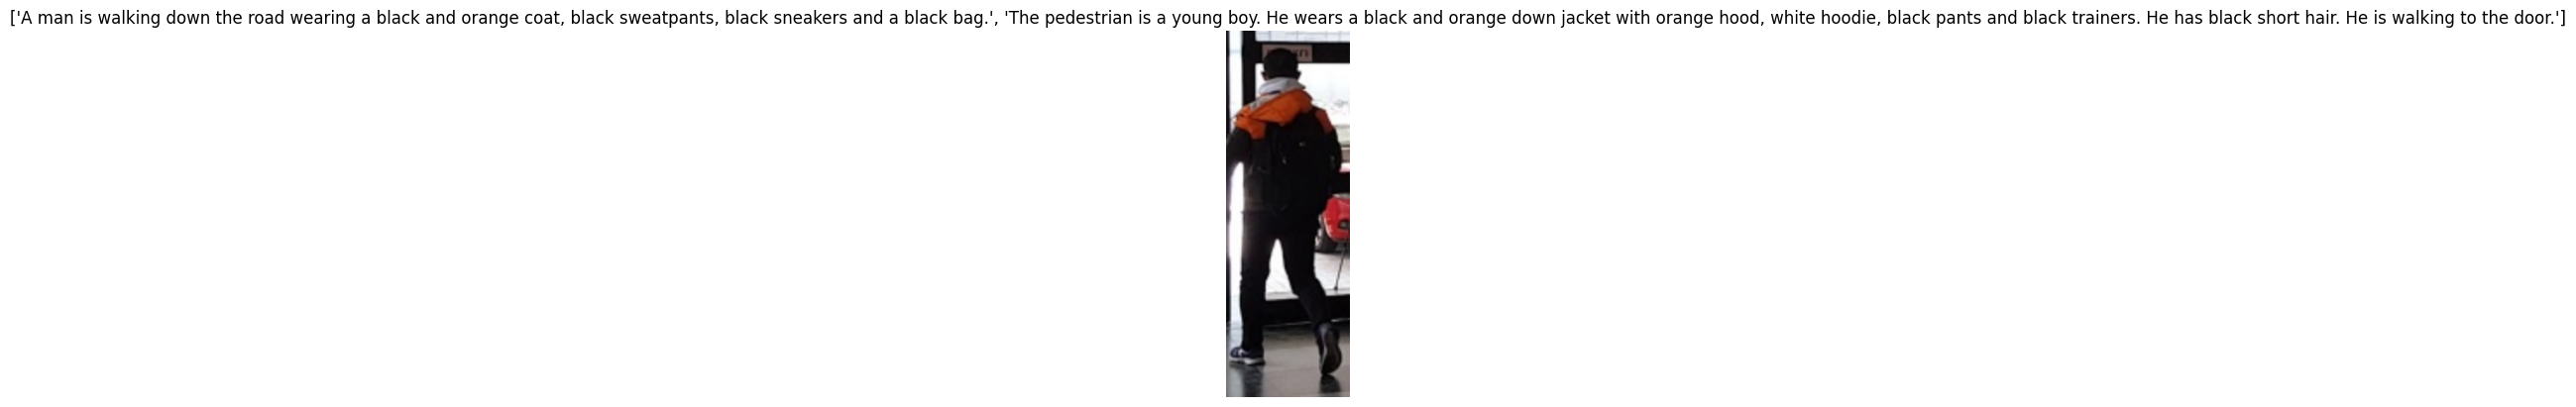

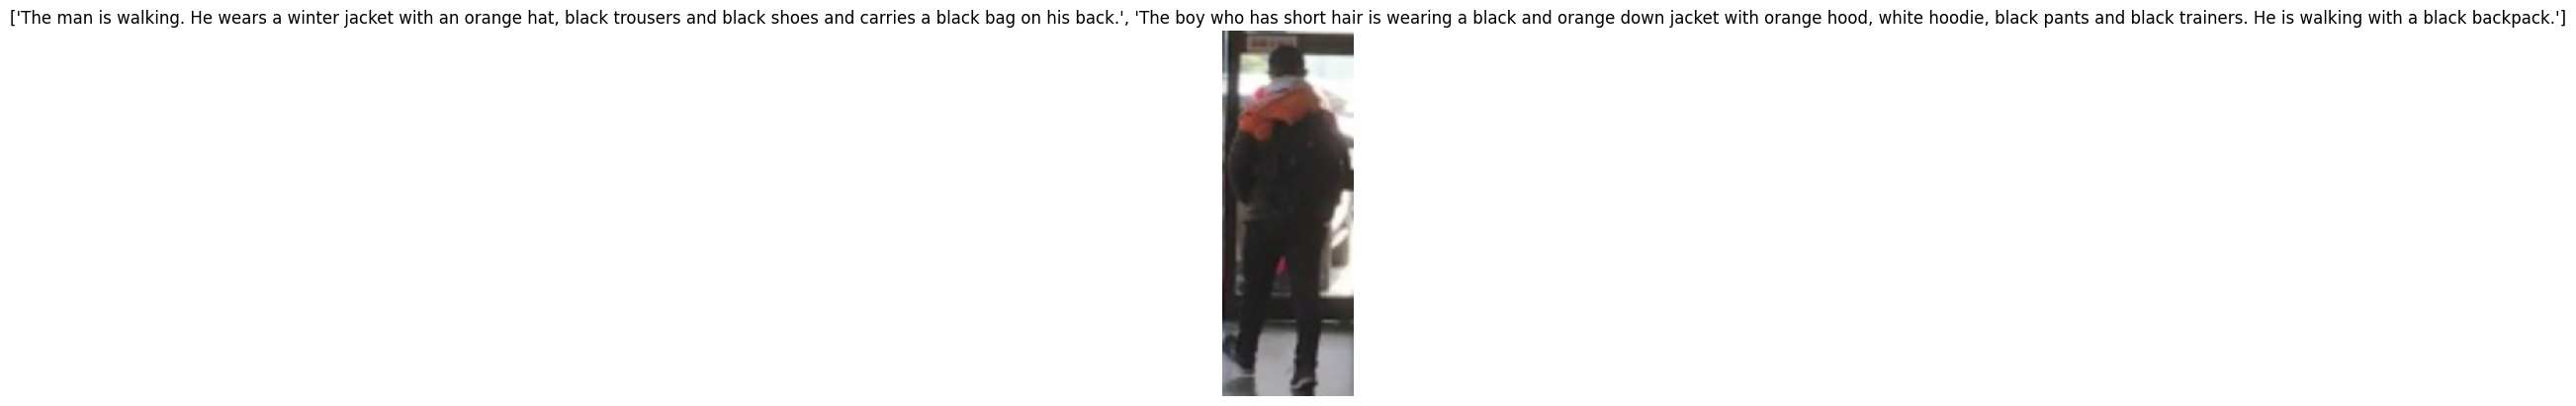

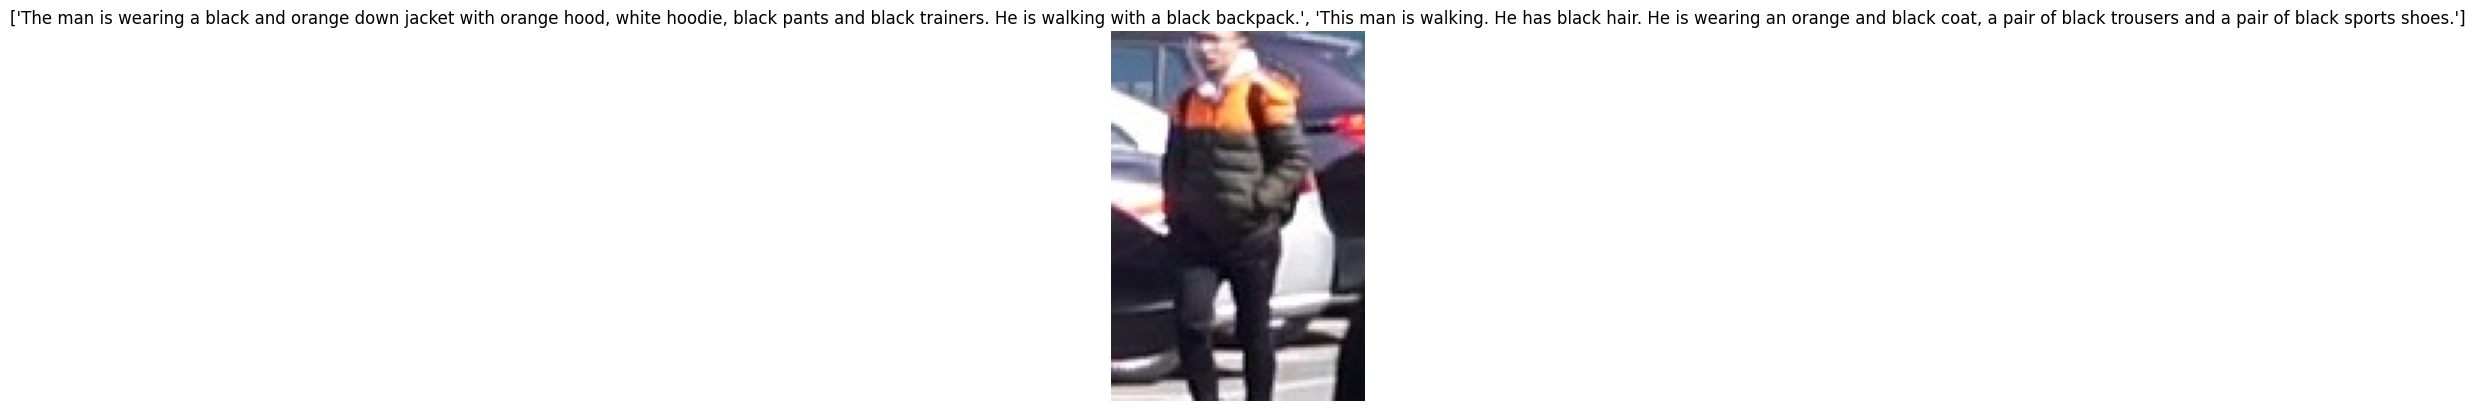

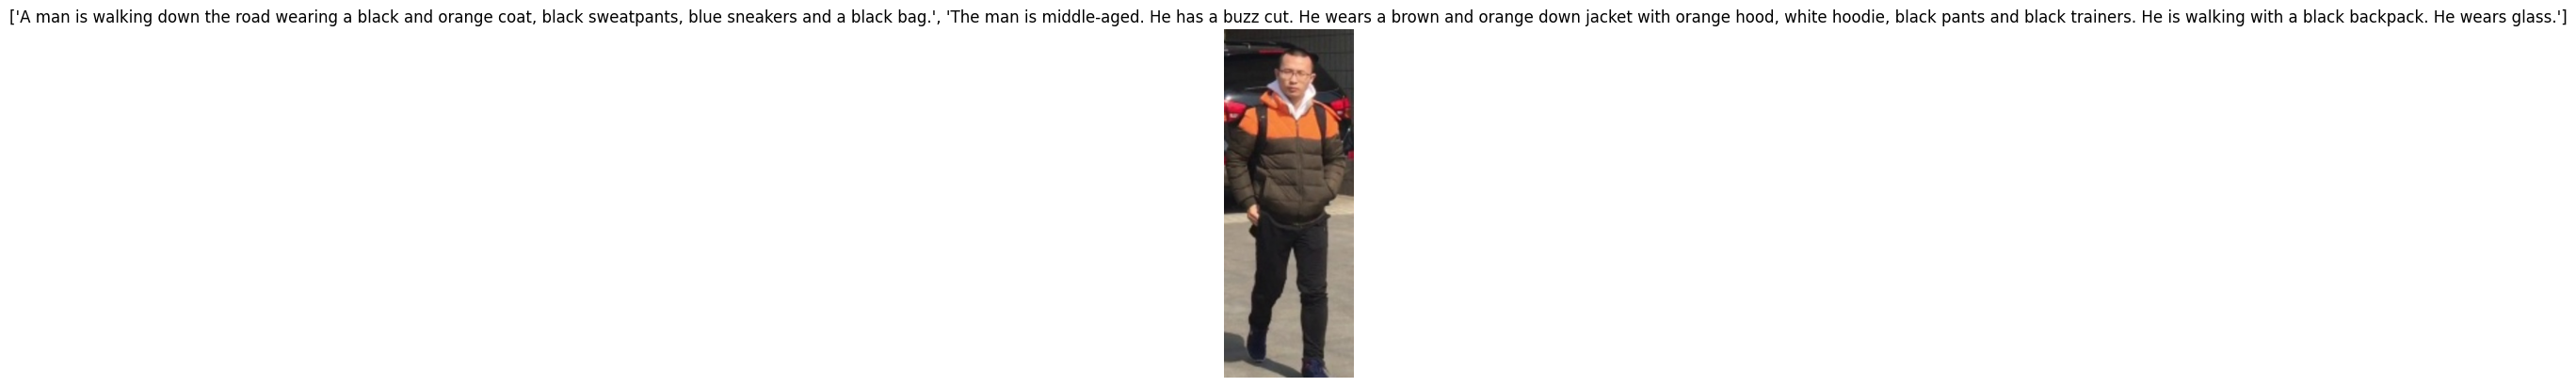

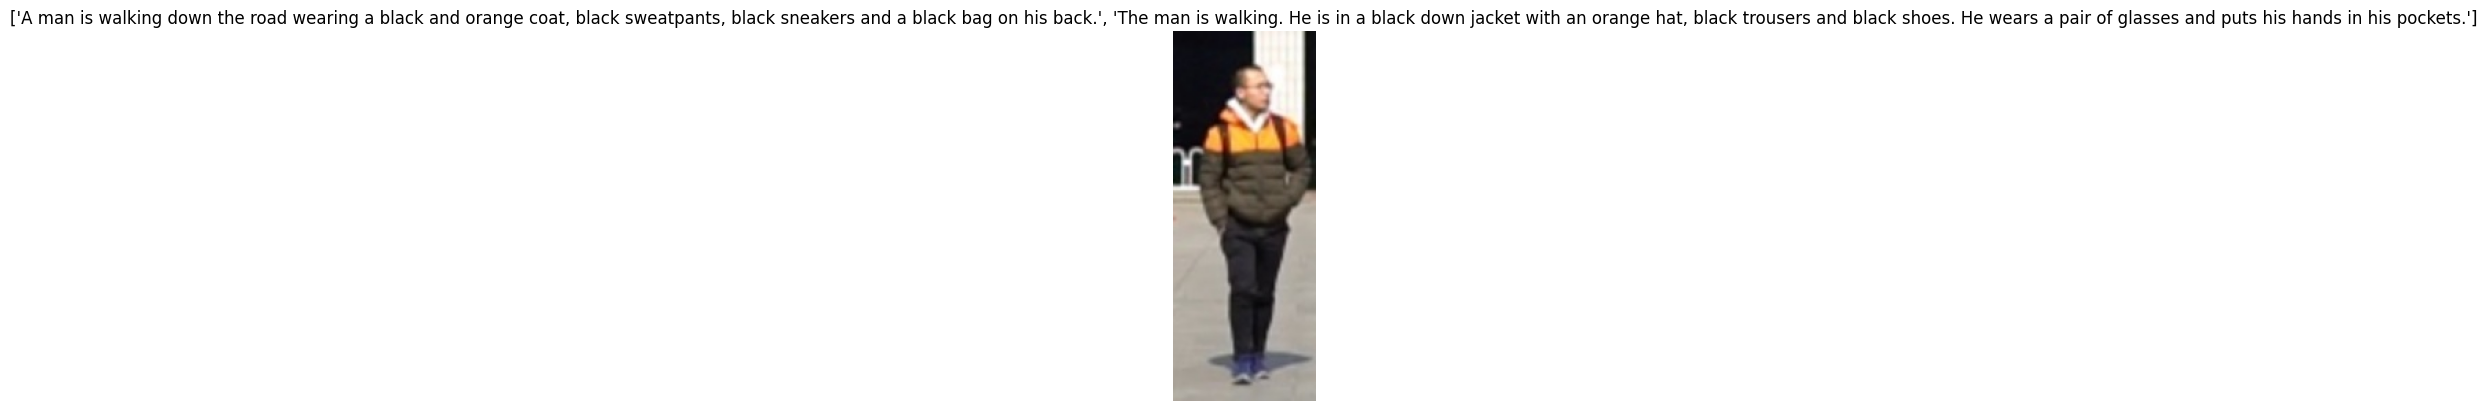

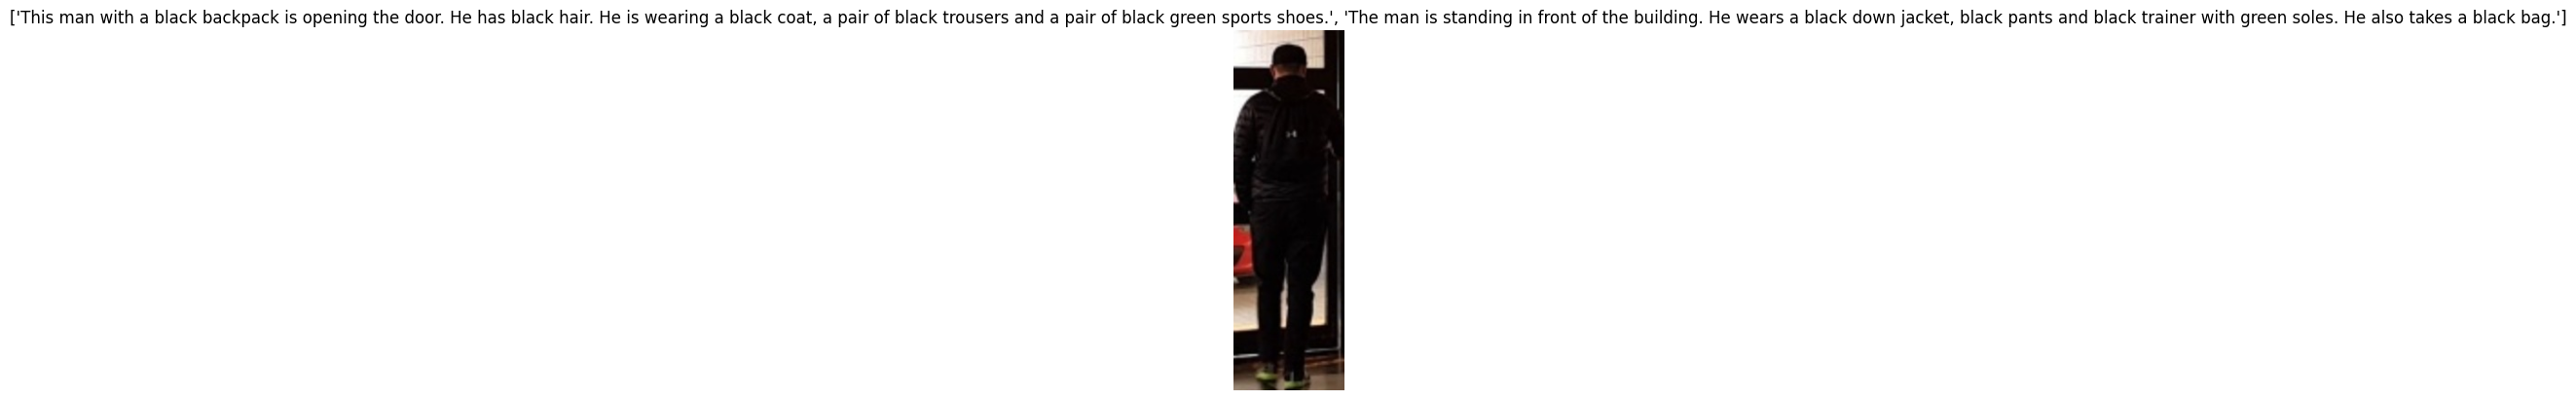

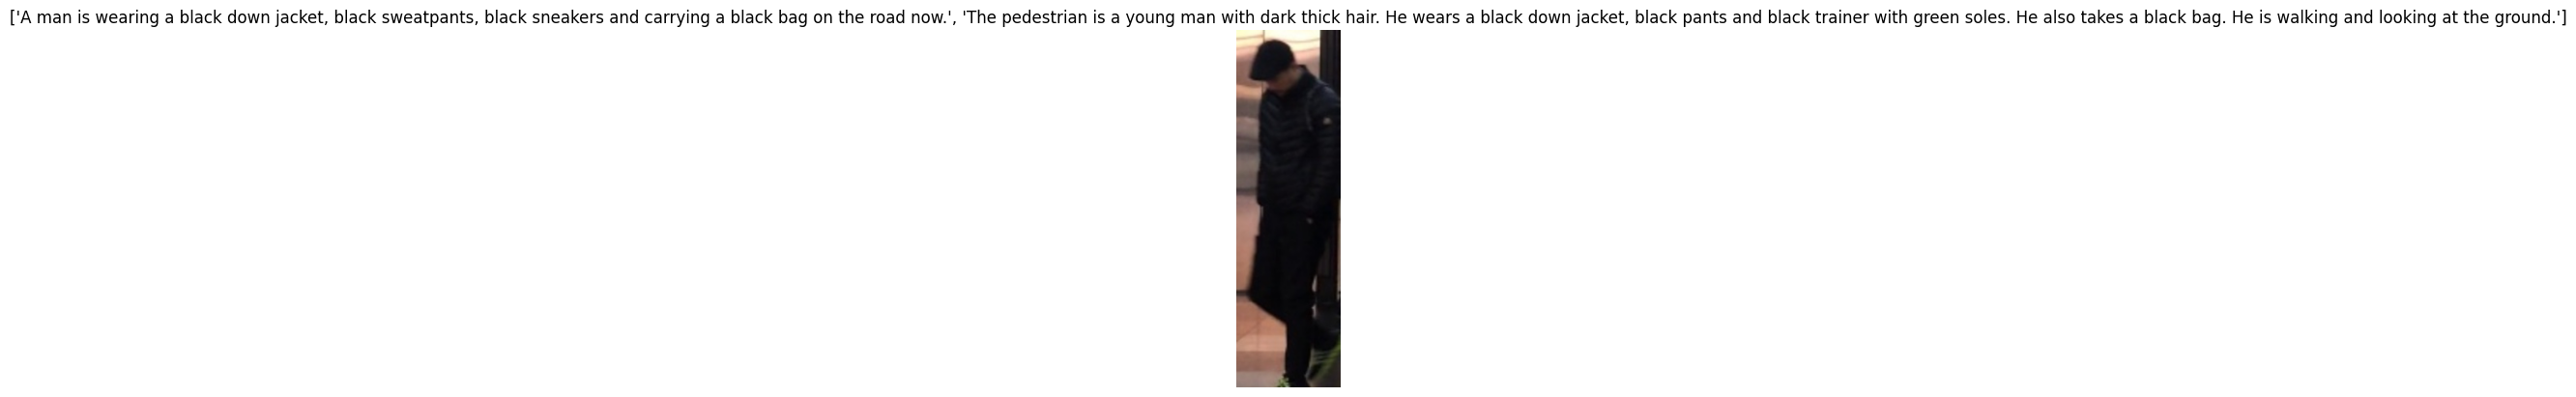

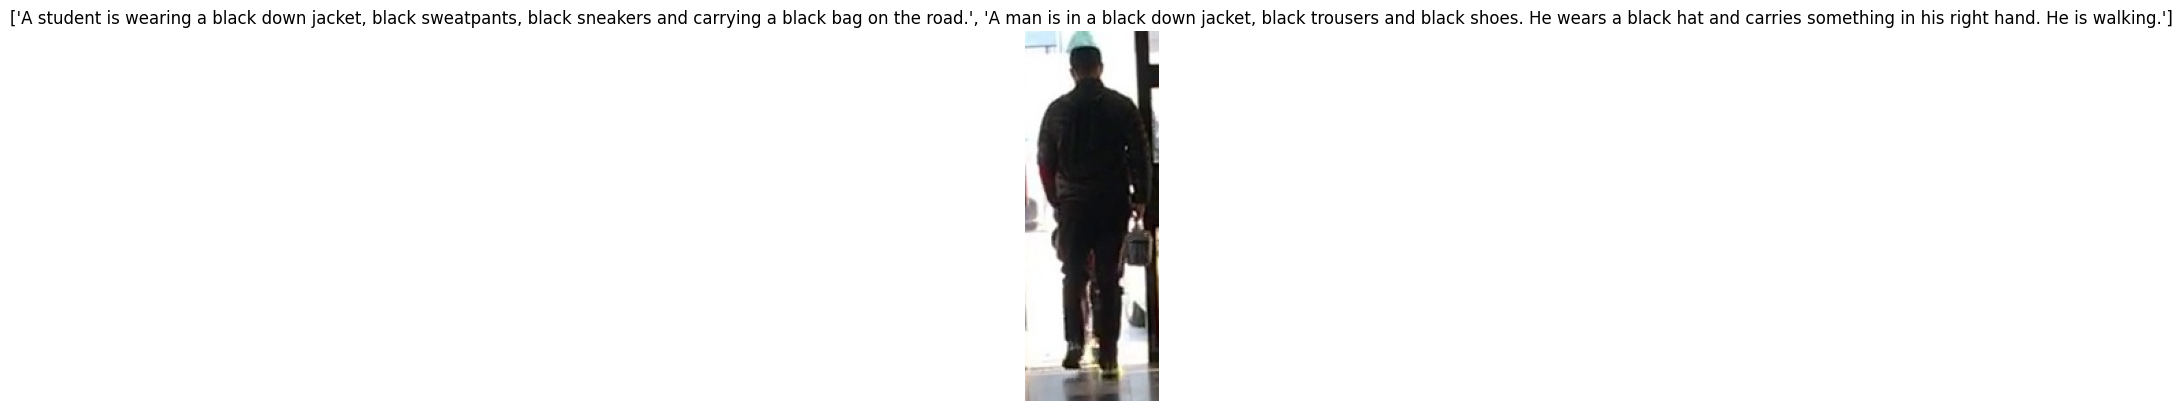

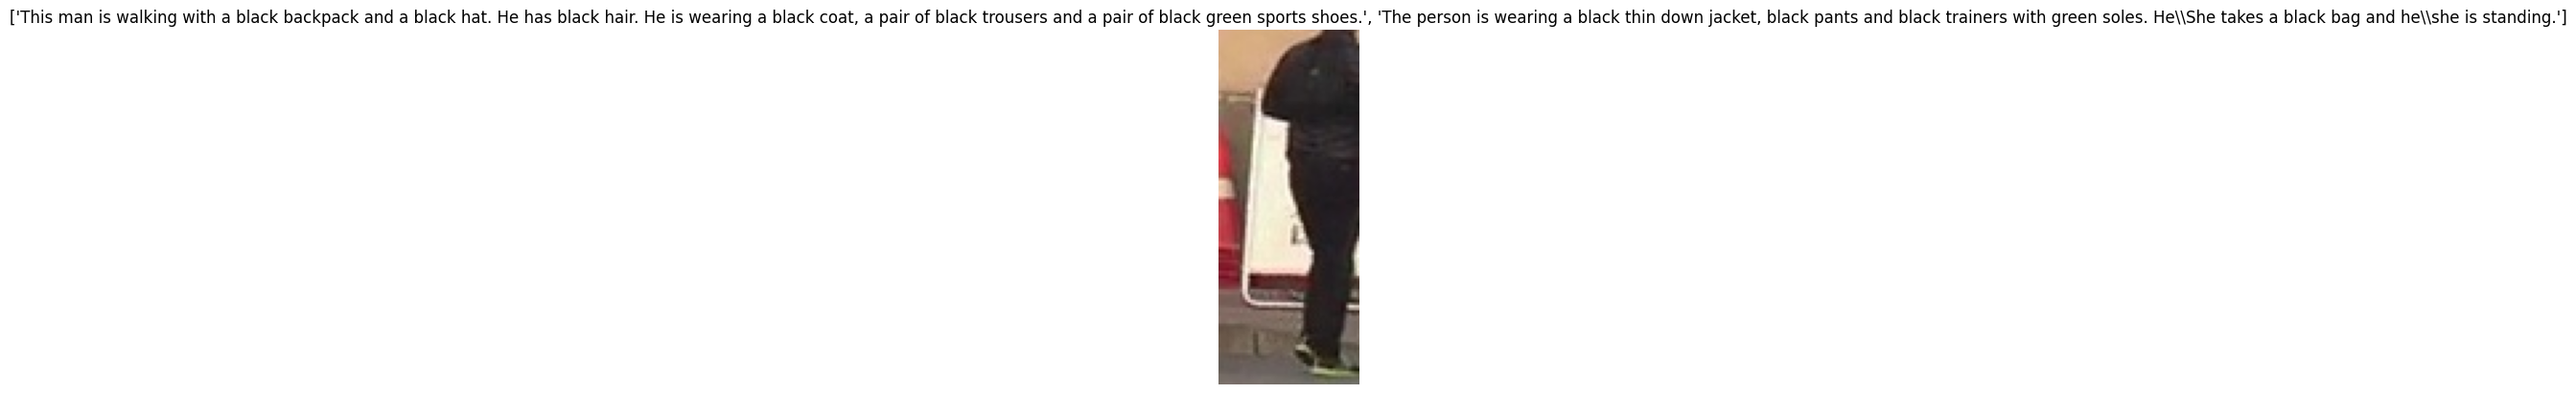

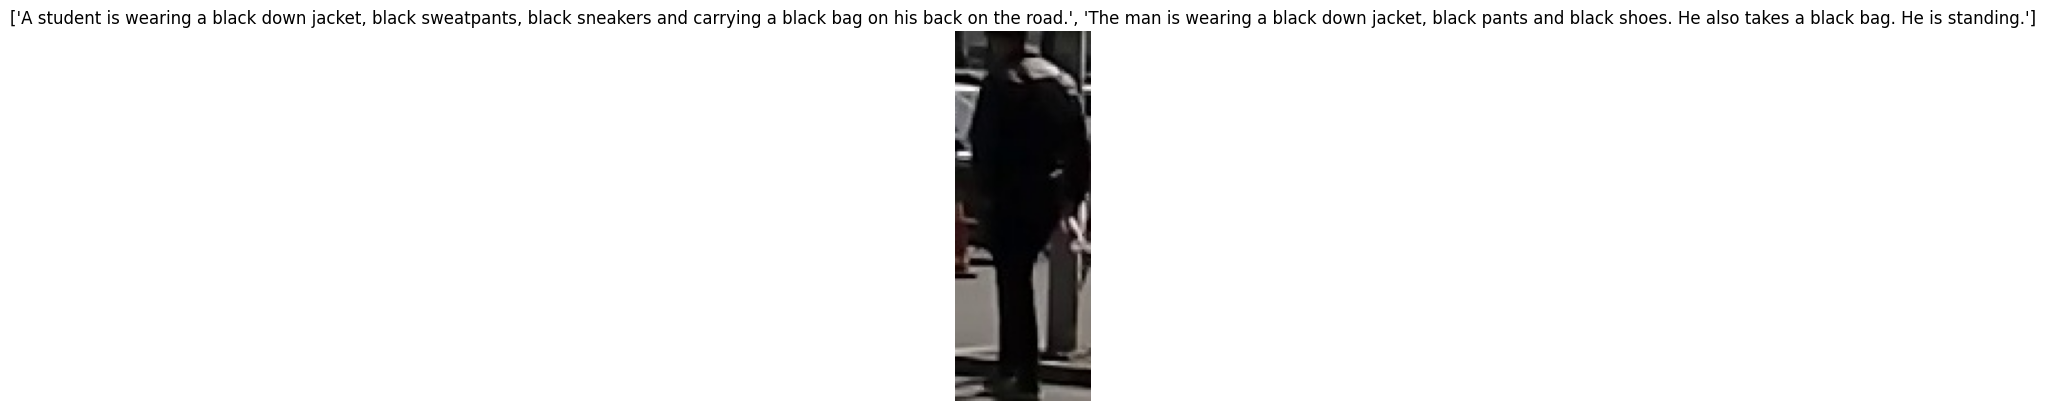

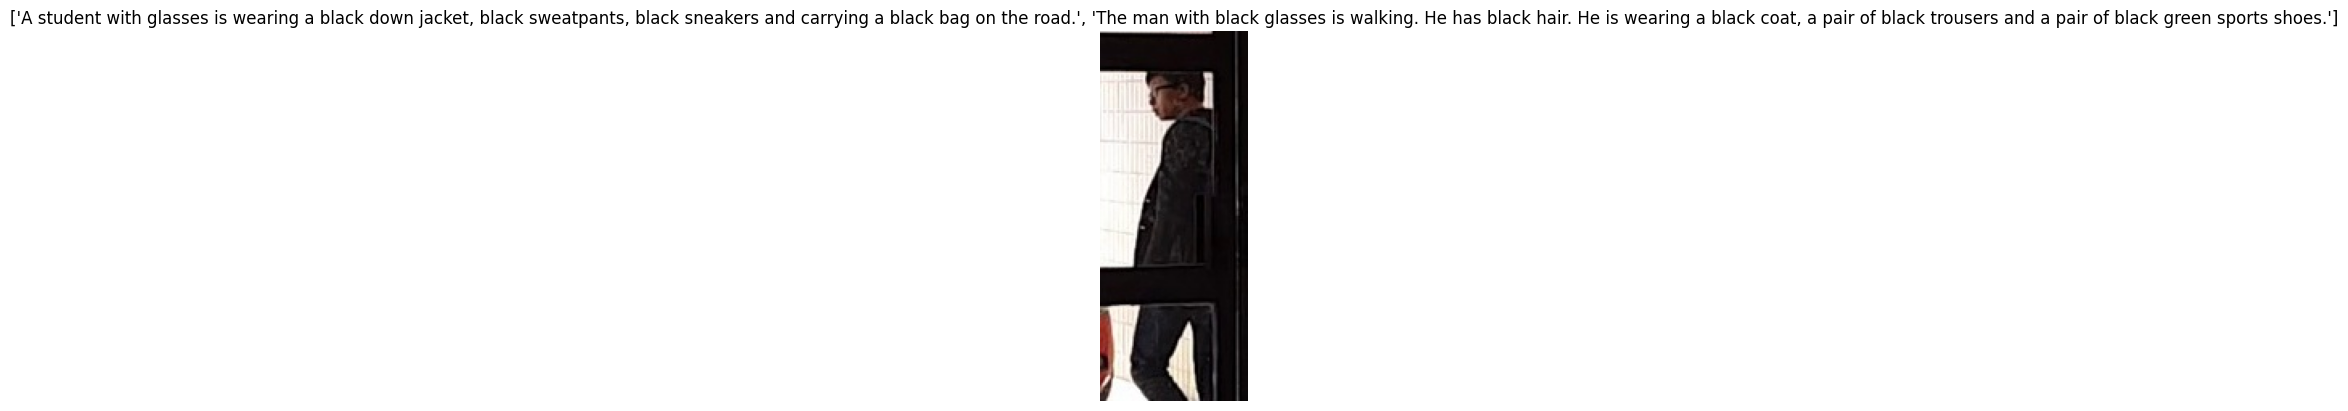

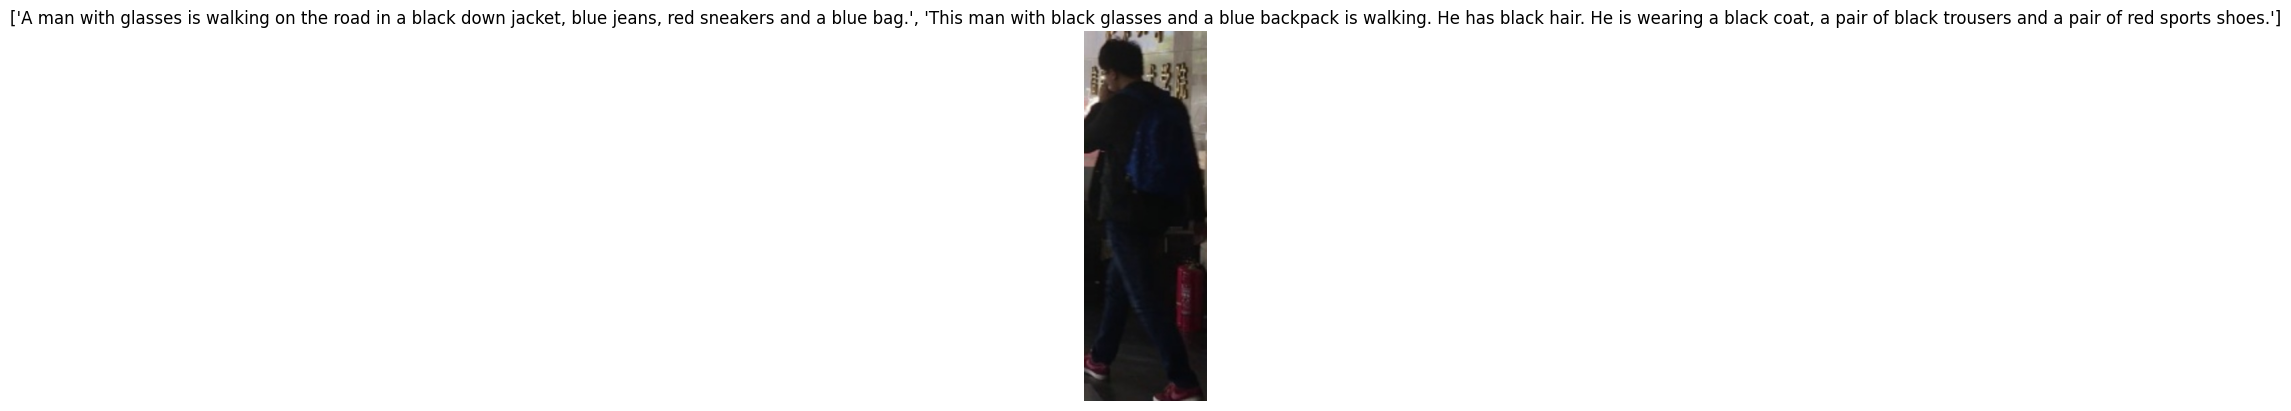

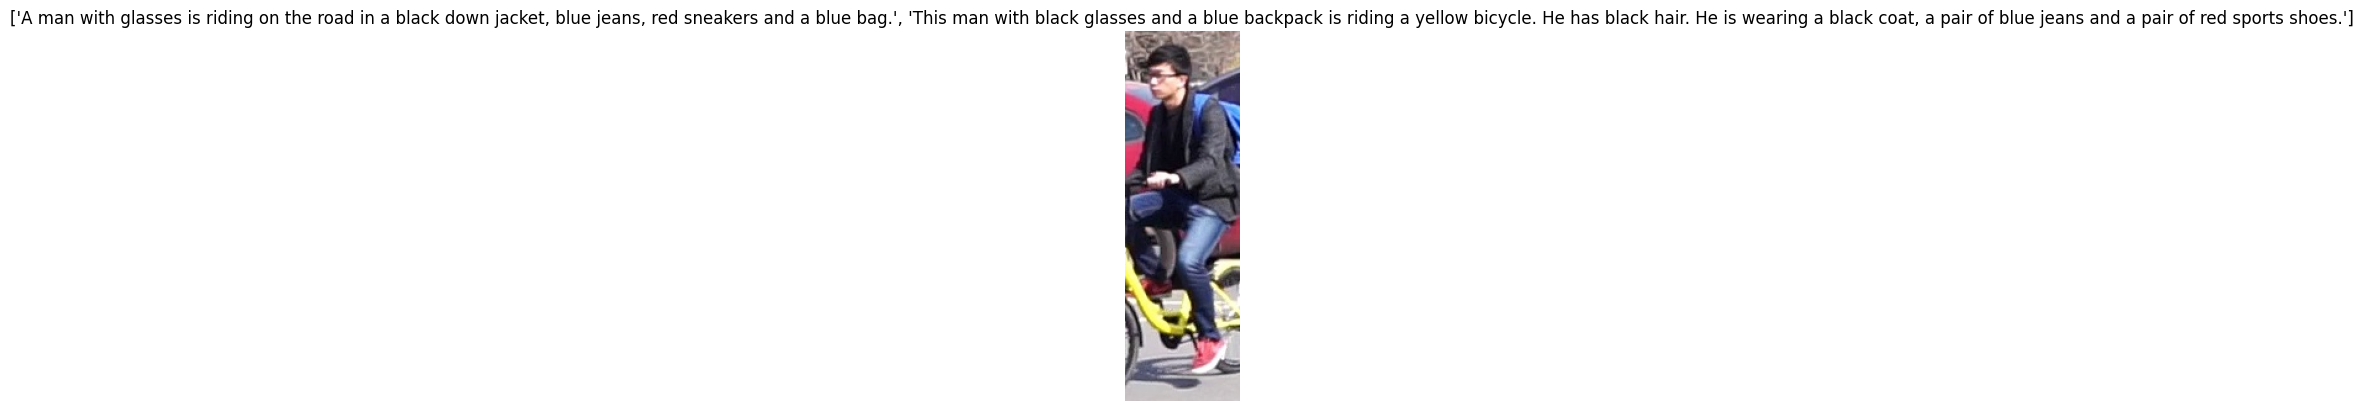

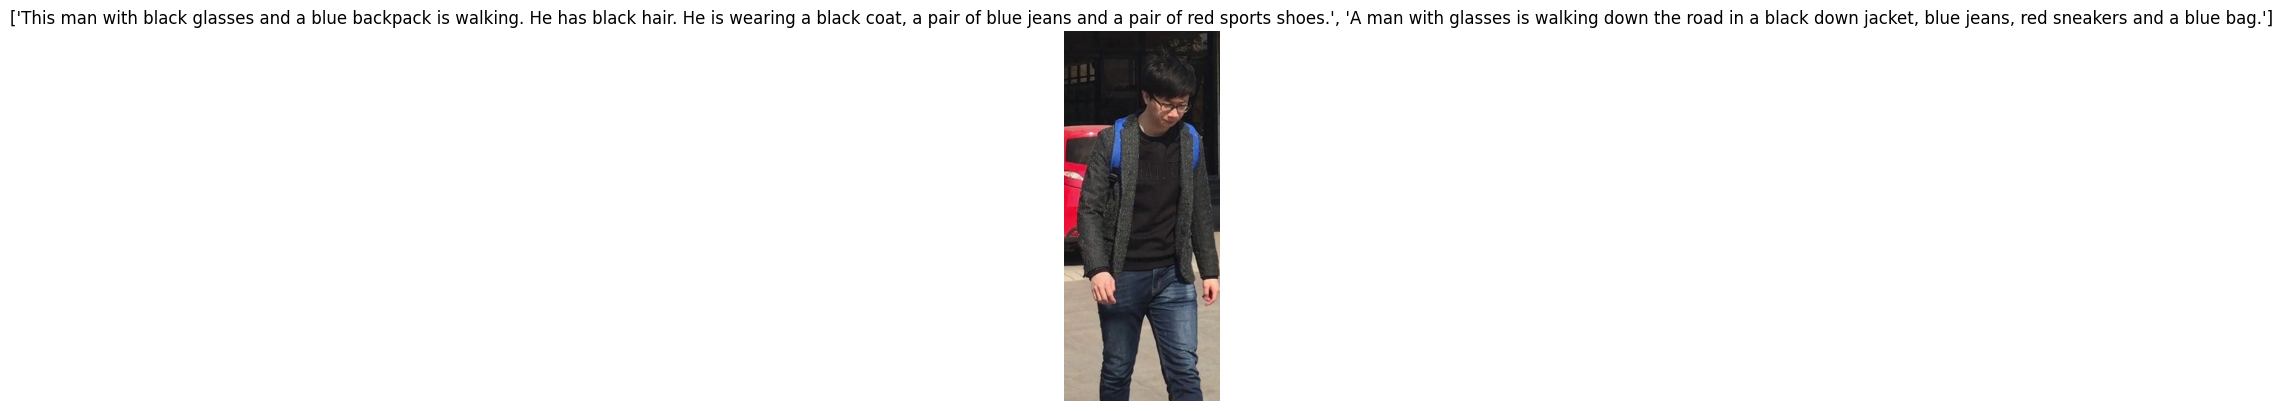

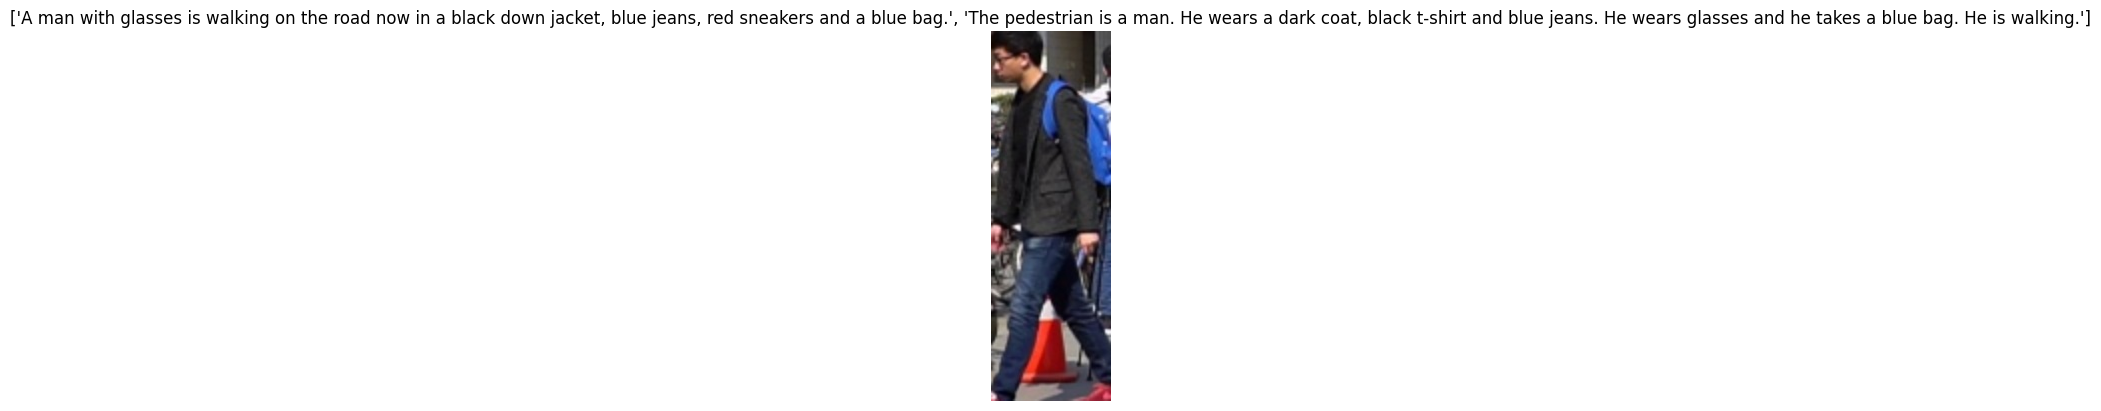

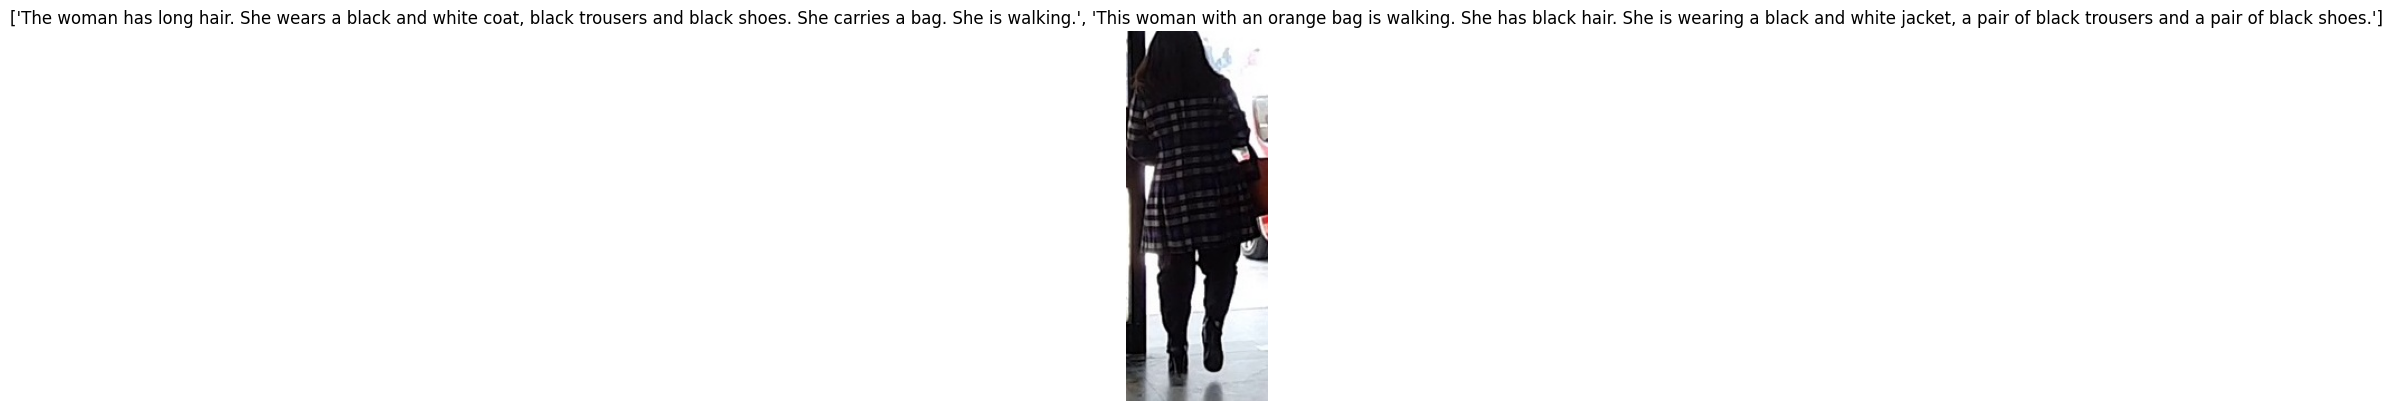

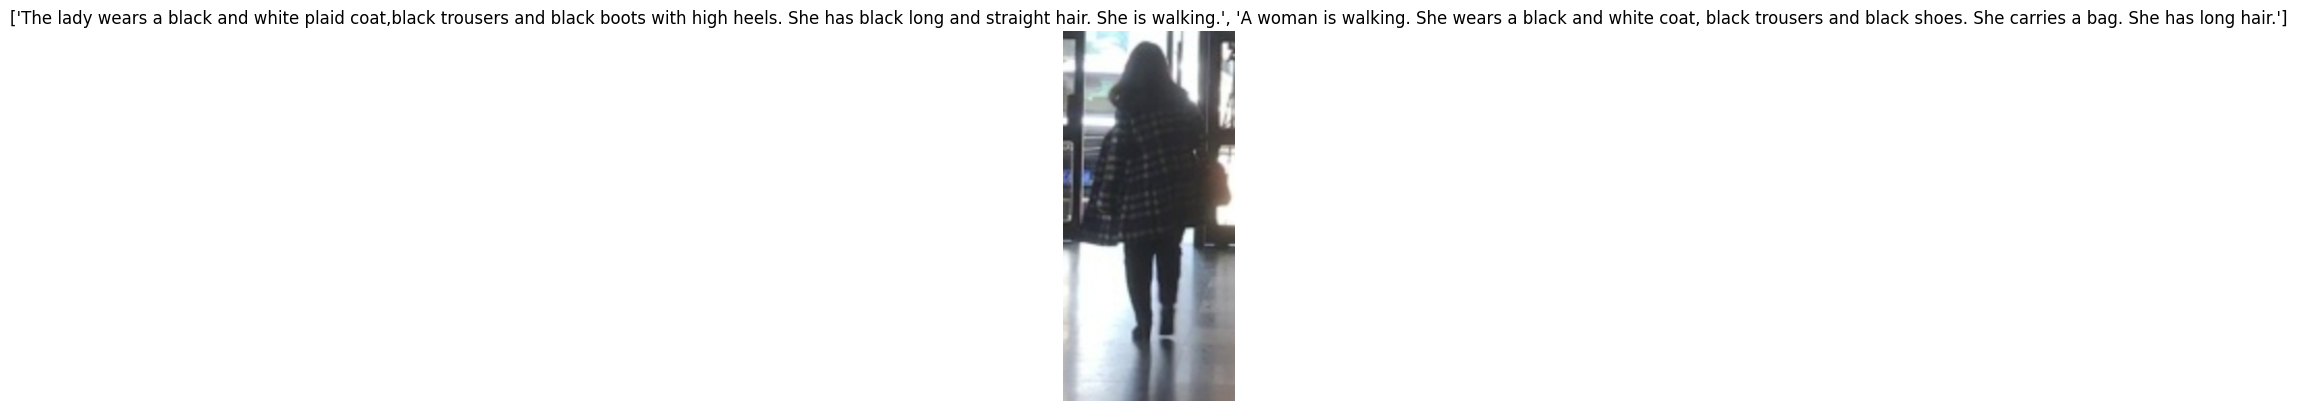

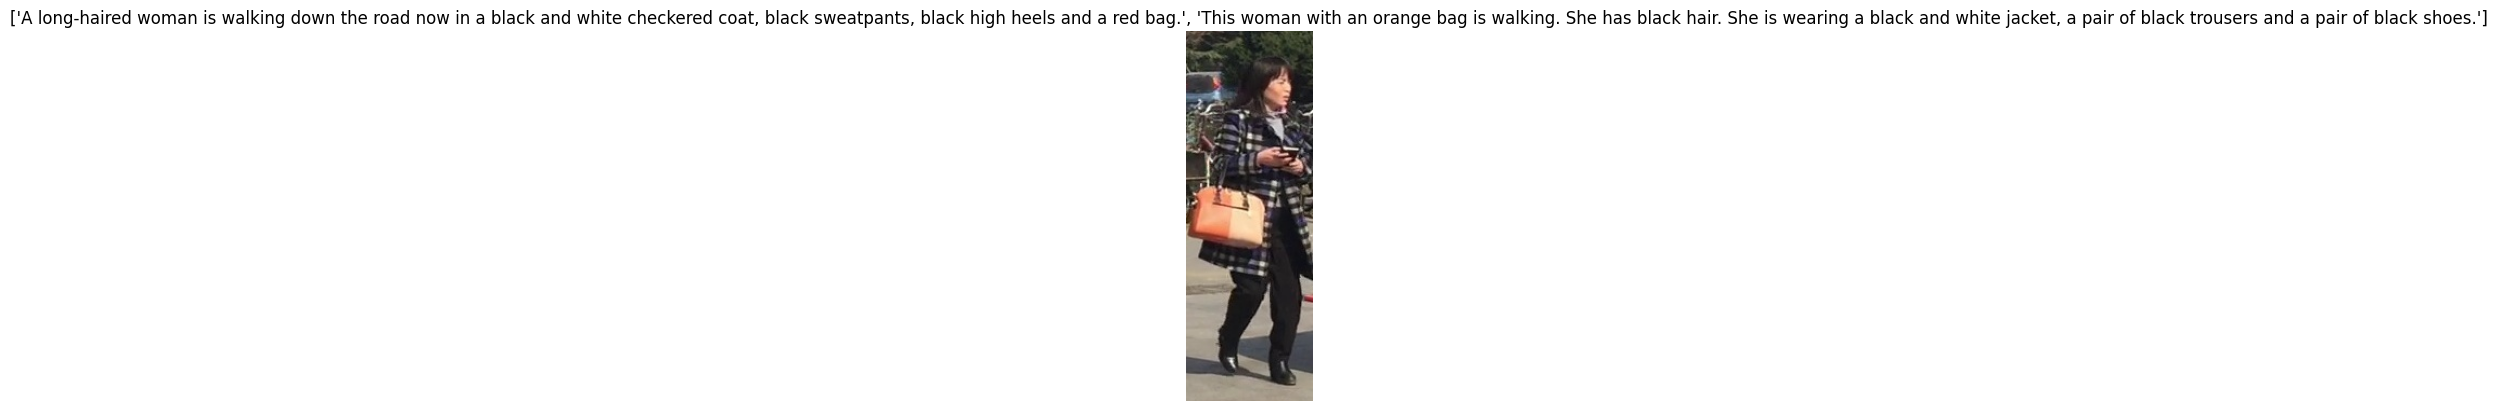

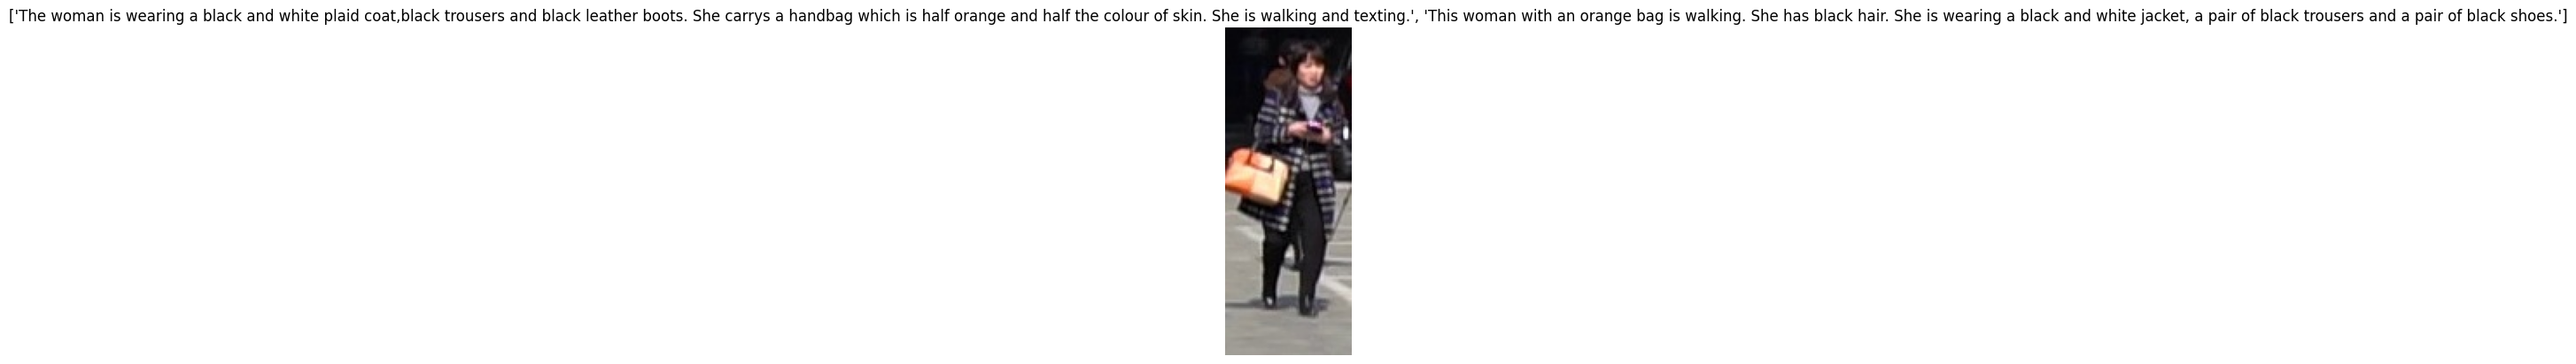

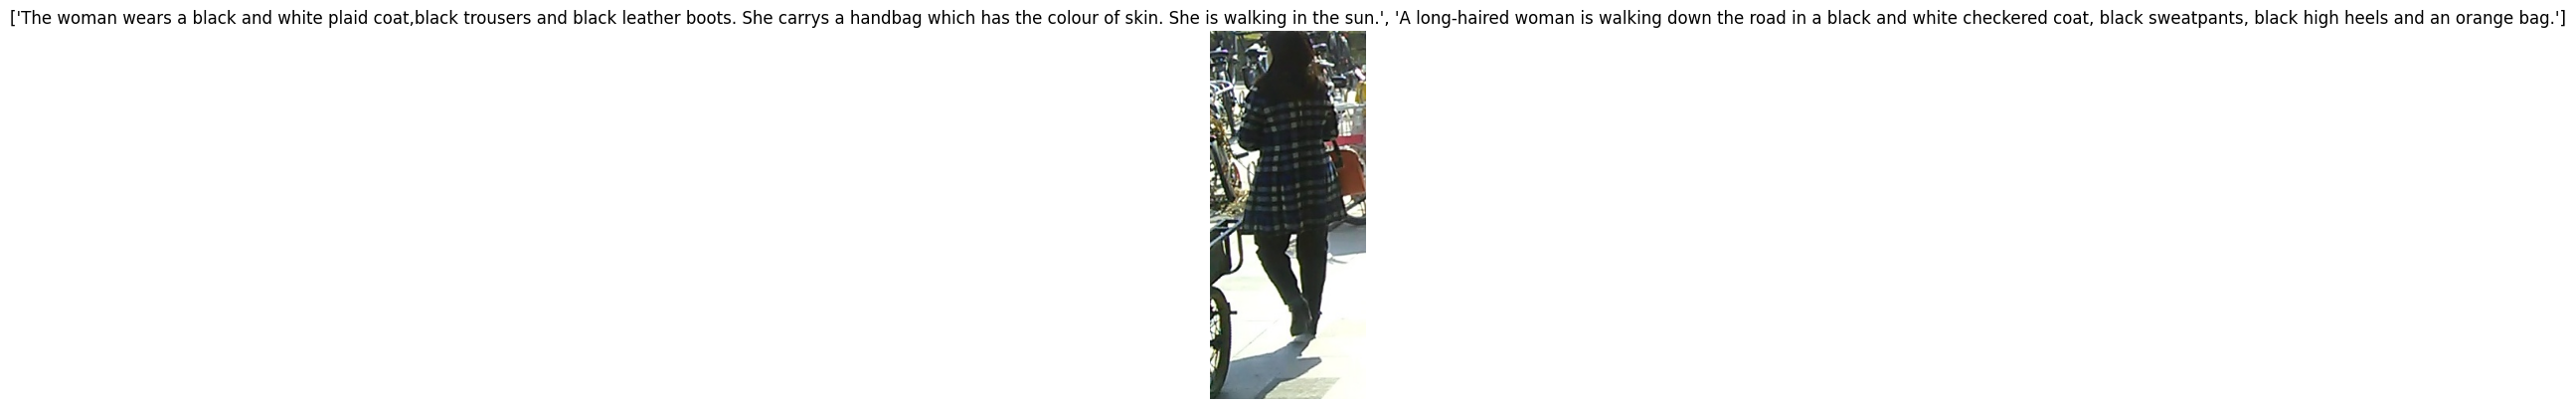

In [8]:
import matplotlib.pyplot as plt
import PIL.Image as Image

RSTP_img_path = '/home/jiahao/task/IRRA/input/images/RSTPReid/imgs'

pid=410  #4101个identity，每个identity有5张图片，每张图片有2个caption
for i in range(pid*5, (pid+4)*5):
    img = Image.open(f"{RSTP_img_path}/{annos[i]['img_path']}").convert('RGB')
    plt.imshow(img)
    plt.title(annos[i]['captions'])
    plt.axis('off')
    plt.show()


## ICFG-PEDES

- 4102个identity，54522张图片，每个identity平均有13.29张图片，每张图片有1个caption
- 训练集3102个identity，34674张图片；测试集1000个identity，19848张图片
- - 每个identity，对应了13.29个text，13.29个image

In [1]:
import json

with open('/home/jiahao/task/IRRA/input/images/ICFG-PEDES/ICFG-PEDES.json', 'r') as f:
    annos = json.load(f)

train_annos, test_annos, val_annos = [], [], []
for anno in annos:
    if anno['split'] == 'train':
        train_annos.append(anno)
    elif anno['split'] == 'test':
        test_annos.append(anno)
    else:
        val_annos.append(anno)

In [2]:
print(f"len(annos) = {len(annos)}")

len(annos) = 54522


In [3]:
annos[0]

{'split': 'train',
 'file_path': 'test/0627/0627_010_05_0303afternoon_1591_0.jpg',
 'id': 0,
 'processed_tokens': [['A',
   'young',
   'age',
   'woman',
   'has',
   'black',
   'shoulder-length',
   'hair',
   'and',
   'her',
   'is',
   'wearing',
   'a',
   'long',
   'grey',
   'collar',
   'jacket',
   'with',
   'white',
   'rounded',
   'neck',
   'inside',
   'with',
   'black',
   'pants',
   'and',
   'black',
   'shoes',
   '.']],
 'captions': ['A young age woman has black shoulder-length hair and her is wearing a long grey collar jacket with white rounded neck inside with black pants and black shoes.']}

In [4]:
import numpy as np

num_imgs_per_pid = np.zeros(4102)
for anno in annos:
    num_imgs_per_pid[anno['id']] += 1

print('\nall identity img stats: ')
print(len(annos))
print(num_imgs_per_pid.mean())
print(num_imgs_per_pid.max())
print(num_imgs_per_pid.min())
print(num_imgs_per_pid.std())


import numpy as np

num_train_imgs_per_pid = np.zeros(3102)
for anno in train_annos:
    num_train_imgs_per_pid[anno['id']] += 1

print('\ntrain identity img stats: ')
print(len(train_annos))
print(num_train_imgs_per_pid.mean())
print(num_train_imgs_per_pid.max())
print(num_train_imgs_per_pid.min())
print(num_train_imgs_per_pid.std())


import numpy as np

num_test_imgs_per_pid = np.zeros(1000)
for anno in test_annos:
    num_test_imgs_per_pid[anno['id']-3102] += 1

print('\ntest identity img stats: ')
print(len(test_annos))
print(num_test_imgs_per_pid.mean())
print(num_test_imgs_per_pid.max())
print(num_test_imgs_per_pid.min())
print(num_test_imgs_per_pid.std())


all identity img stats: 
54522
13.291565090199903
22.0
3.0
4.734627364726643

train identity img stats: 
34674
11.177949709864604
18.0
3.0
3.343622342244219

test identity img stats: 
19848
19.848
22.0
18.0
0.6549015193141638


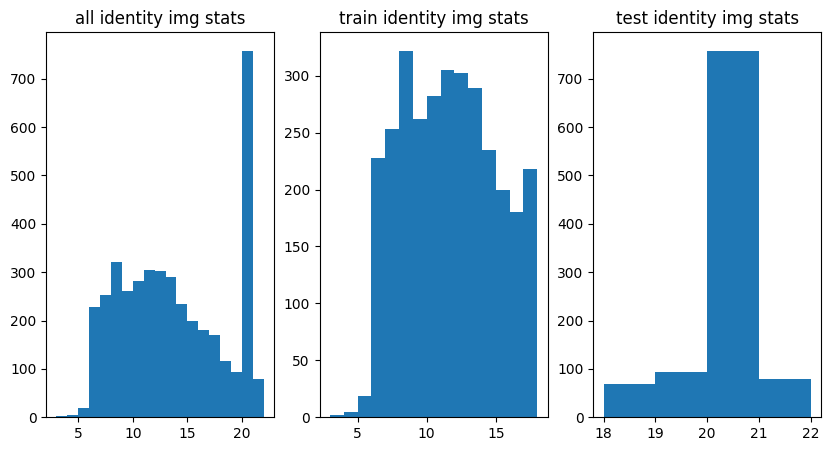

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.hist(num_imgs_per_pid, bins=19)
plt.title('all identity img stats')
plt.subplot(1,3,2)
plt.hist(num_train_imgs_per_pid, bins=15)
plt.title('train identity img stats')
plt.subplot(1,3,3)
plt.hist(num_test_imgs_per_pid, bins=4)
plt.title('test identity img stats')
plt.show()

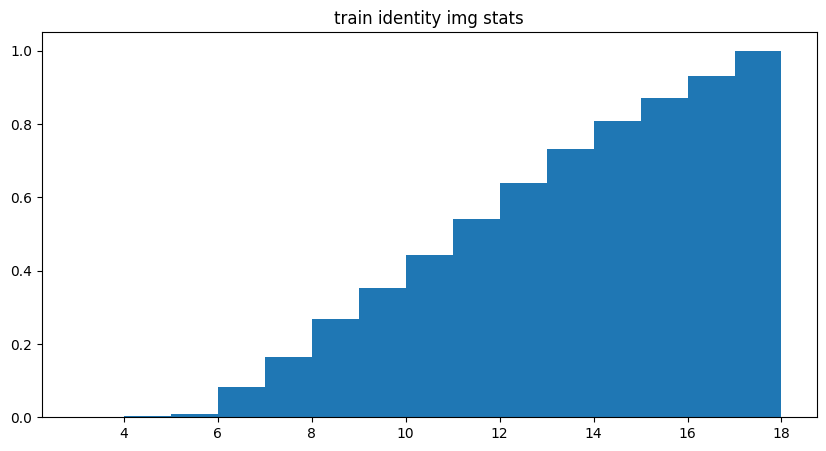

[ 3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.]
[6.44745326e-04 2.25660864e-03 8.38168923e-03 8.18826564e-02
 1.63442940e-01 2.67246937e-01 3.51708575e-01 4.42617666e-01
 5.40941328e-01 6.38297872e-01 7.31463572e-01 8.07221148e-01
 8.71695680e-01 9.29722760e-01 1.00000000e+00]


In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
# plt.subplot(1,3,1)
# plt.hist(num_imgs_per_pid, bins=22)
# plt.title('all identity img stats')
# plt.subplot(1,3,2)
n, bins, patches = plt.hist(num_train_imgs_per_pid, bins=15, density=True, cumulative=True,)
plt.title('train identity img stats')
# plt.subplot(1,3,3)
# plt.hist(num_test_imgs_per_pid, bins=22)
# plt.title('test identity img stats')
plt.show()

print(bins)
print(n)

In [12]:
(n*100).tolist()

[0.06447453255963895,
 0.2256608639587363,
 0.8381689232753062,
 8.188265635074146,
 16.344294003868473,
 26.72469374597034,
 35.170857511283046,
 44.26176660219213,
 54.094132817537066,
 63.82978723404255,
 73.14635718891037,
 80.72211476466795,
 87.16956802063184,
 92.97227595099935,
 100.0]

In [181]:
num_train_imgs_per_pid[num_train_imgs_per_pid<13].sum()/num_train_imgs_per_pid[num_train_imgs_per_pid>0].sum()

0.5189190748110977

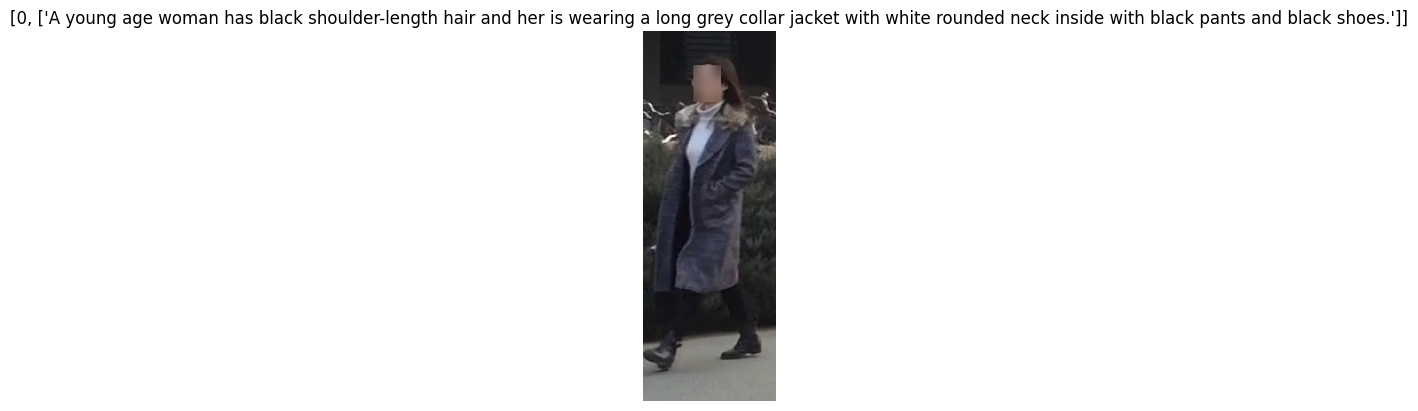

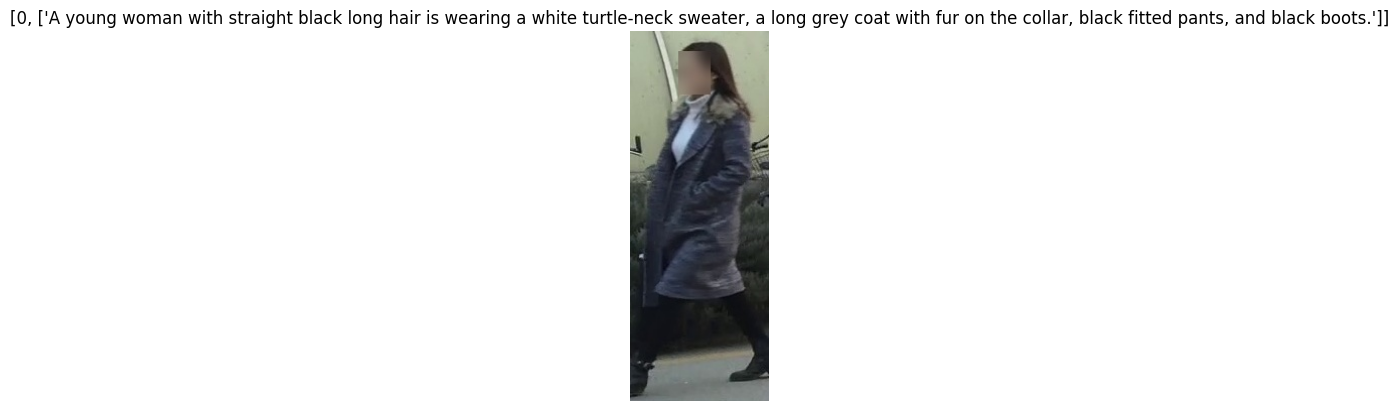

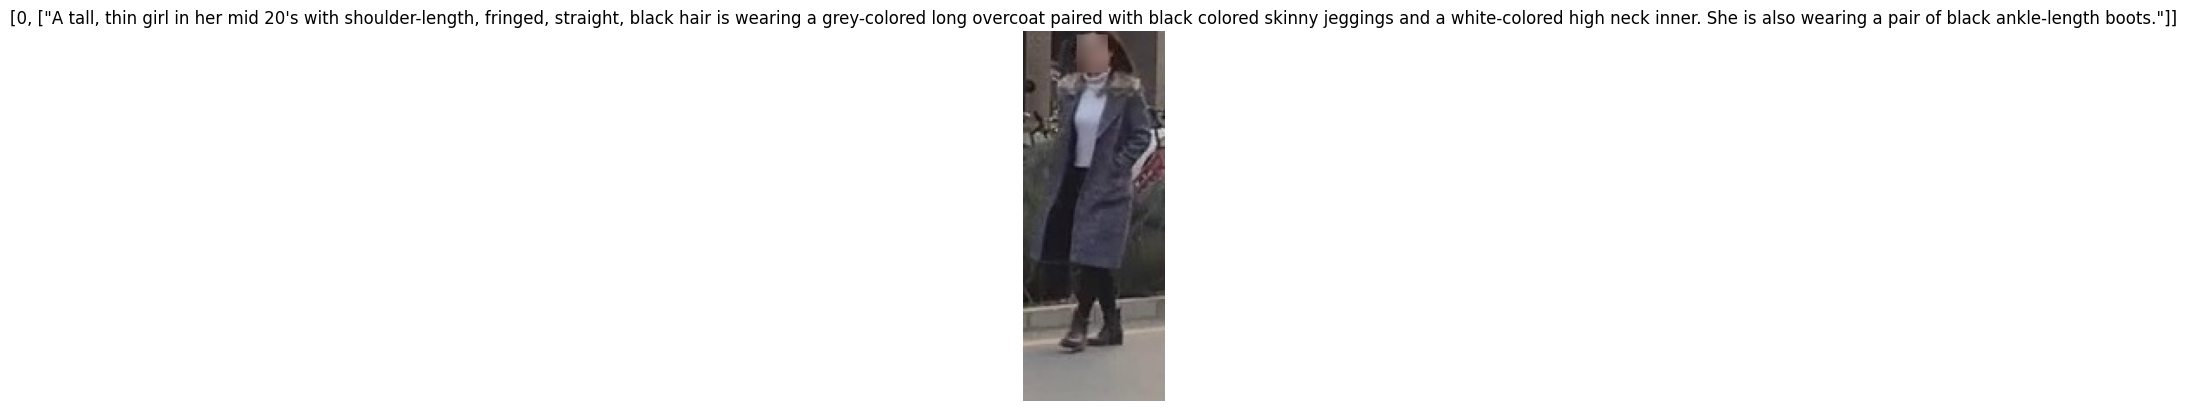

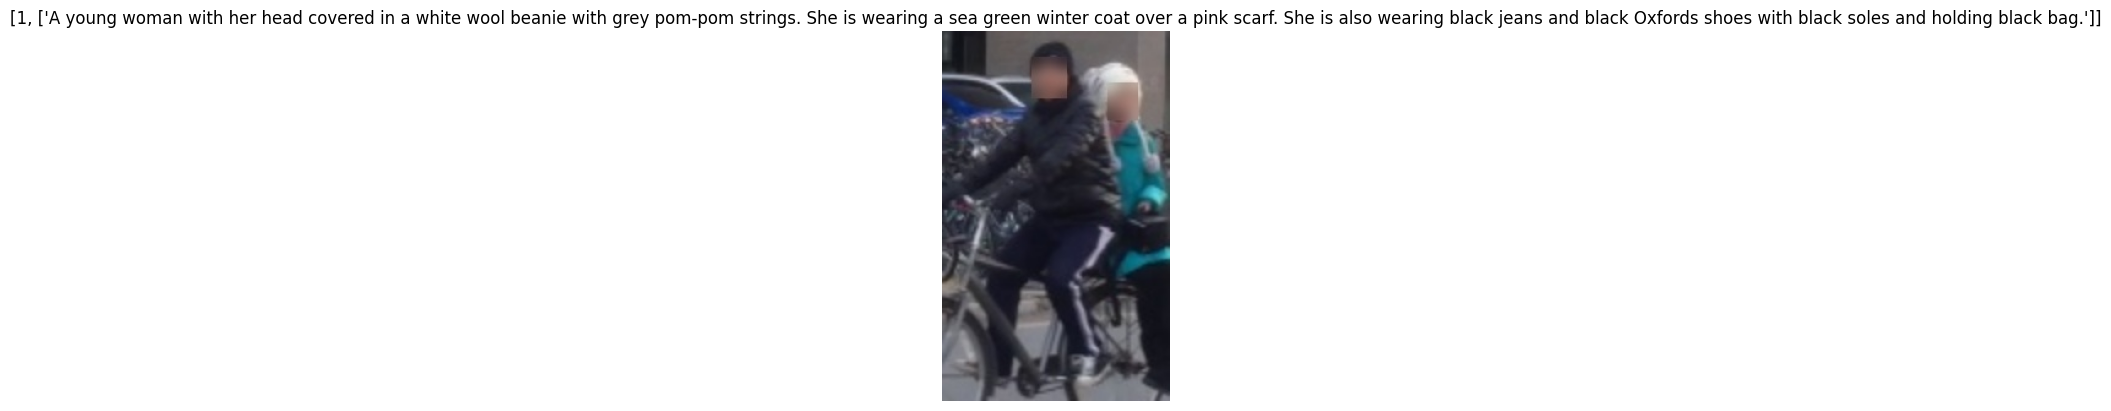

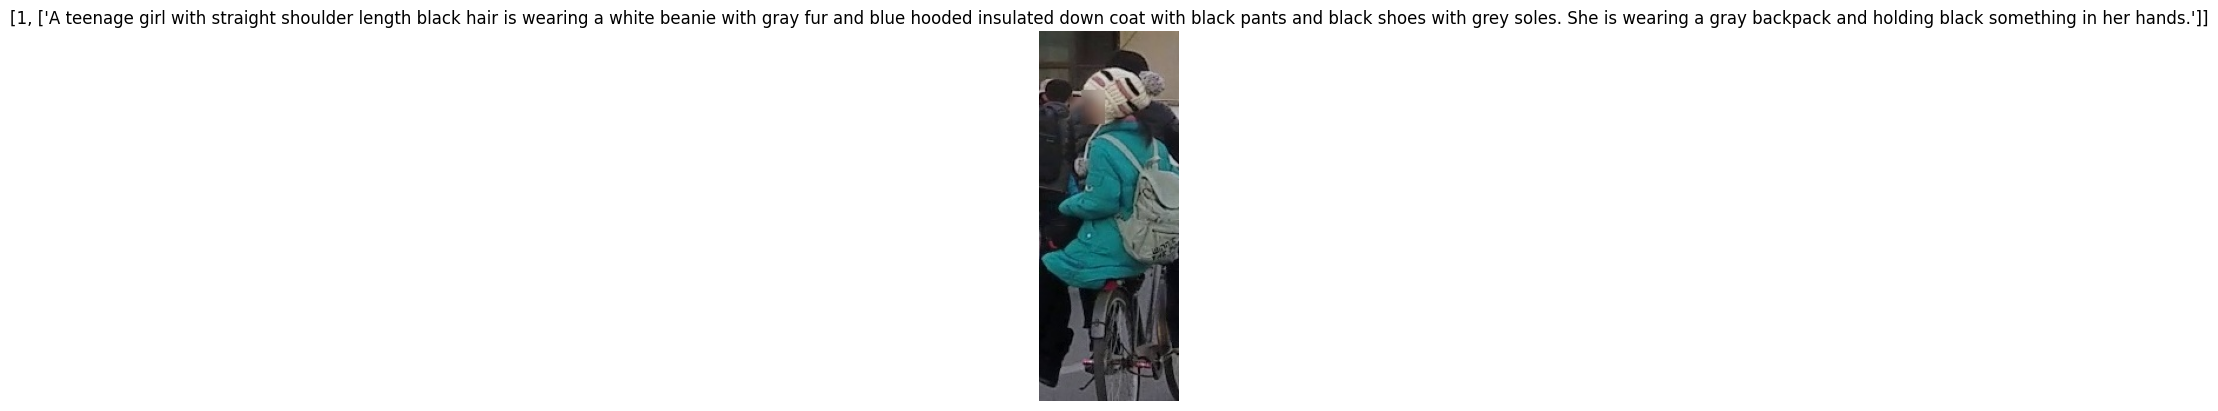

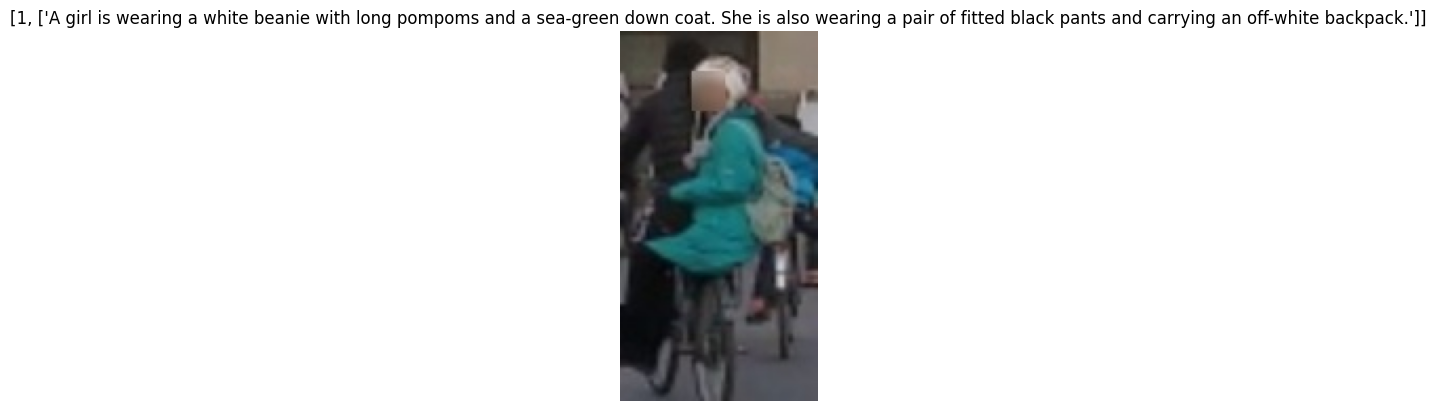

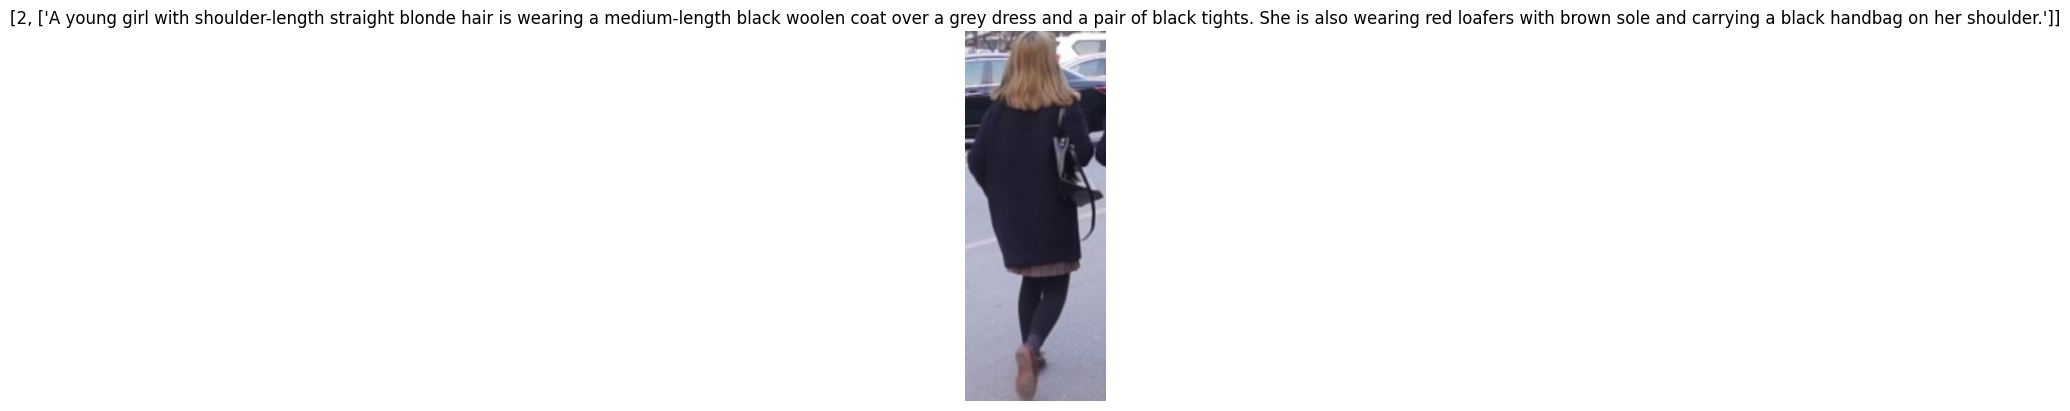

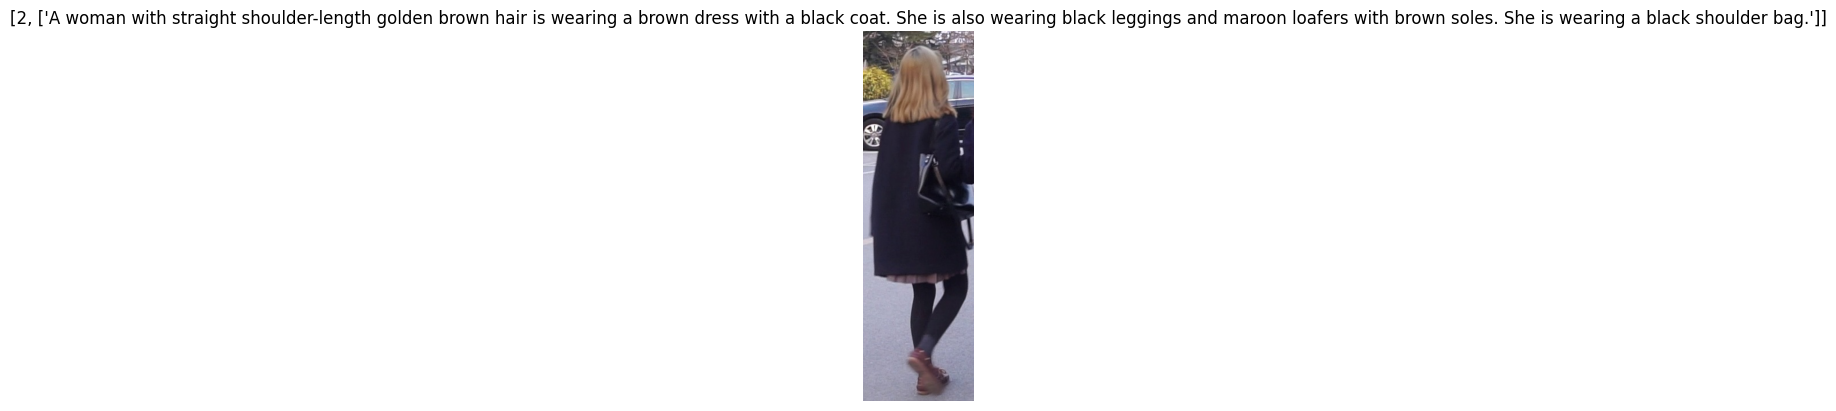

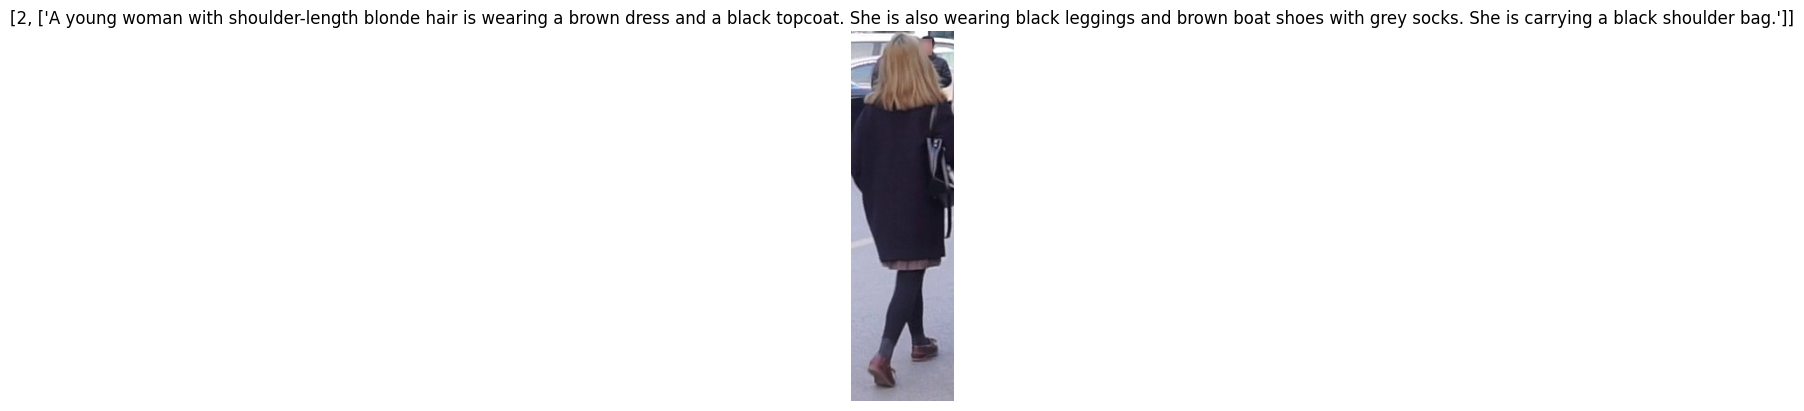

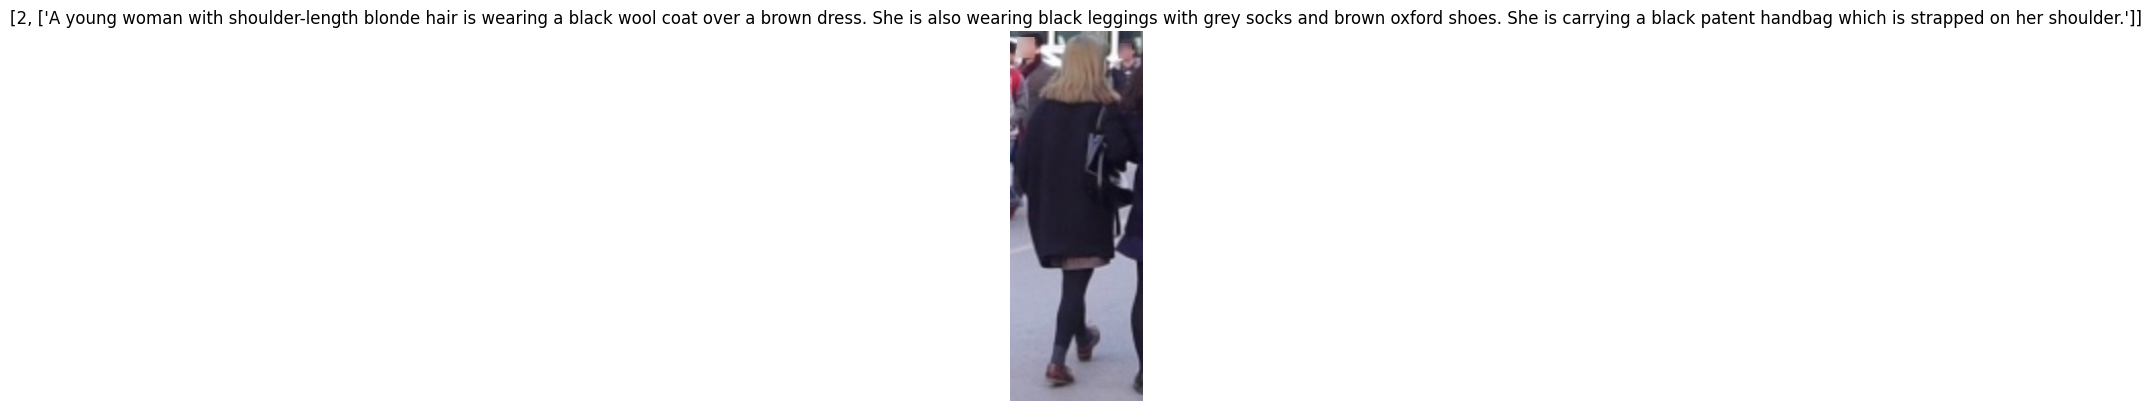

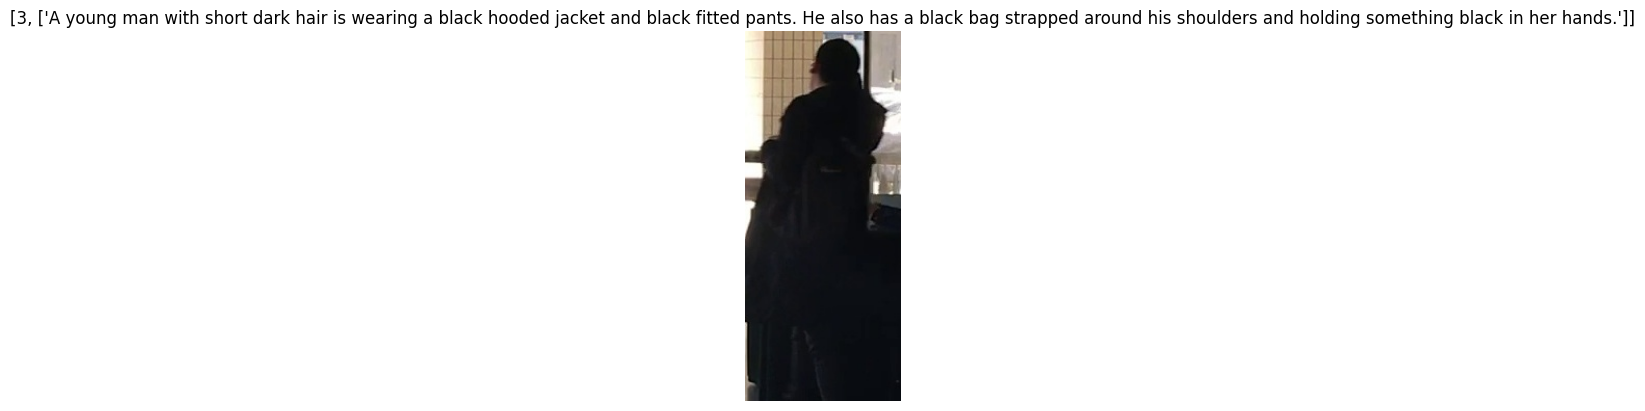

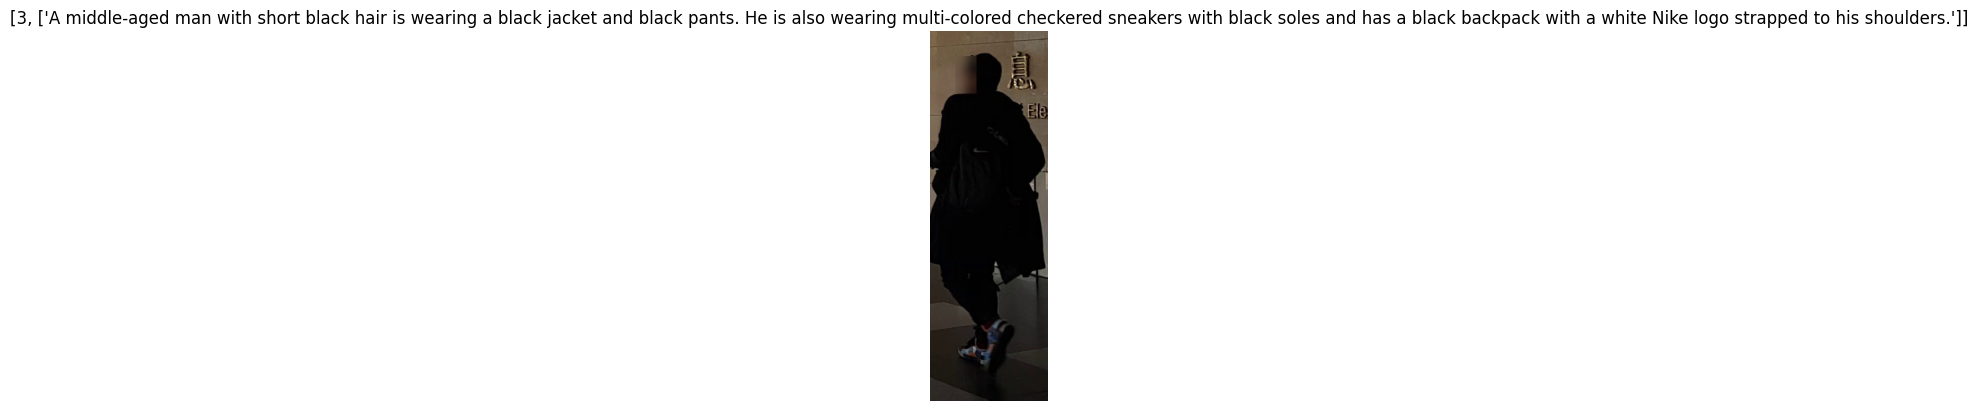

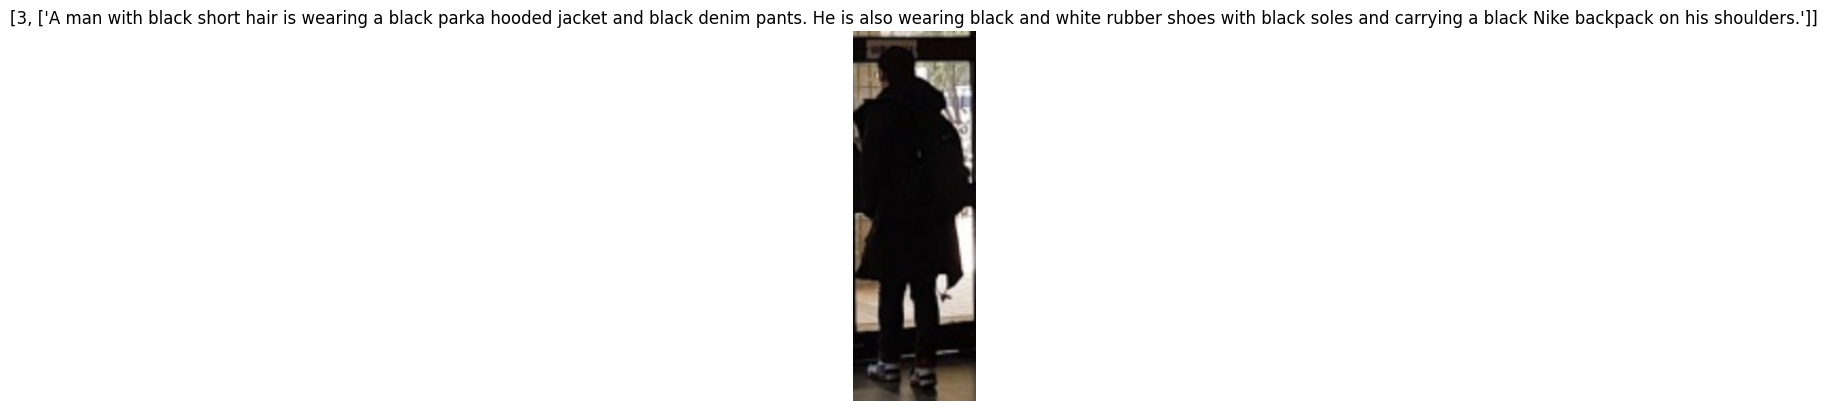

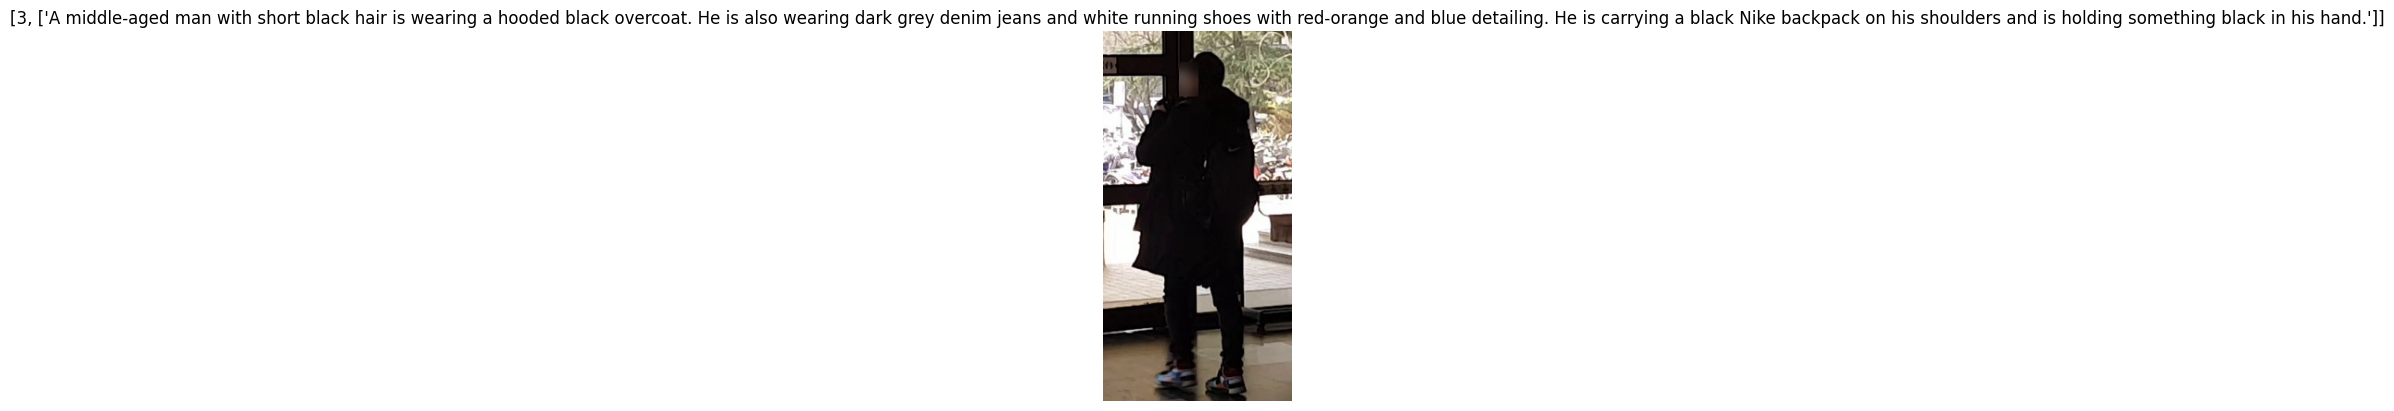

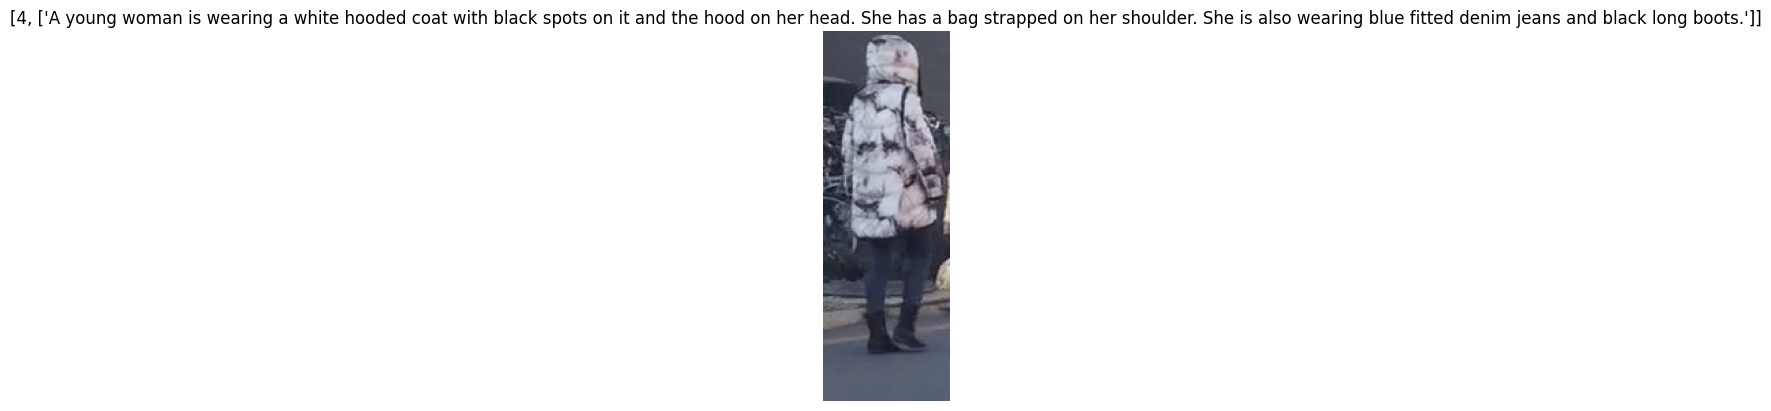

In [100]:
import matplotlib.pyplot as plt
import PIL.Image as Image

ICFG_img_path = '/home/jiahao/task/IRRA/input/images/ICFG-PEDES/imgs'

pid=0  #4102个identity，每个identity有5张图片，每张图片有2个caption
for i in range(pid*15, (pid+1)*15):
    img = Image.open(f"{ICFG_img_path}/{annos[i]['file_path']}").convert('RGB')
    plt.imshow(img)
    plt.title([annos[i]['id'], annos[i]['captions']])
    plt.axis('off')
    plt.show()


## CUHK-PEDES

- 13003个identity，每个identity平均有3.09张图片，每张图片有2个caption
- 训练集11003个identity,34054张图片，68108个caption
- 验证集1000个identity，3078张图片，6156个caption
- 测试集1000个identity，3074张图片，6148个caption

In [162]:

import json

with open('/home/jiahao/task/IRRA/input/images/CUHK-PEDES/reid_raw.json', 'r') as f:
    annos = json.load(f)

train_annos, test_annos, val_annos = [], [], []
for anno in annos:
    if anno['split'] == 'train':
        train_annos.append(anno)
    elif anno['split'] == 'test':
        test_annos.append(anno)
    else:
        val_annos.append(anno)

In [163]:
print(f"len(annos) = {len(annos)}")

len(annos) = 40206


In [164]:
annos[-1]

{'split': 'test',
 'captions': ['The woman is wearing a striped black and grey sweatshirt and dark blue jeans. She is carrying a handbag and wears white shoes.',
  'The woman is wearing a black and grey hoodie. She is wearing dark blue jeans and has a brown bag.'],
 'file_path': 'CUHK01/0681001.png',
 'processed_tokens': [['the',
   'woman',
   'is',
   'wearing',
   'a',
   'striped',
   'black',
   'and',
   'grey',
   'sweatshirt',
   'and',
   'dark',
   'blue',
   'jeans',
   'she',
   'is',
   'carrying',
   'a',
   'handbag',
   'and',
   'wears',
   'white',
   'shoes'],
  ['the',
   'woman',
   'is',
   'wearing',
   'a',
   'black',
   'and',
   'grey',
   'hoodie',
   'she',
   'is',
   'wearing',
   'dark',
   'blue',
   'jeans',
   'and',
   'has',
   'a',
   'brown',
   'bag']],
 'id': 13003}

In [165]:
annos[0]

{'split': 'train',
 'captions': ['A pedestrian with dark hair is wearing red and white shoes, a black hooded sweatshirt, and black pants.',
  'The person has short black hair and is wearing black pants, a long sleeve black top, and red sneakers.'],
 'file_path': 'CUHK01/0363004.png',
 'processed_tokens': [['a',
   'pedestrian',
   'with',
   'dark',
   'hair',
   'is',
   'wearing',
   'red',
   'and',
   'white',
   'shoes',
   'a',
   'black',
   'hooded',
   'sweatshirt',
   'and',
   'black',
   'pants'],
  ['the',
   'person',
   'has',
   'short',
   'black',
   'hair',
   'and',
   'is',
   'wearing',
   'black',
   'pants',
   'a',
   'long',
   'sleeve',
   'black',
   'top',
   'and',
   'red',
   'sneakers']],
 'id': 1}

In [166]:
pids = set()
splits = set()
file_paths = set()
for anno in annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))



pids = set()
splits = set()
file_paths = set()
for anno in train_annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))


pids = set()
splits = set()
file_paths = set()
for anno in val_annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))


pids = set()
splits = set()
file_paths = set()
for anno in test_annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))



13003
{'train', 'val', 'test'}
40206
11003
{'train'}
34054
1000
{'val'}
3078
1000
{'test'}
3074


In [167]:
import numpy as np


num_imgs_per_pid = np.zeros(13003)
for anno in annos:
    num_imgs_per_pid[anno['id']-1] += 1

print('\nall identity img stats: ')
print(len(annos))
print(num_imgs_per_pid.mean())
print(num_imgs_per_pid.max())
print(num_imgs_per_pid.min())
print(num_imgs_per_pid.std())


num_train_imgs_per_pid = np.zeros(11003)
for anno in train_annos:
    num_train_imgs_per_pid[anno['id']-1] += 1

print('\ntrain identity img stats: ')
print(len(train_annos))
print(num_train_imgs_per_pid.mean())
print(num_train_imgs_per_pid.max())
print(num_train_imgs_per_pid.min())
print(num_train_imgs_per_pid.std())


num_val_imgs_per_pid = np.zeros(1000)
for anno in val_annos:
    num_val_imgs_per_pid[anno['id']-1-11003] += 1

print('\nval identity img stats: ')
print(len(val_annos))
print(num_val_imgs_per_pid.mean())
print(num_val_imgs_per_pid.max())
print(num_val_imgs_per_pid.min())
print(num_val_imgs_per_pid.std())


num_test_imgs_per_pid = np.zeros(1000)
for anno in test_annos:
    num_test_imgs_per_pid[anno['id']-1-12003] += 1

print('\ntest identity img stats: ')
print(len(test_annos))
print(num_test_imgs_per_pid.mean())
print(num_test_imgs_per_pid.max())
print(num_test_imgs_per_pid.min())
print(num_test_imgs_per_pid.std())


all identity img stats: 
40206
3.0920556794585865
15.0
1.0
1.121092832369439

train identity img stats: 
34054
3.09497409797328
15.0
1.0
1.1265371240278559

val identity img stats: 
3078
3.078
12.0
2.0
1.0999618175191357

test identity img stats: 
3074
3.074
10.0
1.0
1.0809828860809962


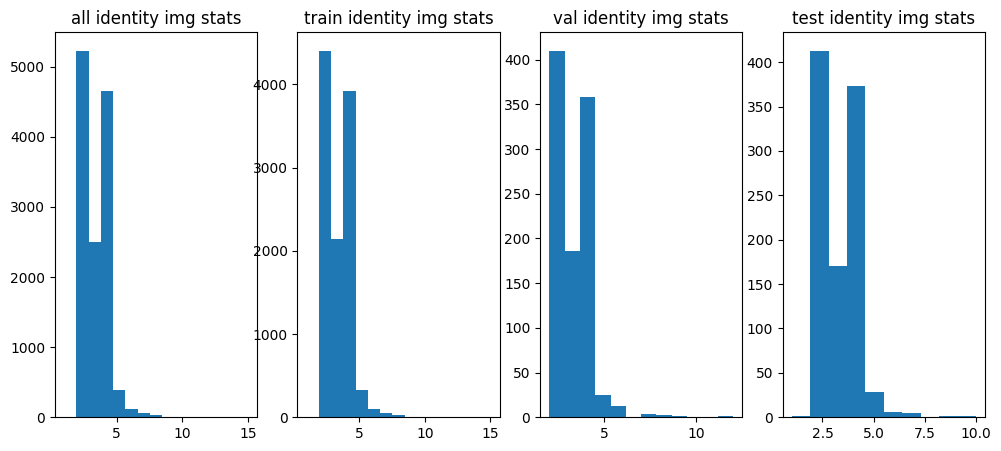

In [168]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,4,1)
plt.hist(num_imgs_per_pid, bins=15)
plt.title('all identity img stats')
plt.subplot(1,4,2)
plt.hist(num_train_imgs_per_pid, bins=15)
plt.title('train identity img stats')
plt.subplot(1,4,3)
plt.hist(num_val_imgs_per_pid, bins=12)
plt.title('val identity img stats')
plt.subplot(1,4,4)
plt.hist(num_test_imgs_per_pid, bins=10)
plt.title('test identity img stats')
plt.show()

In [172]:
num_train_imgs_per_pid[num_train_imgs_per_pid<5].sum()/num_train_imgs_per_pid[num_train_imgs_per_pid>0].sum()

0.9074704880483937

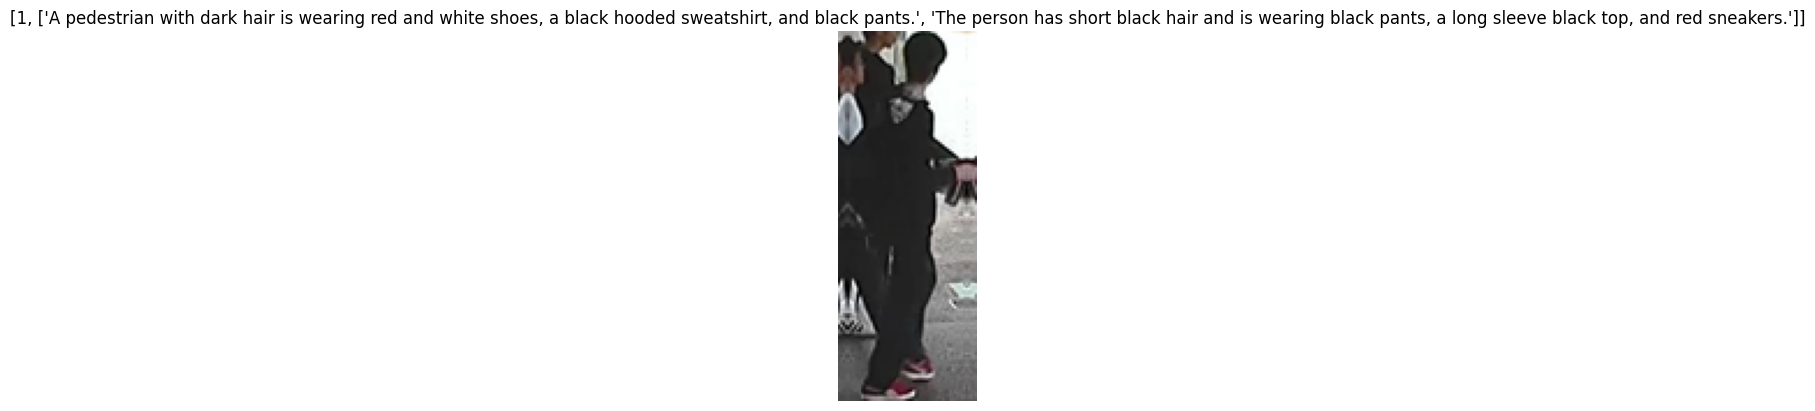

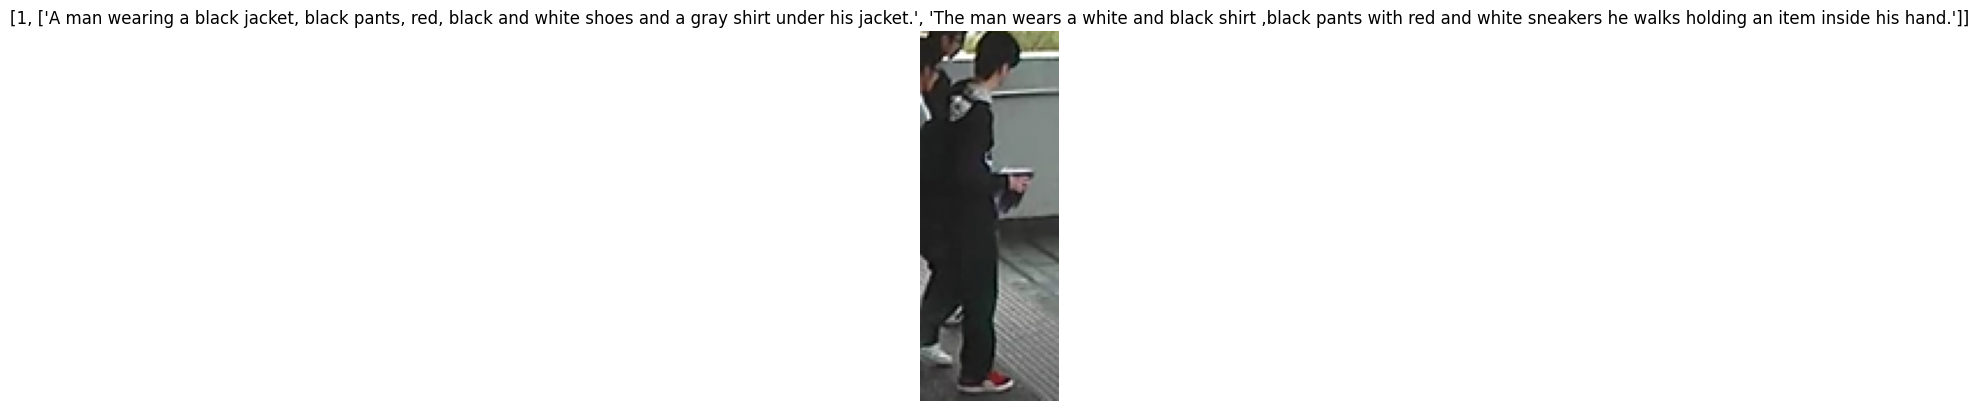

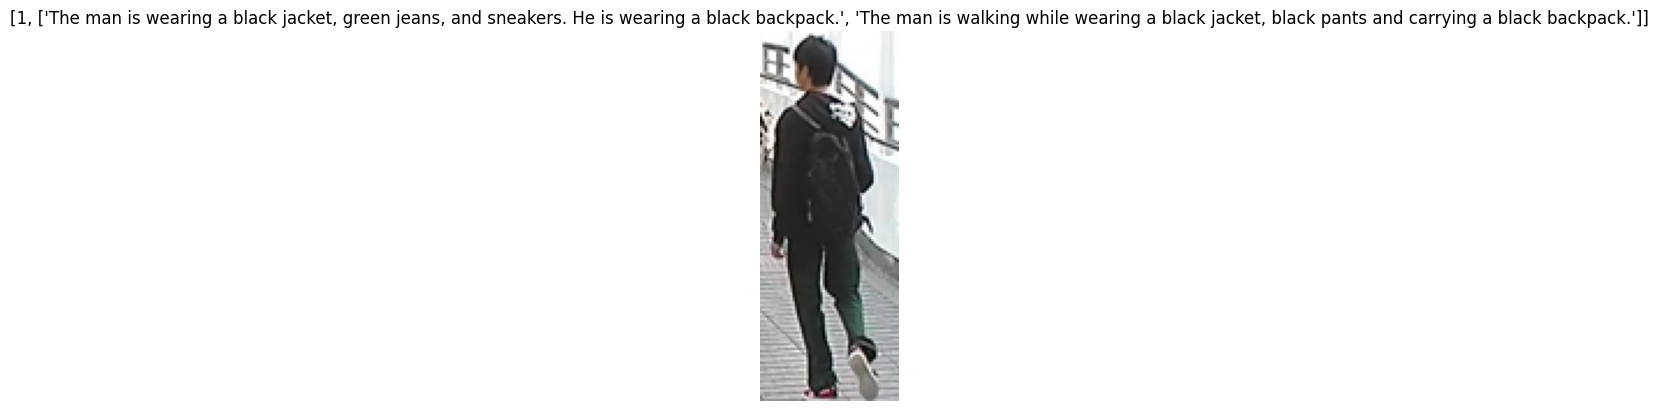

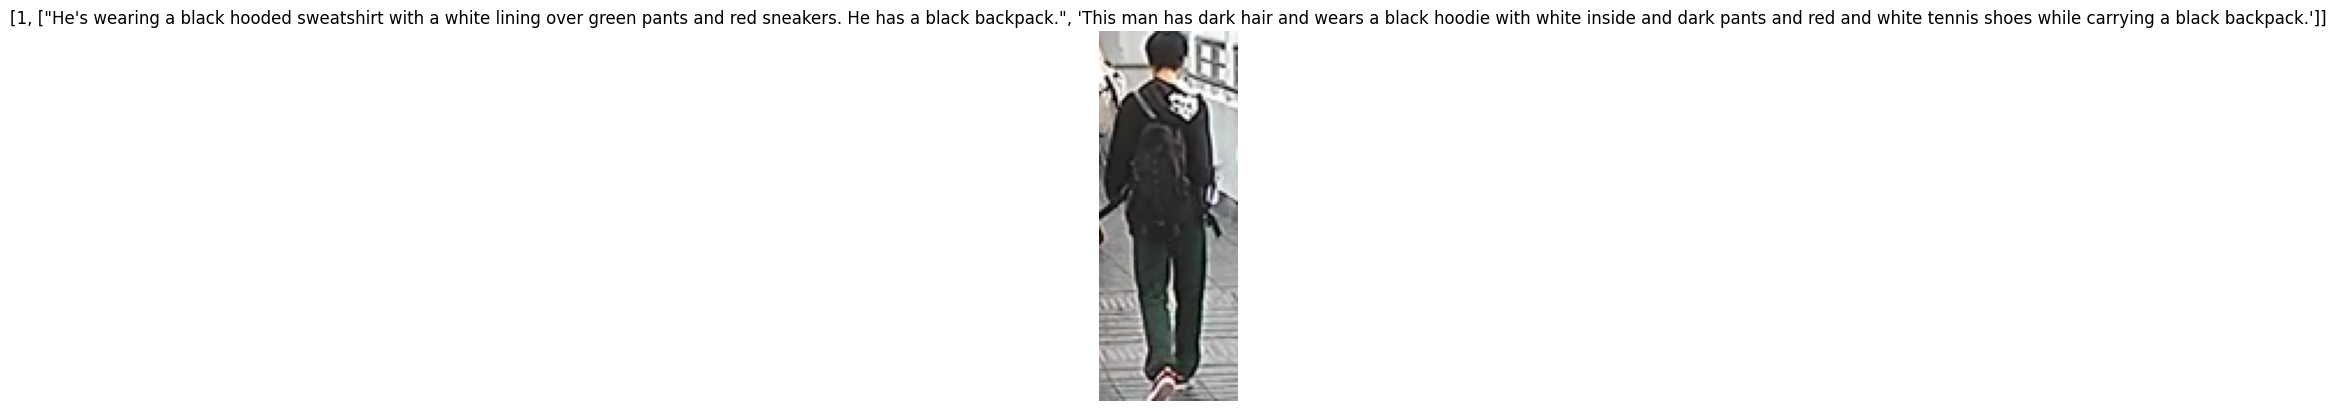

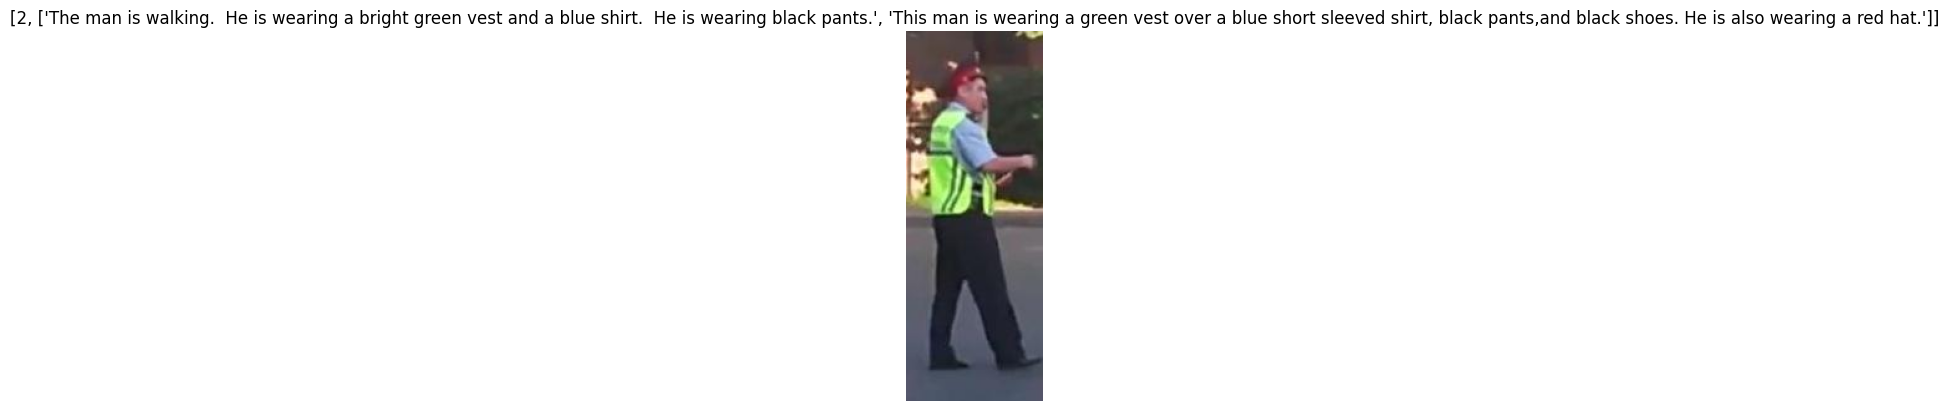

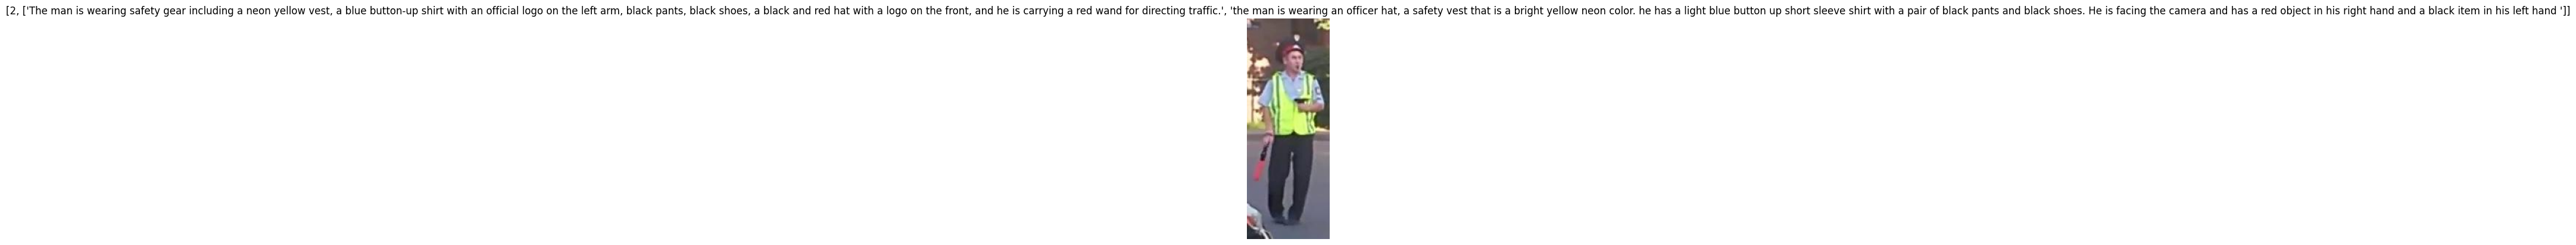

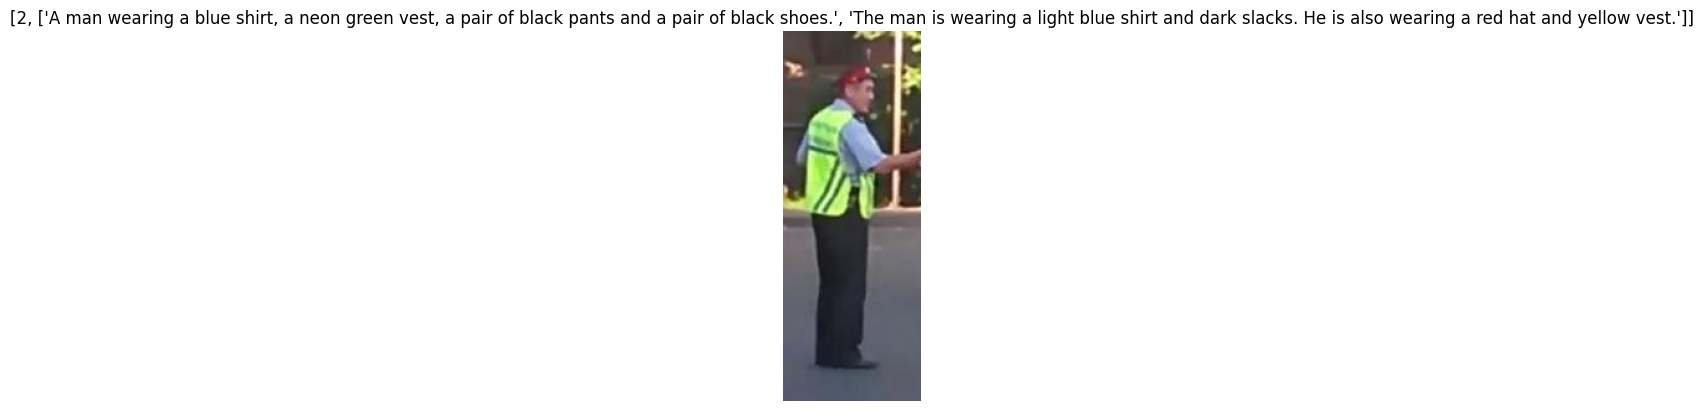

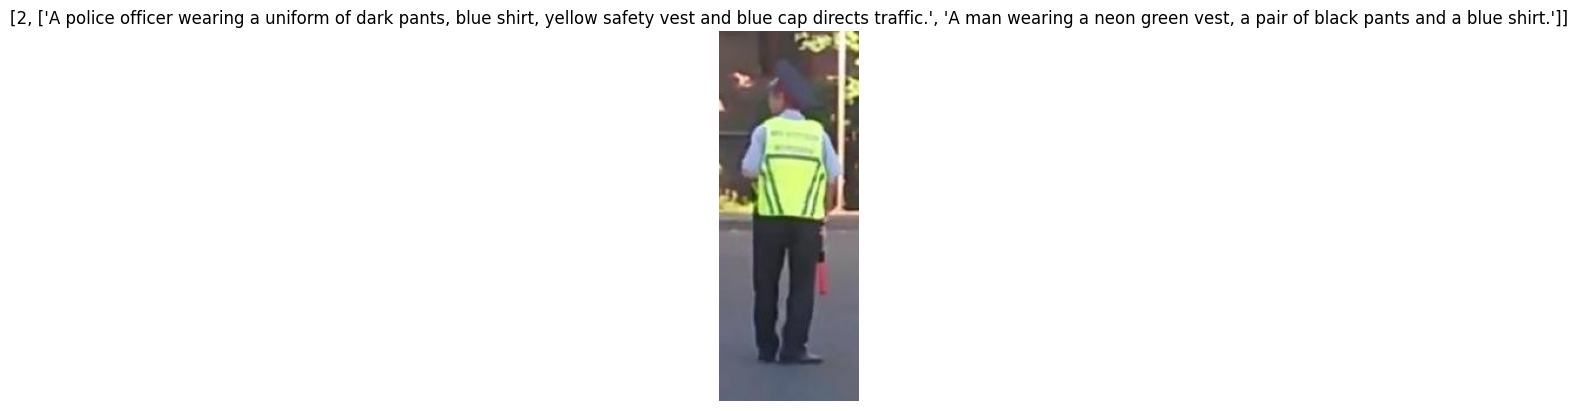

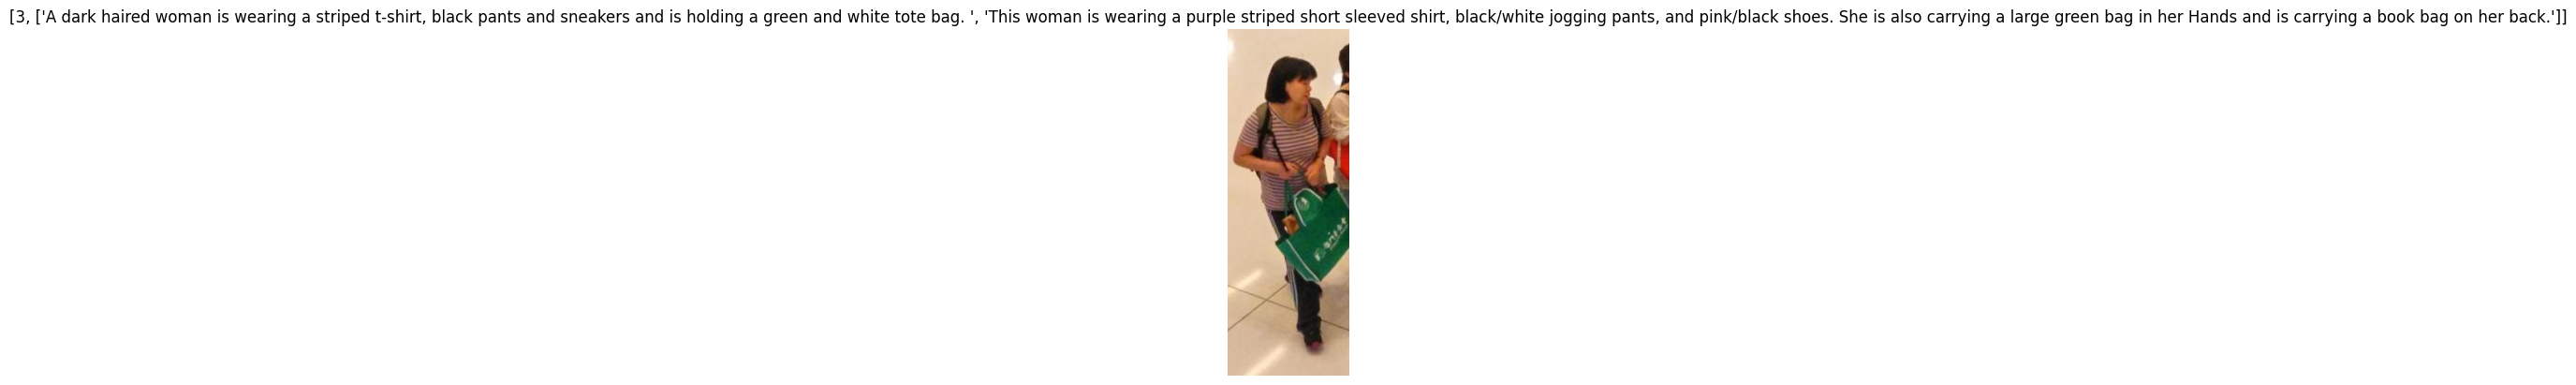

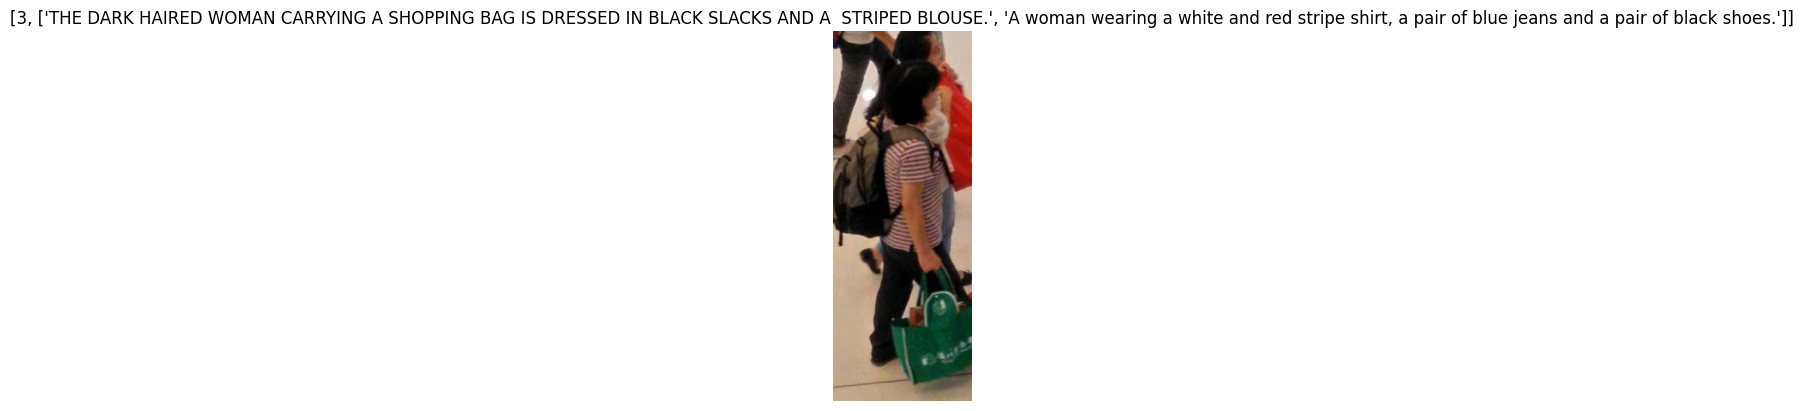

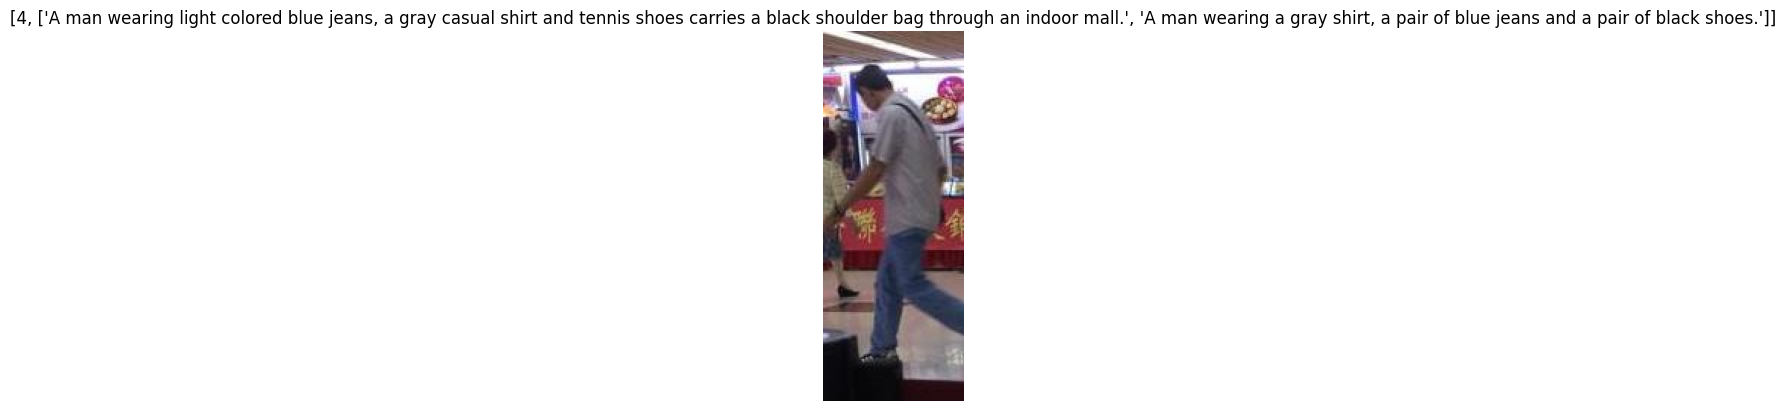

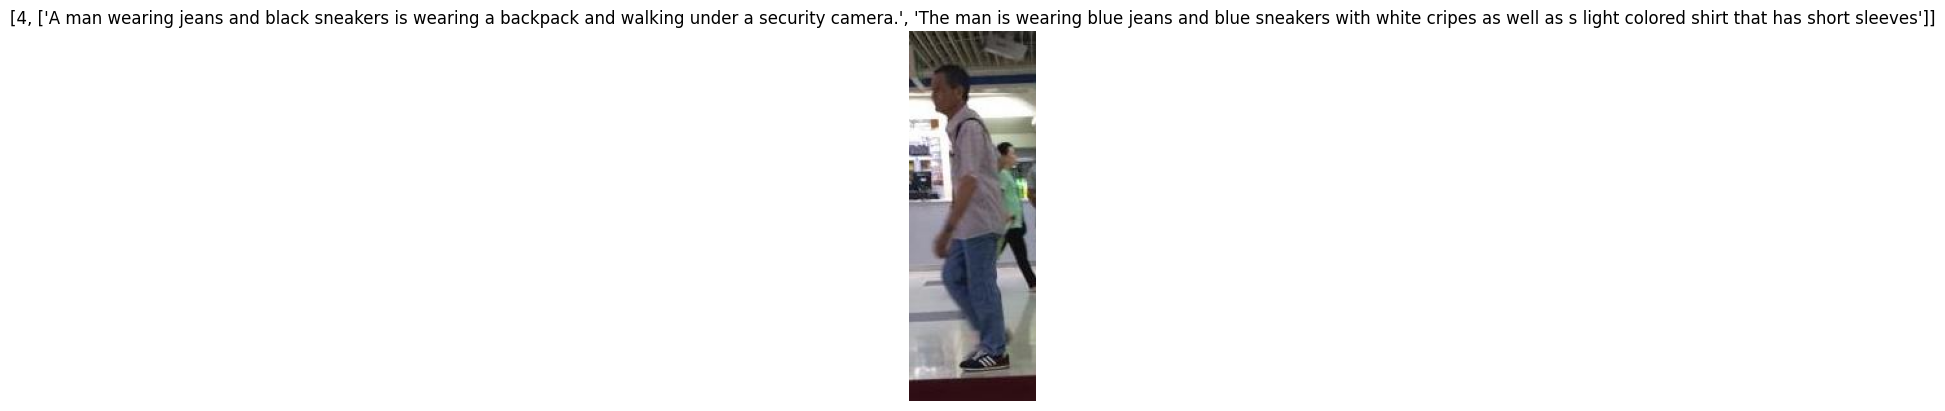

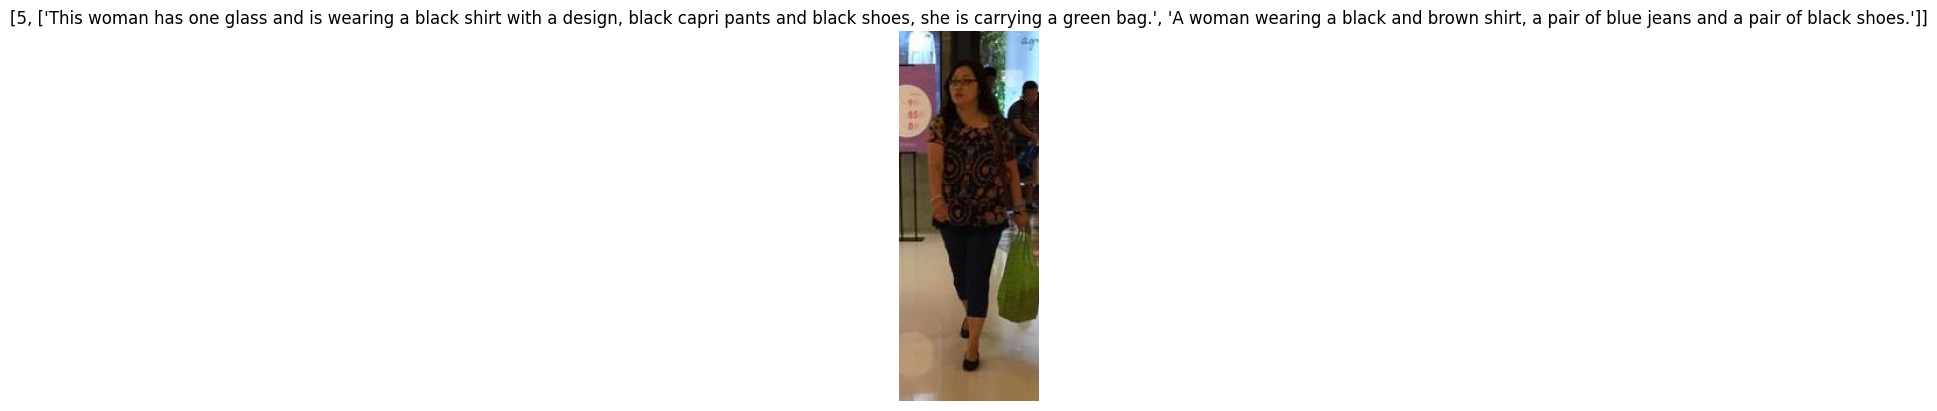

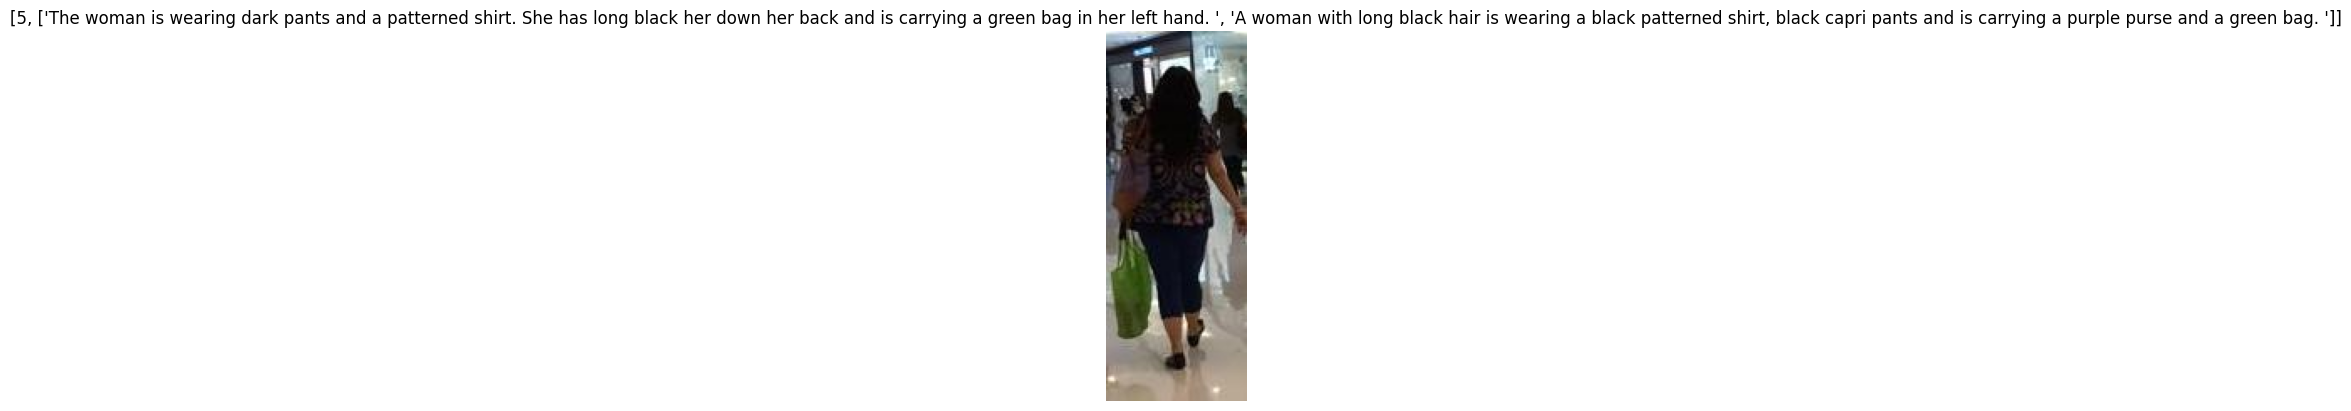

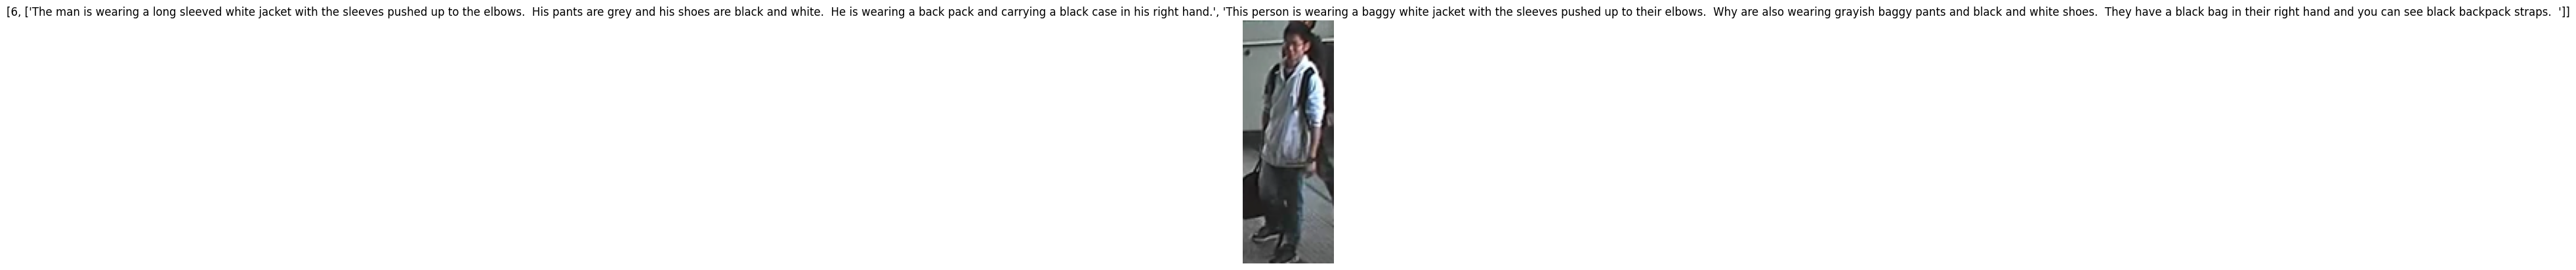

In [169]:
import matplotlib.pyplot as plt
import PIL.Image as Image

CUHK_img_path = '/home/jiahao/task/IRRA/input/images/CUHK-PEDES/imgs'

pid=0  #4102个identity，每个identity有5张图片，每张图片有2个caption
for i in range(pid*15, (pid+1)*15):
    img = Image.open(f"{CUHK_img_path}/{annos[i]['file_path']}").convert('RGB')
    plt.imshow(img)
    plt.title([annos[i]['id'], annos[i]['captions']])
    plt.axis('off')
    plt.show()


# Sample Selection & Uncetainty vs. TP/FP Analysis

In [588]:
import numpy as np
from prettytable import PrettyTable
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt


def rank(similarity, q_pids, g_pids, max_rank=10, get_mAP=True):
    if get_mAP:
        indices = torch.argsort(similarity, dim=1, descending=True)
    else:
        # acclerate sort with topk
        _, indices = torch.topk(
            similarity, k=max_rank, dim=1, largest=True, sorted=True
        )  # q * topk
    pred_labels = g_pids[indices.cpu()]  # q * k
    matches = pred_labels.eq(q_pids.view(-1, 1))  # q * k

    all_cmc = matches[:, :max_rank].cumsum(1) # cumulative sum
    all_cmc[all_cmc > 1] = 1
    all_cmc = all_cmc.float().mean(0) * 100
    # all_cmc = all_cmc[topk - 1]

    if not get_mAP:
        return all_cmc, indices

    num_rel = matches.sum(1)  # q
    tmp_cmc = matches.cumsum(1)  # q * k

    inp = [tmp_cmc[i][match_row.nonzero()[-1]] / (match_row.nonzero()[-1] + 1.) for i, match_row in enumerate(matches)]
    mINP = torch.cat(inp).mean() * 100

    tmp_cmc = [tmp_cmc[:, i] / (i + 1.0) for i in range(tmp_cmc.shape[1])]
    tmp_cmc = torch.stack(tmp_cmc, 1) * matches
    AP = tmp_cmc.sum(1) / num_rel  # q
    mAP = AP.mean() * 100

    return all_cmc, mAP, mINP, indices

def computer_metric(similarity, qids, gids, i2t_metric=False):
    t2i_cmc, t2i_mAP, t2i_mINP, _ = rank(similarity=similarity.cpu(), q_pids=qids.cpu(), g_pids=gids.cpu(), max_rank=10, get_mAP=True)
    t2i_cmc, t2i_mAP, t2i_mINP = t2i_cmc.numpy(), t2i_mAP.numpy(), t2i_mINP.numpy()
    table = PrettyTable(["task", "R1", "R5", "R10", "mAP", "mINP"])
    table.add_row(['t2i', t2i_cmc[0], t2i_cmc[4], t2i_cmc[9], t2i_mAP, t2i_mINP])

    if i2t_metric:
        i2t_cmc, i2t_mAP, i2t_mINP, _ = rank(similarity=similarity.cpu().t(), q_pids=gids.cpu(), g_pids=qids.cpu(), max_rank=10, get_mAP=True)
        i2t_cmc, i2t_mAP, i2t_mINP = i2t_cmc.numpy(), i2t_mAP.numpy(), i2t_mINP.numpy()
        table.add_row(['i2t', i2t_cmc[0], i2t_cmc[4], i2t_cmc[9], i2t_mAP, i2t_mINP])
    # table.float_format = '.4'
    table.custom_format["R1"] = lambda f, v: f"{v:.3f}"
    table.custom_format["R5"] = lambda f, v: f"{v:.3f}"
    table.custom_format["R10"] = lambda f, v: f"{v:.3f}"
    table.custom_format["mAP"] = lambda f, v: f"{v:.3f}"
    table.custom_format["mINP"] = lambda f, v: f"{v:.3f}"
    print(str(table))

    eval_result = {
        'R1': t2i_cmc[0],
        'R5': t2i_cmc[4],
        'R10': t2i_cmc[9],
        'mAP': t2i_mAP,
        'mINP': t2i_mINP,
    }

    return eval_result

## ham_rstp_tta

In [589]:
ham_rstp_tta_embeds_dict = {}
ham_rstp_tta_embeds_dict["sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["uncertaintys_list"] = np.load('debug_embeddings/ham_rstp_tta/uncertaintys_list.npy')
ham_rstp_tta_embeds_dict["ss_idxs_list"] = np.load('debug_embeddings/ham_rstp_tta/ss_idxs_list.npy')
ham_rstp_tta_embeds_dict["sampled_sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_idx_t2i.npy')
ham_rstp_tta_embeds_dict["qids"] = np.load('debug_embeddings/ham_rstp_tta/qids.npy')
ham_rstp_tta_embeds_dict["gids"] = np.load('debug_embeddings/ham_rstp_tta/gids.npy')
ham_rstp_tta_embeds_dict["qfeats"] = np.load('debug_embeddings/ham_rstp_tta/qfeats.npy')
ham_rstp_tta_embeds_dict["gfeats"] = np.load('debug_embeddings/ham_rstp_tta/gfeats.npy')

### origin score

In [590]:
qfeats_norm = F.normalize(torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"]), p=2, dim=1)
gfeats_norm = F.normalize(torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"]), p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
sims_matrix_t2i = torch.from_numpy(ham_rstp_tta_embeds_dict["sims_matrix_t2i"])

print("eval_result_norm")
ham_rstp_tta_embeds_dict['eval_result_norm'] = computer_metric(
    sims_matrix_t2i_norm,
    torch.from_numpy(ham_rstp_tta_embeds_dict["qids"]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
)
print("eval_result")
ham_rstp_tta_embeds_dict['eval_result'] = computer_metric(
    sims_matrix_t2i,
    torch.from_numpy(ham_rstp_tta_embeds_dict["qids"]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
)

eval_result_norm
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 59.500 | 80.050 | 87.050 | 44.116 | 20.549 |
+------+--------+--------+--------+--------+--------+
eval_result
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 58.850 | 79.850 | 86.900 | 44.181 | 20.821 |
+------+--------+--------+--------+--------+--------+


### sample selection score

In [591]:
ss_idxs_list = ham_rstp_tta_embeds_dict["ss_idxs_list"].tolist()
print('sample selection samples : ',len(ss_idxs_list))

qfeats_norm = F.normalize(torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"]), p=2, dim=1)
gfeats_norm = F.normalize(torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"]), p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
print("eval_result_norm_ss")
ham_rstp_tta_embeds_dict['eval_result_norm_ss'] = computer_metric(
    sims_matrix_t2i_norm[ss_idxs_list],
    torch.from_numpy(ham_rstp_tta_embeds_dict["qids"][ss_idxs_list]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
)
print("eval_result_ss")
ham_rstp_tta_embeds_dict['eval_result_ss'] = computer_metric(
    torch.from_numpy(ham_rstp_tta_embeds_dict["sims_matrix_t2i"][ss_idxs_list]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["qids"][ss_idxs_list]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
)

sample selection samples :  389
eval_result_norm_ss
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 85.861 | 94.859 | 97.172 | 57.674 | 27.175 |
+------+--------+--------+--------+--------+--------+
eval_result_ss
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 86.632 | 95.116 | 96.658 | 57.797 | 27.400 |
+------+--------+--------+--------+--------+--------+


### uncertainty vs. TP/FP

(2000,)
(2000, 1000)
(2000,)
(1000,)

TP_unc.stats,    FP_unc.stats
1177               823
1.5197006       1.7280664
2.356522       2.3125365
1.0                 1.0
0.30335003       0.23248409


(array([ 17.,   5.,   3.,   4.,   1.,   5.,   9.,   3.,   8.,   8.,   1.,
          7.,  16.,  11., 257., 113.,  71.,  38.,  42.,  31.,  20.,  22.,
         19.,  19.,  23.,  26.,  16.,  12.,   8.,   8.]),
 array([1.        , 1.04375124, 1.08750248, 1.13125372, 1.17500484,
        1.21875608, 1.26250732, 1.30625856, 1.35000968, 1.39376092,
        1.43751216, 1.4812634 , 1.52501464, 1.56876588, 1.61251712,
        1.65626824, 1.70001948, 1.74377072, 1.78752184, 1.83127308,
        1.87502432, 1.91877556, 1.9625268 , 2.00627804, 2.05002928,
        2.09378052, 2.13753176, 2.181283  , 2.22503424, 2.26878548,
        2.31253648]),
 <BarContainer object of 30 artists>)

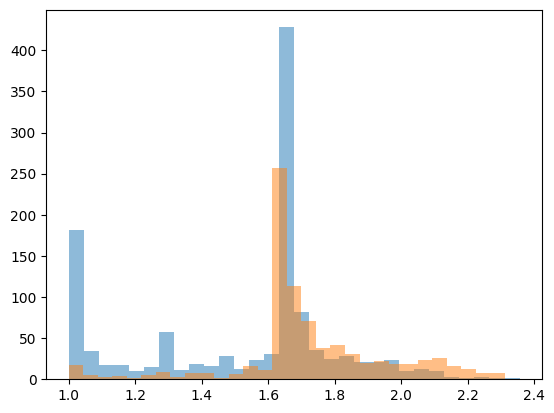

In [592]:
print(ham_rstp_tta_embeds_dict["uncertaintys_list"].shape)
print(ham_rstp_tta_embeds_dict["sims_matrix_t2i"].shape)

print(ham_rstp_tta_embeds_dict["qids"].shape)
print(ham_rstp_tta_embeds_dict["gids"].shape)

TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(ham_rstp_tta_embeds_dict["sims_matrix_t2i"], ham_rstp_tta_embeds_dict["uncertaintys_list"])):
    sims_topk, idx_topk = torch.from_numpy(sims_t2i).topk(k=128, dim=-1)
    if ham_rstp_tta_embeds_dict["gids"][idx_topk[0].numpy()] == ham_rstp_tta_embeds_dict["qids"][sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print("\nTP_unc.stats,    FP_unc.stats")
print(len(TP_unc), '             ', len(FP_unc))
print(np.mean(TP_unc), '     ', np.mean(FP_unc))
print(np.max(TP_unc), '     ', np.max(FP_unc))
print(np.min(TP_unc), '               ', np.min(FP_unc))
print(np.std(TP_unc), '     ', np.std(FP_unc))

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
plt.hist(TP_unc, bins=30, alpha=0.5)
# plt.subplot(1,2,2)
plt.hist(FP_unc, bins=30, alpha=0.5)

# plt.hist(ham_rstp_tta_embeds_dict["uncertaintys_list"], bins=30, alpha=0.5)

In [593]:
# mean_TP_unc = np.mean(TP_unc)
# print(mean_TP_unc)
# print(np.mean([np.abs(i-mean_TP_unc) for i in TP_unc]))


# mean_FP_unc = np.mean(FP_unc)
# print(mean_FP_unc)
# print(np.mean([np.abs(i-mean_FP_unc) for i in FP_unc]))


# mean_TP_unc = np.mean(TP_unc)
# plt.hist([i-mean_TP_unc for i in TP_unc], bins=30, alpha=0.5)

# # plt.subplot(1,2,2)
# mean_FP_unc = np.mean(FP_unc)
# plt.hist([i-mean_FP_unc for i in FP_unc], bins=30, alpha=0.5)

### Uncertainty_SS vs. TP/FP

(389,)
(389, 8)
(389,)
(1000,)

TP_unc.stats,    FP_unc.stats
337               52
1.1072391       1.1777267
1.6132863       1.5560167
1.0                 1.0
0.14353956       0.16650653


(array([15.,  1.,  2.,  3.,  1.,  1.,  2.,  2.,  0.,  2.,  1.,  0.,  3.,
         2.,  1.,  4.,  1.,  2.,  0.,  2.,  1.,  1.,  1.,  0.,  0.,  0.,
         0.,  0.,  2.,  2.]),
 array([1.        , 1.01853395, 1.03706777, 1.05560172, 1.07413554,
        1.09266949, 1.11120331, 1.12973726, 1.14827108, 1.16680503,
        1.18533885, 1.2038728 , 1.22240663, 1.24094057, 1.25947452,
        1.27800834, 1.29654217, 1.31507611, 1.33361006, 1.35214388,
        1.37067771, 1.38921165, 1.4077456 , 1.42627943, 1.44481337,
        1.4633472 , 1.48188114, 1.50041509, 1.51894891, 1.53748274,
        1.55601668]),
 <BarContainer object of 30 artists>)

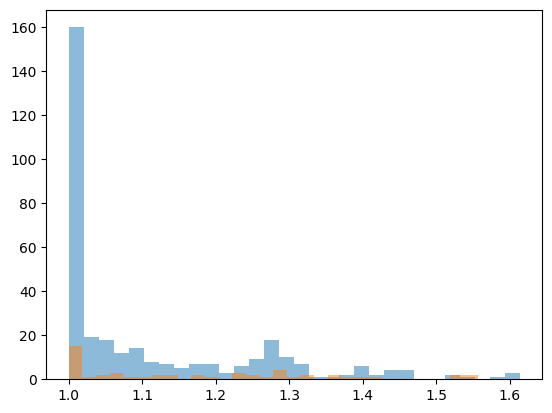

In [594]:
print(ham_rstp_tta_embeds_dict["uncertaintys_list"][ss_idxs_list].shape)
print(ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"][ss_idxs_list].shape)

print(ham_rstp_tta_embeds_dict["qids"][ss_idxs_list].shape)
print(ham_rstp_tta_embeds_dict["gids"].shape)

TP_unc = []
FP_unc = []
for sample_idx, (sampled_sim_idx, unc) in enumerate(zip(ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"][ss_idxs_list], ham_rstp_tta_embeds_dict["uncertaintys_list"][ss_idxs_list])):
    if ham_rstp_tta_embeds_dict["gids"][sampled_sim_idx[0]] == ham_rstp_tta_embeds_dict["qids"][ss_idxs_list][sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print("\nTP_unc.stats,    FP_unc.stats")
print(len(TP_unc), '             ', len(FP_unc))
print(np.mean(TP_unc), '     ', np.mean(FP_unc))
print(np.max(TP_unc), '     ', np.max(FP_unc))
print(np.min(TP_unc), '               ', np.min(FP_unc))
print(np.std(TP_unc), '     ', np.std(FP_unc))

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
plt.hist(TP_unc, bins=30, alpha=0.5)
# plt.subplot(1,2,2)
plt.hist(FP_unc, bins=30, alpha=0.5)

# plt.hist(embeds_dict["uncertaintys_list"], bins=30, alpha=0.5)



In [595]:
# mean_TP_unc = np.mean(TP_unc)
# print(mean_TP_unc)
# print(np.mean([np.abs(i-mean_TP_unc) for i in TP_unc]))


# mean_FP_unc = np.mean(FP_unc)
# print(mean_FP_unc)
# print(np.mean([np.abs(i-mean_FP_unc) for i in FP_unc]))


# mean_TP_unc = np.mean(TP_unc)
# plt.hist([i-mean_TP_unc for i in TP_unc], bins=30, alpha=0.5)

# # plt.subplot(1,2,2)
# mean_FP_unc = np.mean(FP_unc)
# plt.hist([i-mean_FP_unc for i in FP_unc], bins=30, alpha=0.5)

### New Uncertainty Design - cos_sim

In [596]:
def compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_i2t, uncertainty_temper=1.0, uncertainty_t2i_temper=1.0, uncertainty_i2t_temper=1.0, k_test = 128):
    uncertaintys_list = []
    uncertainty2_list = []
    uncertainty3_list = []
    uncertainty4_list = []
    uncertainty5_list = []
    uncertainty6_list = []
    uncertainty7_list = []
    uncertainty8_list = []
    uncertainty9_list = []
    uncertainty10_list = []

    proba_top1_sim_list = []
    proba_inversed_sim_list = []

    cos_uncertaintys_list = []
    cos_uncertainty2_list = []
    cos_uncertainty3_list = []
    cos_uncertainty4_list = []

    cos_top1_sim_list = []
    cos_inversed_sim_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):

        topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
        proba_top1_sim_t2i = N_t2i * F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象
        cos_top1_sim_t2i = topk_sim_t2i[0]

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        cos_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = N_i2t * F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]
            cos_inversed_sim_i2t_top1_idx_t2i = topk_sim_i2t_top1_idx_t2i[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        # inversed_recall_proba
        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        # diff_div_mean
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        # abs_diff_log
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )
        # scaled_diff_div_mean
        uncertainty5 = torch.exp( torch.abs(proba_top1_sim_t2i*N_t2i - proba_inversed_sim_i2t_top1_idx_t2i*N_i2t) / ((proba_top1_sim_t2i*N_t2i + proba_inversed_sim_i2t_top1_idx_t2i*N_i2t)/2) * uncertainty_temper )
        uncertainty6 = torch.exp( (1/ (N_t2i*N_i2t) - (proba_top1_sim_t2i*proba_inversed_sim_i2t_top1_idx_t2i )) * uncertainty_temper )
        uncertainty7 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper  * 1/torch.max(proba_top1_sim_t2i, proba_inversed_sim_i2t_top1_idx_t2i))
        uncertainty8 = torch.exp( (proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i)**2 /((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) )
        uncertainty9 = torch.exp( 2* (proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i)**2 /((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) )
        # doublei2t_diff_div_mean
        uncertainty10 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i*2) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i*2)/2) * uncertainty_temper )



        cos_uncertainty = torch.exp( (1 - (cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        cos_uncertainty2 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        cos_uncertainty3 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) / ((cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        cos_uncertainty4 = torch.abs( torch.log(cos_top1_sim_t2i + 1e-2) - torch.log( cos_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        uncertaintys_list.append(uncertainty)
        uncertainty2_list.append(uncertainty2)
        uncertainty3_list.append(uncertainty3)
        uncertainty4_list.append(uncertainty4)
        uncertainty5_list.append(uncertainty5)
        uncertainty6_list.append(uncertainty6)
        uncertainty7_list.append(uncertainty7)
        uncertainty8_list.append(uncertainty8)
        uncertainty9_list.append(uncertainty9)
        uncertainty10_list.append(uncertainty10)
        proba_top1_sim_list.append(proba_top1_sim_t2i)
        proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)

        cos_uncertaintys_list.append(cos_uncertainty)
        cos_uncertainty2_list.append(cos_uncertainty2)
        cos_uncertainty3_list.append(cos_uncertainty3)
        cos_uncertainty4_list.append(cos_uncertainty4)
        cos_top1_sim_list.append(cos_top1_sim_t2i)
        cos_inversed_sim_list.append(cos_inversed_sim_i2t_top1_idx_t2i)
    return uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list, uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list

In [597]:
ham_rstp_tta_embeds_dict = {}
ham_rstp_tta_embeds_dict["sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["uncertaintys_list"] = np.load('debug_embeddings/ham_rstp_tta/uncertaintys_list.npy')
ham_rstp_tta_embeds_dict["ss_idxs_list"] = np.load('debug_embeddings/ham_rstp_tta/ss_idxs_list.npy')
ham_rstp_tta_embeds_dict["sampled_sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_idx_t2i.npy')
ham_rstp_tta_embeds_dict["qids"] = np.load('debug_embeddings/ham_rstp_tta/qids.npy')
ham_rstp_tta_embeds_dict["gids"] = np.load('debug_embeddings/ham_rstp_tta/gids.npy')
ham_rstp_tta_embeds_dict["qfeats"] = np.load('debug_embeddings/ham_rstp_tta/qfeats.npy')
ham_rstp_tta_embeds_dict["gfeats"] = np.load('debug_embeddings/ham_rstp_tta/gfeats.npy')

In [602]:
### hyper-parameters of uncertainty
uncertainty_temper = 1
uncertainty_t2i_temper = 1#1/5
uncertainty_i2t_temper = 1#1/10
k_test = 128
N_t2i = 1
N_i2t = 1

### get query & gallery features
qfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"])
gfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"])
qfeats_norm = F.normalize(qfeats, p=2, dim=1)
gfeats_norm = F.normalize(gfeats, p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
### get cos_sims_matrix
sims_matrix_t2i = torch.from_numpy(ham_rstp_tta_embeds_dict["sims_matrix_t2i"])
### get labels
gids = torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
qids = torch.from_numpy(ham_rstp_tta_embeds_dict["qids"])

### compute uncertainty
uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list,uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list = compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_t2i.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)

# uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list,uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list = compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i_norm, sims_matrix_t2i_norm.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)


# print(f"len(uncertaintys_list) = {len(uncertaintys_list)}")
# print(f"len(uncertainty2_list) = {len(uncertainty2_list)}")
# print(f"len(uncertainty3_list) = {len(uncertainty3_list)}")
# print(f"len(uncertainty4_list) = {len(uncertainty4_list)}")

# print(uncertaintys_list[:10])
# print(uncertainty2_list[:10])
# print(uncertainty3_list[:10])
# print(uncertainty4_list[:10])
# print(uncertainty5_list[:10])
# print(uncertainty6_list[:10])

# print()
# print(proba_top1_sim_list[:10])
# print(proba_inversed_sim_list[:10])


# print()
# # print(f"len(cos_uncertaintys_list) = {len(cos_uncertaintys_list)}")
# # print(f"len(cos_uncertainty2_list) = {len(cos_uncertainty2_list)}")
# # print(f"len(cos_uncertainty3_list) = {len(cos_uncertainty3_list)}")
# # print(f"len(cos_uncertainty4_list) = {len(cos_uncertainty4_list)}")

# print(cos_uncertaintys_list[:10])
# print(cos_uncertainty2_list[:10])
# print(cos_uncertainty3_list[:10])
# print(cos_uncertainty4_list[:10])

# print()
# print(cos_top1_sim_list[:10])
# print(cos_inversed_sim_list[:10])
# print(np.sum([cos1==cos2 for cos1,cos2 in zip(cos_top1_sim_list, cos_inversed_sim_list)]))

#### proba_TP/FP_t2i/i2t

TP_t2i.stats: len=1177, mean=0.6046417355537415, max=0.9992173910140991, min=0.10303782671689987, std=0.22568917274475098
TP_i2t.stats: len=1177, mean=0.22667689621448517, max=0.9989386200904846, min=0.0, std=0.2693672776222229
FP_t2i.stats: len=823, mean=0.42058852314949036, max=0.986547589302063, min=0.09628188610076904, std=0.21028649806976318
FP_i2t.stats: len=823, mean=0.06218677759170532, max=0.9464418888092041, min=0.0, std=0.12816931307315826


Text(0.5, 0, 'proba_FP_i2t')

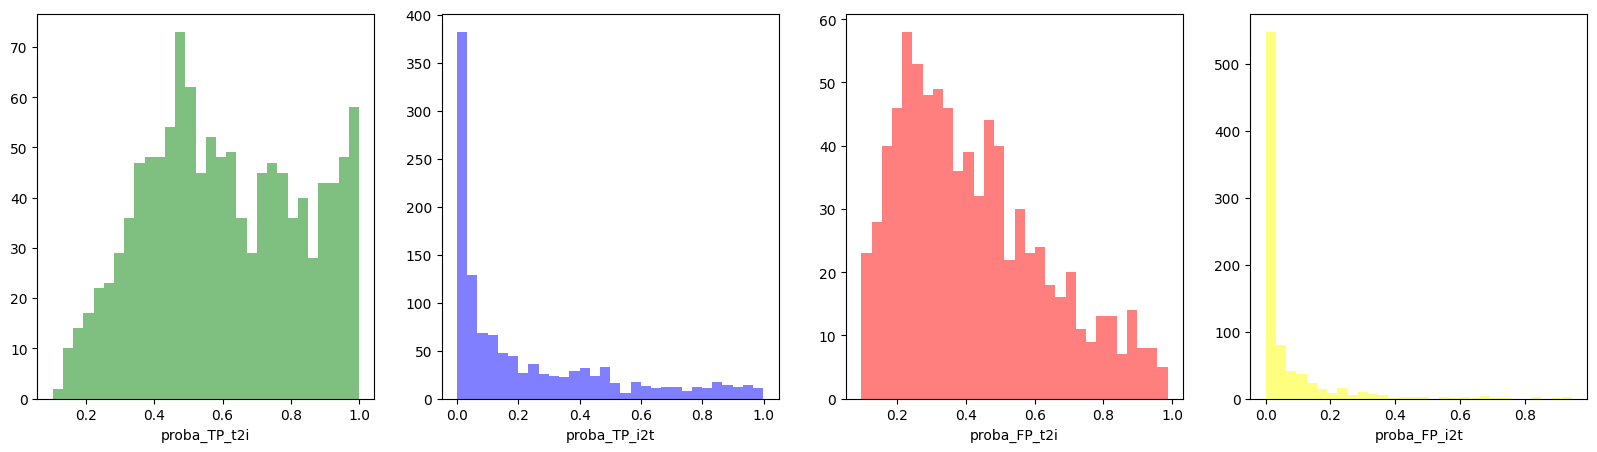

In [622]:
### plot uncertainty vs. TP/FP
TP_t2i = []
TP_i2t = []
FP_t2i = []
FP_i2t = []
for sample_idx, (sims_t2i, p_t2i, p_i2t) in enumerate(zip(sims_matrix_t2i, proba_top1_sim_list, proba_inversed_sim_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_t2i.append(p_t2i)
        TP_i2t.append(p_i2t)
    else:
        FP_t2i.append(p_t2i)
        FP_i2t.append(p_i2t)

print(f"TP_t2i.stats: len={len(TP_t2i)}, mean={np.mean(TP_t2i)}, max={np.max(TP_t2i)}, min={np.min(TP_t2i)}, std={ np.std(TP_t2i)}")
print(f"TP_i2t.stats: len={len(TP_i2t)}, mean={np.mean(TP_i2t)}, max={np.max(TP_i2t)}, min={np.min(TP_i2t)}, std={ np.std(TP_i2t)}")
print(f"FP_t2i.stats: len={len(FP_t2i)}, mean={np.mean(FP_t2i)}, max={np.max(FP_t2i)}, min={np.min(FP_t2i)}, std={ np.std(FP_t2i)}")
print(f"FP_i2t.stats: len={len(FP_i2t)}, mean={np.mean(FP_i2t)}, max={np.max(FP_i2t)}, min={np.min(FP_i2t)}, std={ np.std(FP_i2t)}")

plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
hist_info_TP_t2i = plt.hist(TP_t2i, bins=30, alpha=0.5, color='green')
plt.xlabel('proba_TP_t2i')
plt.subplot(1,4,2)
hist_info_TP_i2t = plt.hist(TP_i2t, bins=30, alpha=0.5, color='blue')
plt.xlabel('proba_TP_i2t')
plt.subplot(1,4,3)
hist_info_FP_t2i = plt.hist(FP_t2i, bins=30, alpha=0.5, color='red')
plt.xlabel('proba_FP_t2i')
plt.subplot(1,4,4)
hist_info_FP_i2t = plt.hist(FP_i2t, bins=30, alpha=0.5, color='yellow')
plt.xlabel('proba_FP_i2t')


#### Figure 2: uncertainty3

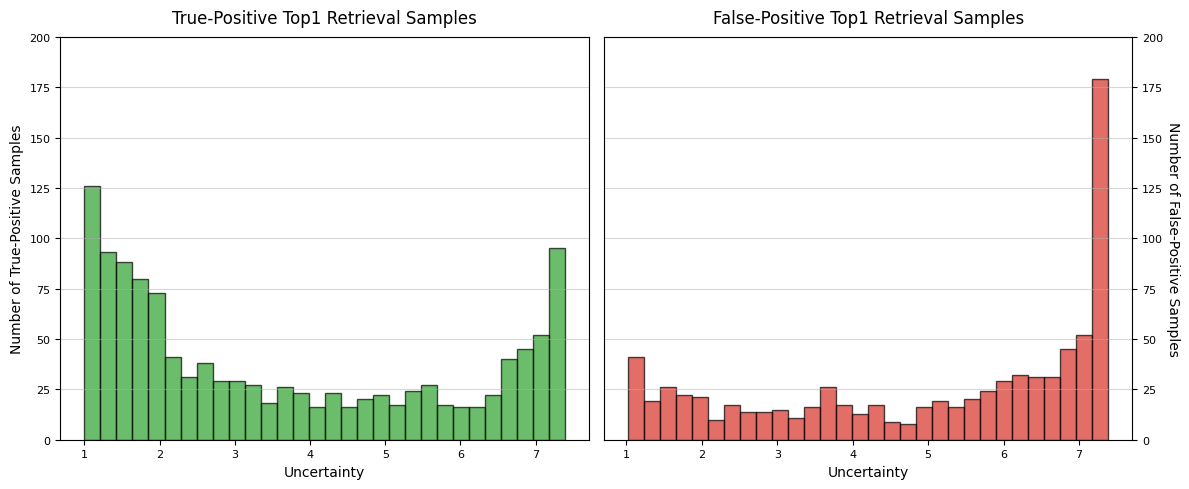

In [625]:
import matplotlib.pyplot as plt
import numpy as np

# 创建双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 真阳性子图
ax1.hist(TP_unc, bins=30, color='#2CA02C', edgecolor='black', alpha=0.7)
ax1.set_title('True-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax1.set_xlabel('Uncertainty', fontsize=10)
ax1.set_ylabel('Number of True-Positive Samples', fontsize=10)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(axis='y', alpha=0.5)
ax1.set_ylim(0, 200)

# 假阳性子图 - 关键修改在这里
ax2.hist(FP_unc, bins=30, color='#D73027', edgecolor='black', alpha=0.7)
ax2.set_title('False-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax2.set_xlabel('Uncertainty', fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.grid(axis='y', alpha=0.5)

# 将y轴标签放在右侧
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Number of False-Positive Samples', fontsize=10, rotation=270, labelpad=12)
ax2.yaxis.tick_right()  # 将y轴刻度也移到右侧
ax2.set_ylim(0, 200)

# 调整布局
plt.tight_layout()
plt.show()

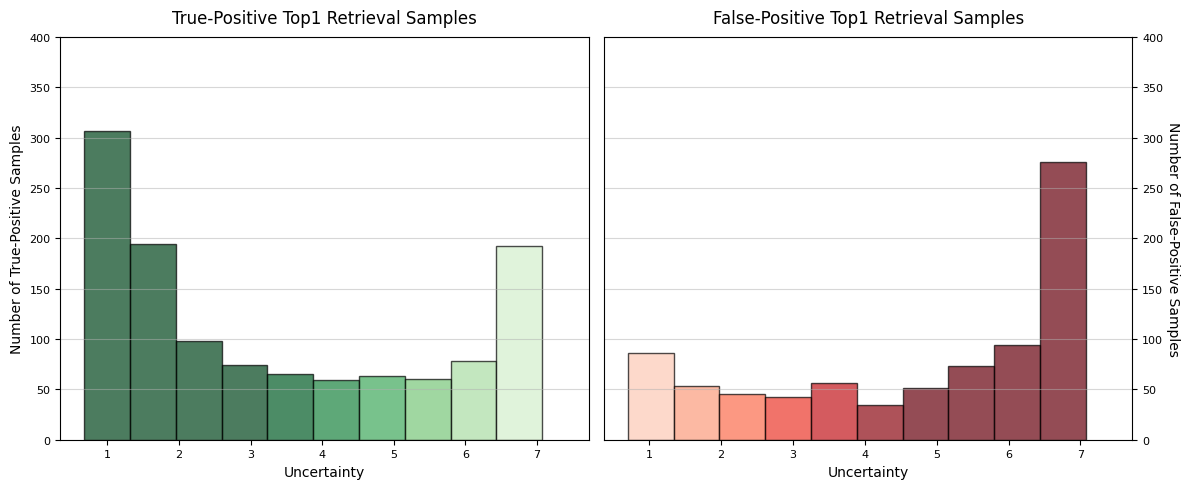

In [634]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 创建双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 真阳性子图 - 添加渐变色
# 先获取直方图数据但不显示
counts_t, bins_t, _ = ax1.hist(TP_unc, bins=10, alpha=0)
# 移除默认直方图，准备添加渐变色
for patch in ax1.patches:
    patch.remove()

# 创建绿色调渐变
colors_t = plt.cm.Greens(np.linspace(1.5, 0.2, len(counts_t)))
# 绘制渐变色直方图
for i in range(len(counts_t)):
    ax1.bar(bins_t[i], counts_t[i], width=bins_t[i+1]-bins_t[i],
            color=colors_t[i], edgecolor='black', alpha=0.7)

ax1.set_title('True-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax1.set_xlabel('Uncertainty', fontsize=10)
ax1.set_ylabel('Number of True-Positive Samples', fontsize=10)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(axis='y', alpha=0.5)
ax1.set_ylim(0, 400)

# 假阳性子图 - 添加渐变色
# 先获取直方图数据但不显示
counts_f, bins_f, _ = ax2.hist(FP_unc, bins=10, alpha=0)
# 移除默认直方图，准备添加渐变色
for patch in ax2.patches:
    patch.remove()

# 创建红色调渐变
colors_f = plt.cm.Reds(np.linspace(0.2, 1.5, len(counts_f)))
# 绘制渐变色直方图
for i in range(len(counts_f)):
    ax2.bar(bins_f[i], counts_f[i], width=bins_f[i+1]-bins_f[i],
            color=colors_f[i], edgecolor='black', alpha=0.7)

ax2.set_title('False-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax2.set_xlabel('Uncertainty', fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.grid(axis='y', alpha=0.5)

# 将y轴标签放在右侧
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Number of False-Positive Samples', fontsize=10, rotation=270, labelpad=12)
ax2.yaxis.tick_right()  # 将y轴刻度也移到右侧
ax2.set_ylim(0, 400)

# 调整布局
plt.tight_layout()
plt.show()

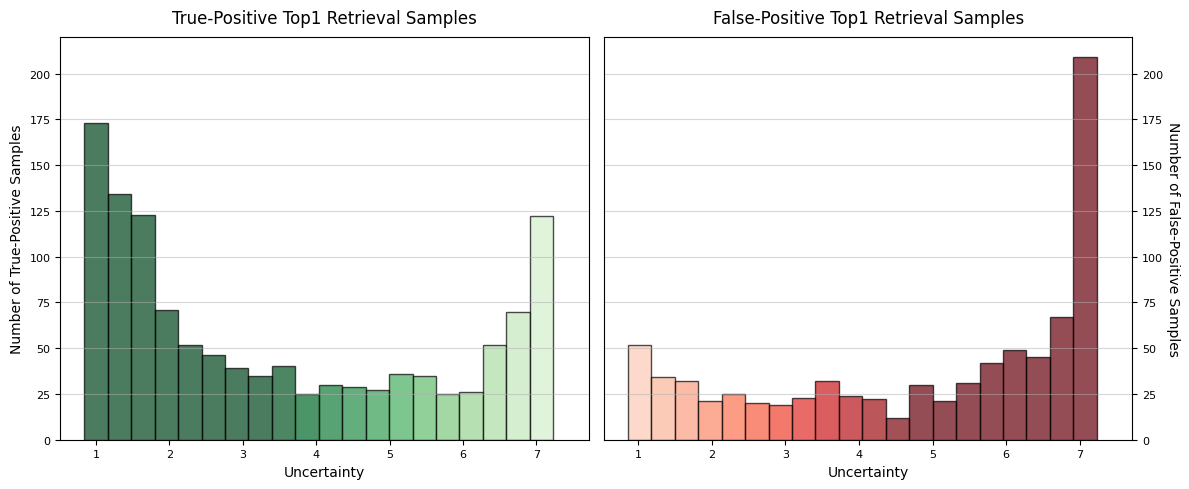

In [638]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 创建双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 真阳性子图 - 添加渐变色
# 先获取直方图数据但不显示
counts_t, bins_t, _ = ax1.hist(TP_unc, bins=20, alpha=0)
# 移除默认直方图，准备添加渐变色
for patch in ax1.patches:
    patch.remove()

# 创建绿色调渐变
colors_t = plt.cm.Greens(np.linspace(1.5, 0.2, len(counts_t)))
# 绘制渐变色直方图
for i in range(len(counts_t)):
    ax1.bar(bins_t[i], counts_t[i], width=bins_t[i+1]-bins_t[i],
            color=colors_t[i], edgecolor='black', alpha=0.7)

ax1.set_title('True-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax1.set_xlabel('Uncertainty', fontsize=10)
ax1.set_ylabel('Number of True-Positive Samples', fontsize=10)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(axis='y', alpha=0.5)
ax1.set_ylim(0, 220)

# 假阳性子图 - 添加渐变色
# 先获取直方图数据但不显示
counts_f, bins_f, _ = ax2.hist(FP_unc, bins=20, alpha=0)
# 移除默认直方图，准备添加渐变色
for patch in ax2.patches:
    patch.remove()

# 创建红色调渐变
colors_f = plt.cm.Reds(np.linspace(0.2, 1.5, len(counts_f)))
# 绘制渐变色直方图
for i in range(len(counts_f)):
    ax2.bar(bins_f[i], counts_f[i], width=bins_f[i+1]-bins_f[i],
            color=colors_f[i], edgecolor='black', alpha=0.7)

ax2.set_title('False-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax2.set_xlabel('Uncertainty', fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.grid(axis='y', alpha=0.5)

# 将y轴标签放在右侧
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Number of False-Positive Samples', fontsize=10, rotation=270, labelpad=12)
ax2.yaxis.tick_right()  # 将y轴刻度也移到右侧
ax2.set_ylim(0, 220)

# 调整布局
plt.tight_layout()
plt.show()

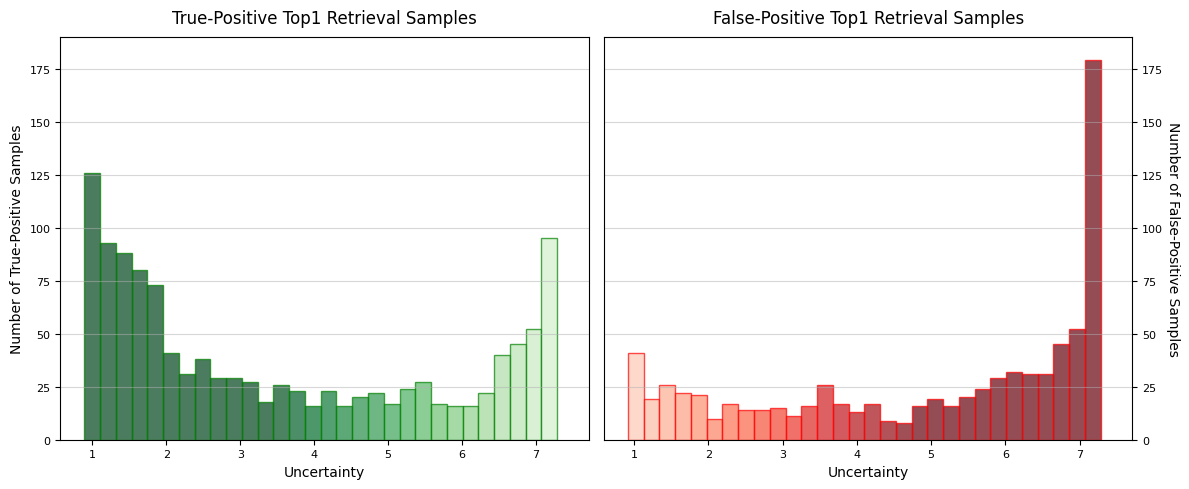

In [644]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 创建双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 真阳性子图 - 添加渐变色
# 先获取直方图数据但不显示
counts_t, bins_t, _ = ax1.hist(TP_unc, bins=30, alpha=0)
# 移除默认直方图，准备添加渐变色
for patch in ax1.patches:
    patch.remove()

# 创建绿色调渐变
colors_t = plt.cm.Greens(np.linspace(1.5, 0.2, len(counts_t)))
# 绘制渐变色直方图
for i in range(len(counts_t)):
    ax1.bar(bins_t[i], counts_t[i], width=bins_t[i+1]-bins_t[i],
            color=colors_t[i], edgecolor='green', alpha=0.7)

ax1.set_title('True-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax1.set_xlabel('Uncertainty', fontsize=10)
ax1.set_ylabel('Number of True-Positive Samples', fontsize=10)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.grid(axis='y', alpha=0.5)
ax1.set_ylim(0, 190)

# 假阳性子图 - 添加渐变色
# 先获取直方图数据但不显示
counts_f, bins_f, _ = ax2.hist(FP_unc, bins=30, alpha=0)
# 移除默认直方图，准备添加渐变色
for patch in ax2.patches:
    patch.remove()

# 创建红色调渐变
colors_f = plt.cm.Reds(np.linspace(0.2, 1.5, len(counts_f)))
# 绘制渐变色直方图
for i in range(len(counts_f)):
    ax2.bar(bins_f[i], counts_f[i], width=bins_f[i+1]-bins_f[i],
            color=colors_f[i], edgecolor='red', alpha=0.7)

ax2.set_title('False-Positive Top1 Retrieval Samples', fontsize=12, pad=10)
ax2.set_xlabel('Uncertainty', fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.grid(axis='y', alpha=0.5)

# 将y轴标签放在右侧
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Number of False-Positive Samples', fontsize=10, rotation=270, labelpad=12)
ax2.yaxis.tick_right()  # 将y轴刻度也移到右侧
ax2.set_ylim(0, 190)

# 调整布局
plt.tight_layout()
plt.show()

#### uncertainty10 & uncertainty3

TP_uncertainty.stats: len=1177, mean=4.127142906188965, max=7.389056205749512, min=1.0002310276031494, std=2.3026609420776367
FP_uncertainty.stats: len=823, mean=5.6732611656188965, max=7.389056205749512, min=1.0221872329711914, std=1.9135302305221558
TP_uncertainty.stats: len=1190, mean=3.634284734725952, max=7.389056205749512, min=1.0005723237991333, std=2.224104166030884
FP_uncertainty.stats: len=810, mean=5.078882217407227, max=7.389056205749512, min=1.0228452682495117, std=2.1565842628479004


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

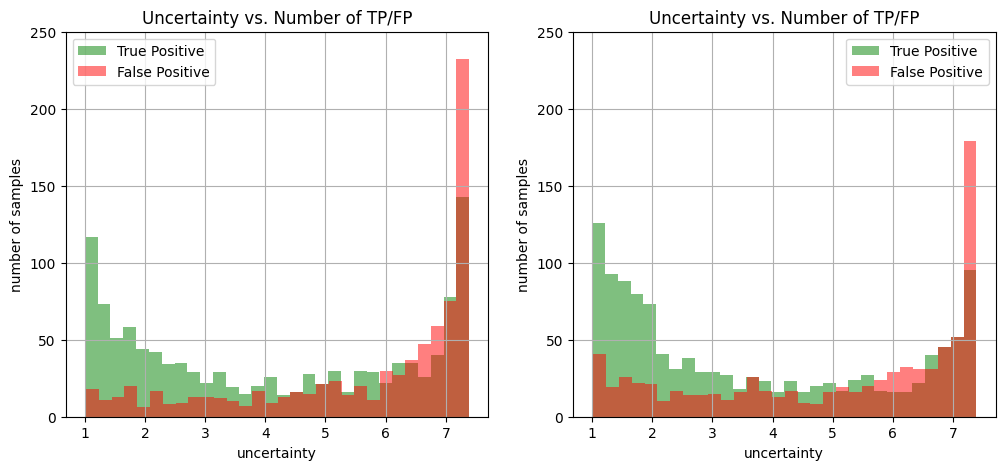

In [624]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty3_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.ylim(0,250)
plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')


### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i_norm, uncertainty10_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.subplot(1,2,2)
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.ylim(0,250)
plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty8 & uncertainty9

TP_uncertainty.stats: len=1177, mean=1.0375391244888306, max=1.3109970092773438, min=1.0006645917892456, std=0.030669625848531723
FP_uncertainty.stats: len=823, mean=1.020493984222412, max=1.128139615058899, min=1.0010319948196411, std=0.014690432697534561
TP_uncertainty.stats: len=1177, mean=1.0774281024932861, max=1.7187131643295288, min=1.0013296604156494, std=0.06638431549072266
FP_uncertainty.stats: len=823, mean=1.0416239500045776, max=1.272698998451233, min=1.0020650625228882, std=0.030475931242108345


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

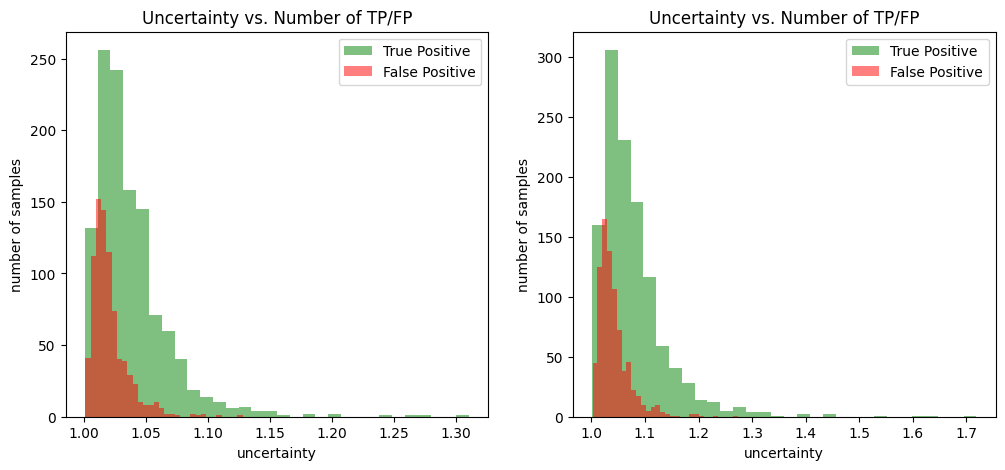

In [601]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty8_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')


### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty9_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.subplot(1,2,2)
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty9_list

TP_uncertainty.stats: len=1177, mean=5.805878639221191, max=39.691776275634766, min=1.0000404119491577, std=5.398815631866455
FP_uncertainty.stats: len=823, mean=5.158458709716797, max=39.91366195678711, min=1.0104326009750366, std=5.180621147155762


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

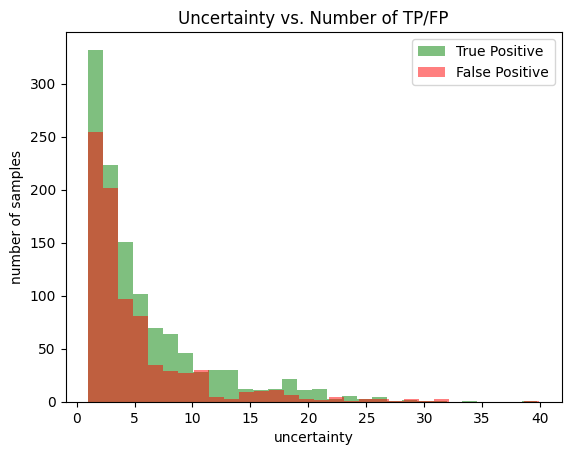

In [534]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty9_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_1

TP_uncertainty.stats: len=1177, mean=1.9072736501693726, max=2.571242332458496, min=1.0528303384780884, std=0.27635446190834045
FP_uncertainty.stats: len=823, mean=2.1748313903808594, max=2.581298351287842, min=1.3223704099655151, std=0.2413097321987152


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

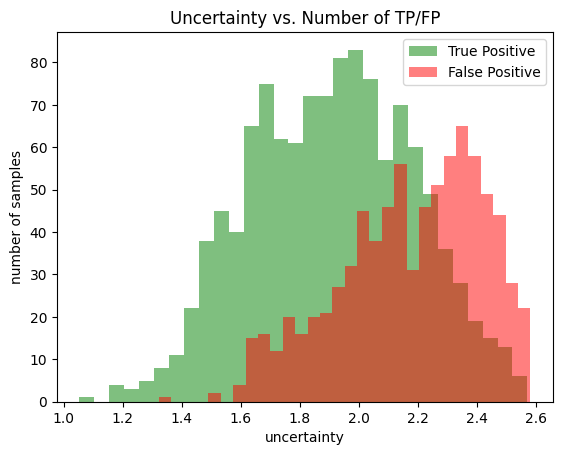

In [535]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertaintys_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

TP_uncertainty.stats: len=1177, mean=1.27001994769671e-05, max=0.014545237645506859, min=2.842729307159231e-13, std=0.00042378390207886696
FP_uncertainty.stats: len=823, mean=6.594001752091572e-05, max=0.02676590345799923, min=7.8339253486992e-12, std=0.0011598326964303851


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

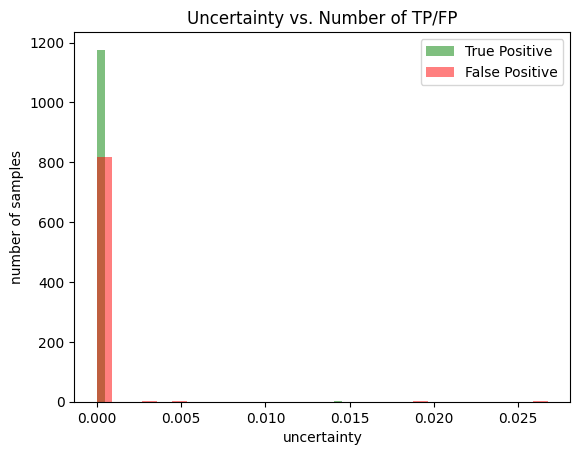

In [536]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, cos_uncertaintys_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_2

TP_uncertainty.stats: len=1177, mean=1.6518596410751343, max=2.5992431640625, min=1.0031847953796387, std=0.3471877872943878
FP_uncertainty.stats: len=823, mean=1.4959763288497925, max=2.5497944355010986, min=1.0370746850967407, std=0.31727075576782227


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

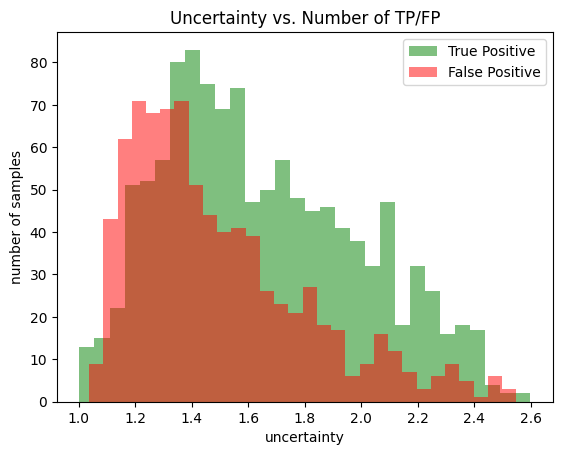

In [537]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty2_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

TP_uncertainty.stats: len=1177, mean=30.67279052734375, max=34925.875, min=1.0, std=1017.5648803710938
FP_uncertainty.stats: len=823, mean=1385.1494140625, max=793956.9375, min=1.0, std=29745.5625


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

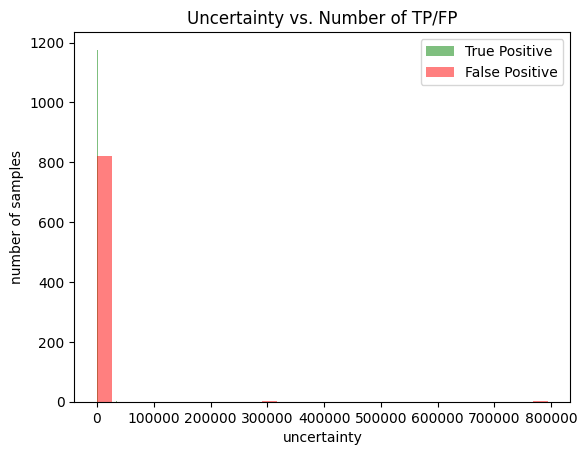

In [538]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, cos_uncertainty2_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_3

TP_uncertainty.stats: len=1177, mean=4.127142906188965, max=7.389056205749512, min=1.0002310276031494, std=2.3026609420776367
FP_uncertainty.stats: len=823, mean=5.6732611656188965, max=7.389056205749512, min=1.0221872329711914, std=1.9135302305221558


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

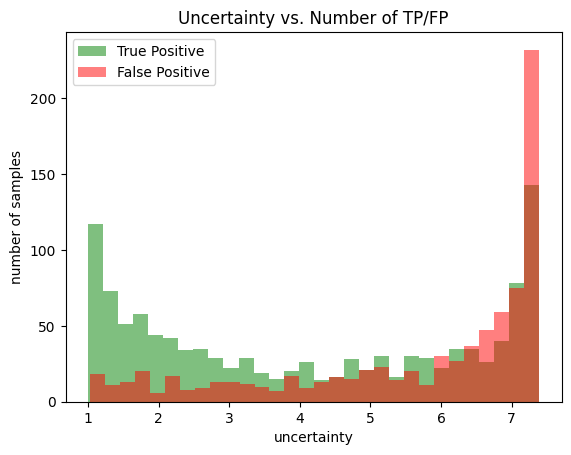

In [607]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty3_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

TP_uncertainty.stats: len=1177, mean=1.0054281949996948, max=7.389056205749512, min=1.0, std=0.18615037202835083
FP_uncertainty.stats: len=823, mean=1.0310524702072144, max=7.389056205749512, min=1.0, std=0.4443332552909851


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

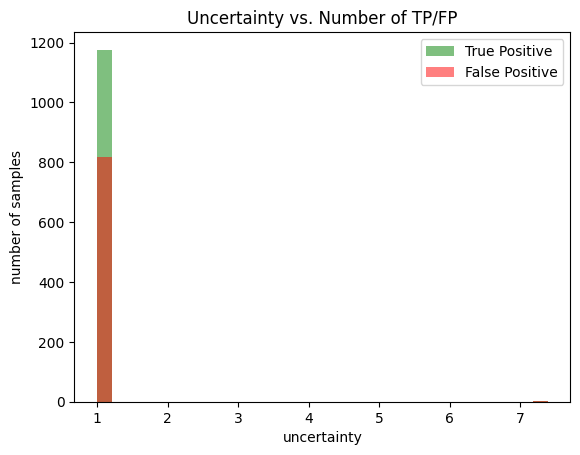

In [518]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, cos_uncertainty3_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_4

TP_uncertainty.stats: len=1177, mean=1.8421862125396729, max=4.148435115814209, min=0.006227552890777588, std=0.8405579924583435
FP_uncertainty.stats: len=823, mean=2.3833303451538086, max=4.249977111816406, min=0.13739168643951416, std=0.740513265132904


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

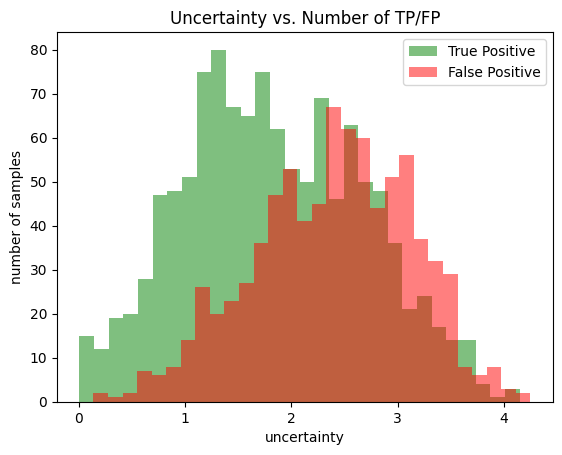

In [540]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty4_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

TP_uncertainty.stats: len=1177, mean=0.0059080529026687145, max=6.953778266906738, min=0.0, std=0.2026039958000183
FP_uncertainty.stats: len=823, mean=0.03413165360689163, max=7.214856147766113, min=0.0, std=0.4885216951370239


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

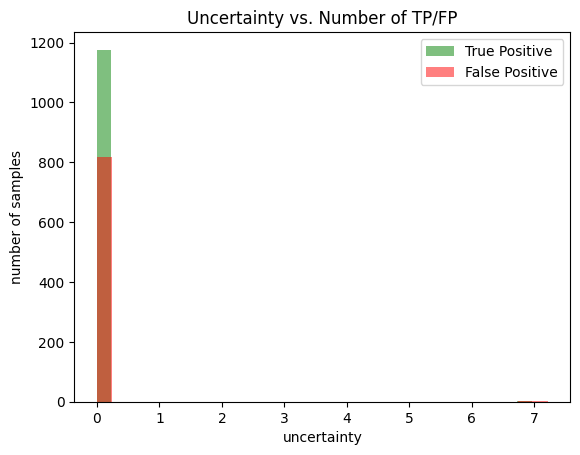

In [520]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, cos_uncertainty4_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_5

TP_uncertainty.stats: len=1177, mean=4.916728496551514, max=7.389056205749512, min=1.000303864479065, std=2.041299819946289
FP_uncertainty.stats: len=823, mean=6.215691089630127, max=7.389056205749512, min=1.08564293384552, std=1.5370314121246338


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

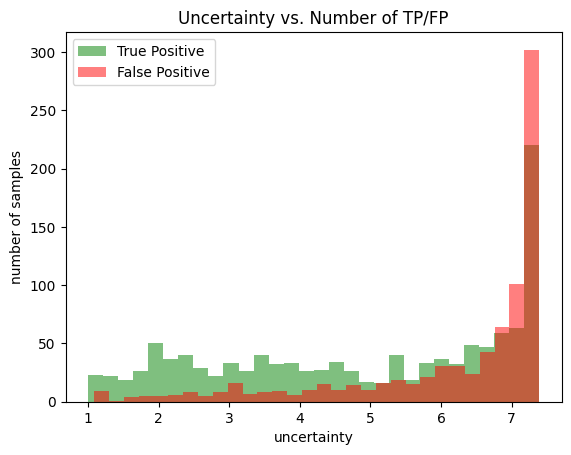

In [521]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty5_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_6

TP_uncertainty.stats: len=1177, mean=0.8895881772041321, max=1.020201325416565, min=0.37619489431381226, std=0.1598927080631256
FP_uncertainty.stats: len=823, mean=0.9904181361198425, max=1.020201325416565, min=0.4083513617515564, std=0.06482499837875366


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

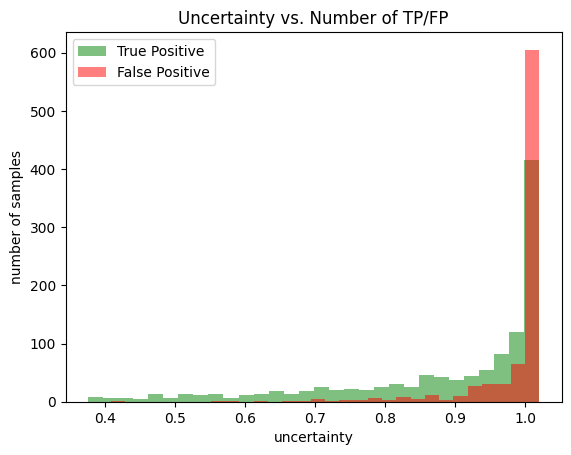

In [522]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty6_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_7

TP_uncertainty.stats: len=1177, mean=21.88754653930664, max=6409.7431640625, min=1.0001156330108643, std=219.4728546142578
FP_uncertainty.stats: len=823, mean=204.57009887695312, max=22131.32421875, min=1.0114061832427979, std=1391.48681640625


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

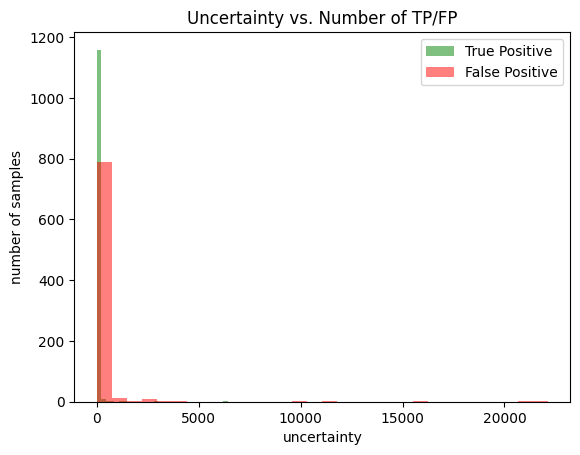

In [523]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty7_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty8_list

TP_uncertainty.stats: len=1177, mean=2.091592311859131, max=6.964511871337891, min=1.0, std=1.1623955965042114
FP_uncertainty.stats: len=823, mean=2.073887825012207, max=6.570306777954102, min=1.000392198562622, std=0.9809006452560425


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

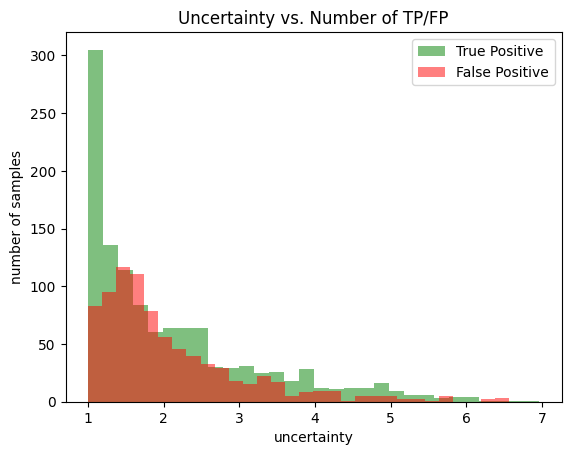

In [550]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty8_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

### New Uncertainty Design - sigmoid(cos_sim_norm) - 没效果

In [481]:
def compute_uncertainty_sigmoid_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_i2t, sigmoid_temper=1.0, uncertainty_temper=1.0, uncertainty_t2i_temper=1.0, uncertainty_i2t_temper=1.0, k_test = 128):
    uncertaintys_list = []
    uncertainty2_list = []
    uncertainty3_list = []
    uncertainty4_list = []
    uncertainty5_list = []
    uncertainty6_list = []
    uncertainty7_list = []
    uncertainty8_list = []
    uncertainty9_list = []
    uncertainty10_list = []
    uncertainty11_list = []

    proba_top1_sim_list = []
    proba_inversed_sim_list = []

    for i, sims_t2i in enumerate(sims_matrix_t2i):

        topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
        # proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0]# i2t和t2i的logtis rank/distribution呈现长尾or平均的现象
        proba_top1_sim_t2i = ( torch.sigmoid(  ( topk_sim_t2i - topk_sim_t2i.mean() )  * sigmoid_temper ) )[0]

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            # proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]
            proba_inversed_sim_i2t_top1_idx_t2i = ( torch.sigmoid( ( topk_sim_i2t_top1_idx_t2i - topk_sim_i2t_top1_idx_t2i.mean() )  * sigmoid_temper ) )[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        # uncertainty3 = torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )
        uncertainty5 = torch.exp( torch.abs(proba_top1_sim_t2i*N_t2i - proba_inversed_sim_i2t_top1_idx_t2i*N_i2t) / ((proba_top1_sim_t2i*N_t2i + proba_inversed_sim_i2t_top1_idx_t2i*N_i2t)/2) * uncertainty_temper )
        uncertainty6 = torch.exp( (1/ (N_t2i*N_i2t) - (proba_top1_sim_t2i*proba_inversed_sim_i2t_top1_idx_t2i )) * uncertainty_temper )
        uncertainty7 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper  * 1/torch.max(proba_top1_sim_t2i, proba_inversed_sim_i2t_top1_idx_t2i))
        uncertainty8 = torch.exp( (proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i)**2 /((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty9 = torch.exp( 2* (proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i)**2 /((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) )
        uncertainty10 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i*2) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i*2)/2) * uncertainty_temper )
        uncertainty11 = (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper

        uncertaintys_list.append(uncertainty)
        uncertainty2_list.append(uncertainty2)
        uncertainty3_list.append(uncertainty3)
        uncertainty4_list.append(uncertainty4)
        uncertainty5_list.append(uncertainty5)
        uncertainty6_list.append(uncertainty6)
        uncertainty7_list.append(uncertainty7)
        uncertainty8_list.append(uncertainty8)
        uncertainty9_list.append(uncertainty9)
        uncertainty10_list.append(uncertainty10)
        uncertainty11_list.append(uncertainty11)

        proba_top1_sim_list.append(proba_top1_sim_t2i)
        proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)
    return [uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list, uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list, uncertainty11_list ], proba_top1_sim_list, proba_inversed_sim_list

In [482]:
ham_rstp_tta_embeds_dict = {}
ham_rstp_tta_embeds_dict["sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["uncertaintys_list"] = np.load('debug_embeddings/ham_rstp_tta/uncertaintys_list.npy')
ham_rstp_tta_embeds_dict["ss_idxs_list"] = np.load('debug_embeddings/ham_rstp_tta/ss_idxs_list.npy')
ham_rstp_tta_embeds_dict["sampled_sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_idx_t2i.npy')
ham_rstp_tta_embeds_dict["qids"] = np.load('debug_embeddings/ham_rstp_tta/qids.npy')
ham_rstp_tta_embeds_dict["gids"] = np.load('debug_embeddings/ham_rstp_tta/gids.npy')
ham_rstp_tta_embeds_dict["qfeats"] = np.load('debug_embeddings/ham_rstp_tta/qfeats.npy')
ham_rstp_tta_embeds_dict["gfeats"] = np.load('debug_embeddings/ham_rstp_tta/gfeats.npy')

In [483]:
selected_idx = [i for i in range(2000) if i not in [416,  883, 1113,  622, 1837,  916]]

In [484]:
### hyper-parameters of uncertainty
sigmoid_temper = 5
uncertainty_temper = 10
uncertainty_t2i_temper = 1
uncertainty_i2t_temper = 1
k_test = 128
N_t2i = 1#10
N_i2t = 1#5

### get query & gallery features
qfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"])
gfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"])
qfeats_norm = F.normalize(qfeats, p=2, dim=1)
gfeats_norm = F.normalize(gfeats, p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
### get cos_sims_matrix
sims_matrix_t2i = torch.from_numpy(ham_rstp_tta_embeds_dict["sims_matrix_t2i"])
### get labels
gids = torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
qids = torch.from_numpy(ham_rstp_tta_embeds_dict["qids"])

### selected_idx
# sims_matrix_t2i_norm = torch.gather(sims_matrix_t2i_norm,index=np.array(selected_idx),dim=1,)
# sims_matrix_t2i = torch.gather(sims_matrix_t2i,index=np.array(selected_idx),dim=1,)
# gids = torch.gather(gids,index=np.array(selected_idx),dim=1,)
# qids = torch.gather(qids,index=np.array(selected_idx),dim=1,)

### compute uncertainty
uncertainty_list_list, proba_top1_sim_list, proba_inversed_sim_list = compute_uncertainty_sigmoid_itc(N_t2i, N_i2t, sims_matrix_t2i_norm, sims_matrix_t2i_norm.t(), sigmoid_temper, uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)
# uncertainty_list_list = [uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list,uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list]

for i in range(len(uncertainty_list_list)):
    print(f"len(uncertainty_list_list[{i}]) = {len(uncertainty_list_list[i])}")
    print(uncertainty_list_list[i][:10])

len(uncertainty_list_list[0]) = 2000
[tensor(41.1181), tensor(68.0249), tensor(79.9283), tensor(71.0543), tensor(50.3333), tensor(19.1558), tensor(12.8423), tensor(8.2329), tensor(29.8174), tensor(34.3057)]
len(uncertainty_list_list[1]) = 2000
[tensor(6.3163), tensor(10.3244), tensor(9.8250), tensor(6.4764), tensor(7.3779), tensor(1.0186), tensor(2.2506), tensor(1.0442), tensor(1.8208), tensor(4.4168)]
len(uncertainty_list_list[2]) = 2000
[tensor(18.7892), tensor(56.7611), tensor(58.3542), tensor(25.9607), tensor(26.7426), tensor(1.0265), tensor(2.9721), tensor(1.0563), tensor(2.4776), tensor(9.9518)]
len(uncertainty_list_list[3]) = 2000
[tensor(0.2908), tensor(0.4024), tensor(0.4050), tensor(0.3229), tensor(0.3262), tensor(0.0026), tensor(0.1076), tensor(0.0054), tensor(0.0894), tensor(0.2272)]
len(uncertainty_list_list[4]) = 2000
[tensor(18.7892), tensor(56.7611), tensor(58.3542), tensor(25.9607), tensor(26.7426), tensor(1.0265), tensor(2.9721), tensor(1.0563), tensor(2.4776), tensor

#### proba_TP/FP_t2i/i2t

TP_t2i.stats: len=1189, mean=0.7546358704566956, max=0.9128005504608154, min=0.6219781637191772, std=0.04660265892744064
TP_i2t.stats: len=1189, mean=0.6969189047813416, max=0.8613442182540894, min=0.4580041468143463, std=0.06902288645505905
FP_t2i.stats: len=805, mean=0.7092335224151611, max=0.8277276158332825, min=0.6116636395454407, std=0.03977171704173088
FP_i2t.stats: len=805, mean=0.6140938997268677, max=0.8028857111930847, min=0.44391751289367676, std=0.0695338323712349


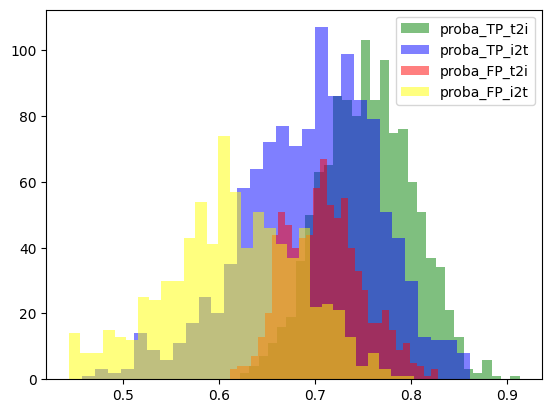

In [485]:
### plot uncertainty vs. TP/FP
TP_t2i = []
TP_i2t = []
FP_t2i = []
FP_i2t = []
for sample_idx, (sims_t2i, p_t2i, p_i2t) in enumerate(zip(sims_matrix_t2i_norm, proba_top1_sim_list, proba_inversed_sim_list)):
    if sample_idx not in selected_idx:
        continue
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_t2i.append(p_t2i)
        TP_i2t.append(p_i2t)
    else:
        FP_t2i.append(p_t2i)
        FP_i2t.append(p_i2t)

print(f"TP_t2i.stats: len={len(TP_t2i)}, mean={np.mean(TP_t2i)}, max={np.max(TP_t2i)}, min={np.min(TP_t2i)}, std={ np.std(TP_t2i)}")
print(f"TP_i2t.stats: len={len(TP_i2t)}, mean={np.mean(TP_i2t)}, max={np.max(TP_i2t)}, min={np.min(TP_i2t)}, std={ np.std(TP_i2t)}")
print(f"FP_t2i.stats: len={len(FP_t2i)}, mean={np.mean(FP_t2i)}, max={np.max(FP_t2i)}, min={np.min(FP_t2i)}, std={ np.std(FP_t2i)}")
print(f"FP_i2t.stats: len={len(FP_i2t)}, mean={np.mean(FP_i2t)}, max={np.max(FP_i2t)}, min={np.min(FP_i2t)}, std={ np.std(FP_i2t)}")

# plt.figure(figsize=(20,5))
# plt.subplot(1,4,1)
hist_info_TP_t2i = plt.hist(TP_t2i, bins=30, alpha=0.5, color='green')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_TP_t2i')
# plt.subplot(1,4,2)
hist_info_TP_i2t = plt.hist(TP_i2t, bins=30, alpha=0.5, color='blue')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_TP_i2t')
# plt.subplot(1,4,3)
hist_info_FP_t2i = plt.hist(FP_t2i, bins=30, alpha=0.5, color='red')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_FP_t2i')
# plt.subplot(1,4,4)
hist_info_FP_i2t = plt.hist(FP_i2t, bins=30, alpha=0.5, color='yellow')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_FP_i2t')
plt.legend(['proba_TP_t2i','proba_TP_i2t','proba_FP_t2i','proba_FP_i2t'])

# softmax
# TP_t2i.stats: len=1177, mean=0.6046417355537415, max=0.9992173910140991, min=0.10303782671689987, std=0.22568917274475098
# TP_i2t.stats: len=1177, mean=0.22667689621448517, max=0.9989386200904846, min=0.0, std=0.2693672776222229
# FP_t2i.stats: len=823, mean=0.42058852314949036, max=0.986547589302063, min=0.09628188610076904, std=0.21028649806976318
# FP_i2t.stats: len=823, mean=0.06218677759170532, max=0.9464418888092041, min=0.0, std=0.12816931307315826

# sigmoid
### plot uncertainty vs. TP/FP
TP_t2i = []
TP_i2t = []
FP_t2i = []
FP_i2t = []
for sample_idx, (sims_t2i, p_t2i, p_i2t) in enumerate(zip(sims_matrix_t2i_norm, proba_top1_sim_list, proba_inversed_sim_list)):
    if sample_idx not in selected_idx:
        continue
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_t2i.append(p_t2i)
        TP_i2t.append(p_i2t)
    else:
        FP_t2i.append(p_t2i)
        FP_i2t.append(p_i2t)

print(f"TP_t2i.stats: len={len(TP_t2i)}, mean={np.mean(TP_t2i)}, max={np.max(TP_t2i)}, min={np.min(TP_t2i)}, std={ np.std(TP_t2i)}")
print(f"TP_i2t.stats: len={len(TP_i2t)}, mean={np.mean(TP_i2t)}, max={np.max(TP_i2t)}, min={np.min(TP_i2t)}, std={ np.std(TP_i2t)}")
print(f"FP_t2i.stats: len={len(FP_t2i)}, mean={np.mean(FP_t2i)}, max={np.max(FP_t2i)}, min={np.min(FP_t2i)}, std={ np.std(FP_t2i)}")
print(f"FP_i2t.stats: len={len(FP_i2t)}, mean={np.mean(FP_i2t)}, max={np.max(FP_i2t)}, min={np.min(FP_i2t)}, std={ np.std(FP_i2t)}")

# plt.figure(figsize=(20,5))
# plt.subplot(1,4,1)
hist_info_TP_t2i = plt.hist(TP_t2i, bins=30, alpha=0.5, color='green')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_TP_t2i')
# plt.subplot(1,4,2)
hist_info_TP_i2t = plt.hist(TP_i2t, bins=30, alpha=0.5, color='blue')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_TP_i2t')
# plt.subplot(1,4,3)
hist_info_FP_t2i = plt.hist(FP_t2i, bins=30, alpha=0.5, color='red')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_FP_t2i')
# plt.subplot(1,4,4)
hist_info_FP_i2t = plt.hist(FP_i2t, bins=30, alpha=0.5, color='yellow')
# plt.xlim(0,1)
# plt.ylim(0,120)
# plt.xlabel('proba_FP_i2t')
plt.legend(['proba_TP_t2i','proba_TP_i2t','proba_FP_t2i','proba_FP_i2t'])

# softmax
# TP_t2i.stats: len=1177, mean=0.6046417355537415, max=0.9992173910140991, min=0.10303782671689987, std=0.22568917274475098
# TP_i2t.stats: len=1177, mean=0.22667689621448517, max=0.9989386200904846, min=0.0, std=0.2693672776222229
# FP_t2i.stats: len=823, mean=0.42058852314949036, max=0.986547589302063, min=0.09628188610076904, std=0.21028649806976318
# FP_i2t.stats: len=823, mean=0.06218677759170532, max=0.9464418888092041, min=0.0, std=0.12816931307315826

# sigmoid
# TP_t2i.stats: len=1189, mean=0.7546358704566956, max=0.9128005504608154, min=0.6219781637191772, std=0.04660265892744064
# TP_i2t.stats: len=1189, mean=0.6969189047813416, max=0.8613442182540894, min=0.4580041468143463, std=0.06902288645505905
# FP_t2i.stats: len=805, mean=0.7092335224151611, max=0.8277276158332825, min=0.6116636395454407, std=0.03977171704173088
# FP_i2t.stats: len=805, mean=0.6140938997268677, max=0.8028857111930847, min=0.44391751289367676, std=0.0695338323712349

#### 对比softmax(cos_sim)的uncertainty

In [516]:
print('softmax stats.mean : ')
print(np.exp((0.6046417355537415 - 0.22667689621448517) / ((0.6046417355537415 + 0.22667689621448517)/2)))
print(np.exp((0.42058852314949036 - 0.06218677759170532) / ((0.42058852314949036  + 0.06218677759170532)/2)))

print('sigmoid stats.mean : ')
print(np.exp((0.7545658349990845 - 0.6963332891464233) / ((0.7545658349990845 + 0.6963332891464233)/2))) #sigmoid
print(np.exp((0.7088374495506287 - 0.6103031039237976) / ((0.7088374495506287  + 0.6103031039237976)/2)))

softmax stats.mean : 
2.4826188974879675
4.413887988071487
sigmoid stats.mean : 
1.0835806544369768
1.1611277503393265


In [497]:
print('stats.max : ')
print(np.exp((0.9128005504608154 - 0.8613442182540894) / ((0.9128005504608154 + 0.8613442182540894)/2))) #sigmoid（5*）
print(np.exp((0.8277276158332825 - 0.8028857111930847) / ((0.8277276158332825  + 0.8028857111930847)/2)))

print('stats.mean : ')
print(np.exp((0.7545658349990845 - 0.6963332891464233) / ((0.7545658349990845 + 0.6963332891464233)/2))) #sigmoid(2*)
print(np.exp((0.7088374495506287 - 0.6103031039237976) / ((0.7088374495506287  + 0.6103031039237976)/2)))

print('stats.min : ')
print(np.exp((0.6219781637191772 - 0.4580041468143463) / ((0.6219781637191772 + 0.4580041468143463)/2))) #softmax tp t2i i2t
print(np.exp((0.6116636395454407 - 0.44391751289367676) / ((0.6116636395454407  + 0.44391751289367676)/2))) #softmax fp t2i i2t

stats.max : 
1.0597223234359952
1.0309383425834215
stats.mean : 
1.0835806544369768
1.1611277503393265
stats.min : 
1.354809102385555
1.3741385958887322


1189 805


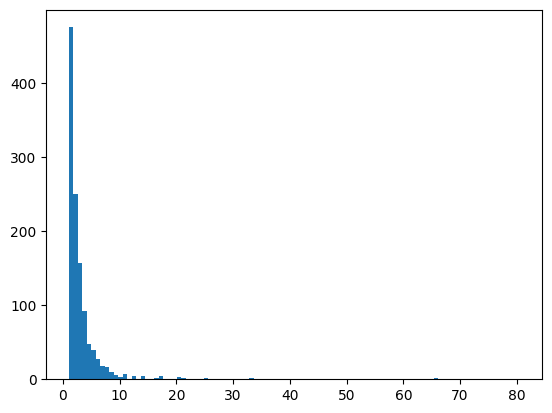

In [498]:
tp_unc = []
for idx, (p_t2i, p_i2t) in enumerate(zip(TP_t2i, TP_i2t)):
    unc = torch.exp( 10 * torch.abs(p_t2i-p_i2t) / ((p_t2i+p_i2t)/2) )
    tp_unc.append(unc)

fp_unc = []
for idx, (p_t2i, p_i2t) in enumerate(zip(FP_t2i, FP_i2t)):
    unc = torch.exp( 10 * torch.abs(p_t2i-p_i2t) / ((p_t2i+p_i2t)/2) )
    fp_unc.append(unc)

print(len(tp_unc), len(fp_unc))


# hist_info_FP_t2i = plt.hist(FP_t2i, bins=30, alpha=0.5, color='red')
tp_unc_hist = plt.hist(tp_unc,bins=100)

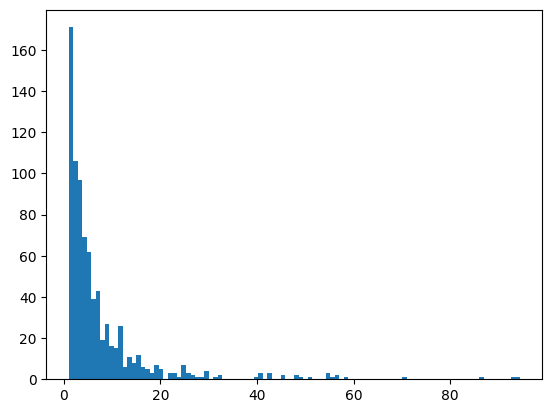

In [499]:
fp_unc_hist = plt.hist(fp_unc, bins=100)

In [500]:
print(((0.7088374495506287 - 0.6103031039237976) / ((0.7088374495506287  + 0.6103031039237976)/2))   /   ((0.7545658349990845 - 0.6963332891464233) / ((0.7545658349990845 + 0.6963332891464233)/2)))

1.8610927023733599


In [501]:
print((0.6046417355537415 - 0.22667689621448517) / ((0.6046417355537415  + 0.22667689621448517)/2))
print((0.42058852314949036 - 0.06218677759170532) / ((0.42058852314949036  + 0.06218677759170532)/2))


print(   ((0.42058852314949036 - 0.06218677759170532) / ((0.42058852314949036  + 0.06218677759170532)/2)) /((0.6046417355537415 - 0.22667689621448517) / ((0.6046417355537415  + 0.22667689621448517)/2))   )

0.9093140100452691
1.4847559309995257
1.63283080937641


In [502]:
# TP_t2i.stats: len=1177, mean=0.6046417355537415, max=0.9992173910140991, min=0.10303782671689987, std=0.22568917274475098
# TP_i2t.stats: len=1177, mean=0.22667689621448517, max=0.9989386200904846, min=0.0, std=0.2693672776222229
# FP_t2i.stats: len=823, mean=0.42058852314949036, max=0.986547589302063, min=0.09628188610076904, std=0.21028649806976318
# FP_i2t.stats: len=823, mean=0.06218677759170532, max=0.9464418888092041, min=0.0, std=0.12816931307315826

In [503]:
TF_labels = []
for sample_idx, sims_t2i in enumerate(sims_matrix_t2i_norm):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TF_labels.append(True)
    else:
        TF_labels.append(False)

print(np.sum(TF_labels))

1190


In [504]:
for idx, (tf_label, unc, p1, p2) in enumerate(zip(TF_labels, uncertainty_list_list[2], proba_top1_sim_list, proba_inversed_sim_list)):
    print('idx : ',idx)
    print('is true positive ? :',tf_label)
    print("uncertainty, p_t2i, p_i2t : ", unc,p1,p2)
    print("uncertainty手动计算 : ",  torch.exp( torch.abs(p1-p2) / ((p1+p2)/2)*10 )  )
    print()
    if idx==10: break

idx :  0
is true positive ? : False
uncertainty, p_t2i, p_i2t :  tensor(18.7892) tensor(0.7205) tensor(0.5362)
uncertainty手动计算 :  tensor(18.7892)

idx :  1
is true positive ? : False
uncertainty, p_t2i, p_i2t :  tensor(56.7611) tensor(0.6947) tensor(0.4613)
uncertainty手动计算 :  tensor(56.7611)

idx :  2
is true positive ? : False
uncertainty, p_t2i, p_i2t :  tensor(58.3542) tensor(0.6761) tensor(0.4476)
uncertainty手动计算 :  tensor(58.3542)

idx :  3
is true positive ? : False
uncertainty, p_t2i, p_i2t :  tensor(25.9607) tensor(0.6671) tensor(0.4802)
uncertainty手动计算 :  tensor(25.9607)

idx :  4
is true positive ? : False
uncertainty, p_t2i, p_i2t :  tensor(26.7426) tensor(0.7081) tensor(0.5082)
uncertainty手动计算 :  tensor(26.7426)

idx :  5
is true positive ? : False
uncertainty, p_t2i, p_i2t :  tensor(1.0265) tensor(0.7038) tensor(0.7057)
uncertainty手动计算 :  tensor(1.0265)

idx :  6
is true positive ? : True
uncertainty, p_t2i, p_i2t :  tensor(2.9721) tensor(0.7853) tensor(0.7042)
uncertainty

TP_uncertainty.stats: len=1190, mean=407705.3125, max=485165184.0, min=1.0003094673156738, std=14058325.0
FP_uncertainty.stats: len=810, mean=2994854.25, max=485165184.0, min=1.0103665590286255, std=38000344.0


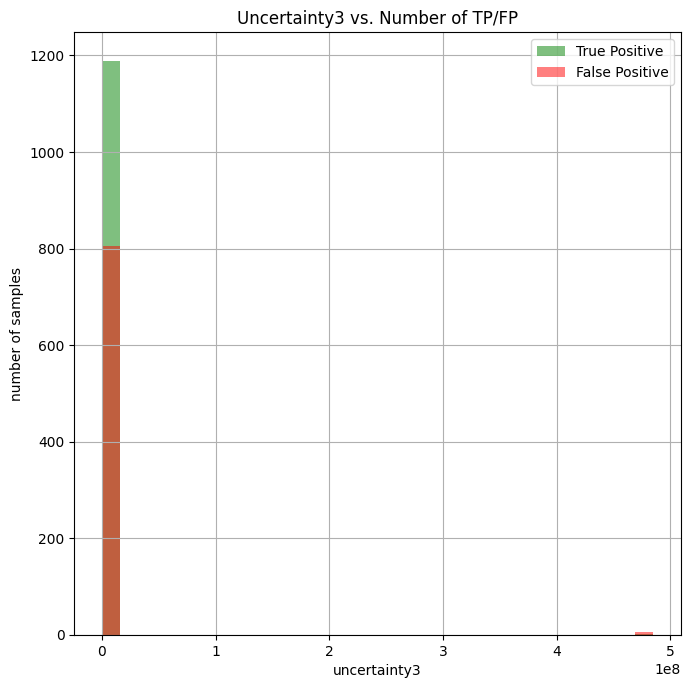

In [505]:
### plot uncertainty vs. TP/FP
plt.figure(figsize=(36,36))

# for i in range(len(uncertainty_list_list)):
i=2
if 1:
    uncertainty_list = uncertainty_list_list[i]

    TP_unc = []
    FP_unc = []
    for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i_norm, uncertainty_list)):
        sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
        if gids[idx_topk[0].numpy()] == qids[sample_idx]:
            TP_unc.append(unc)
        else:
            FP_unc.append(unc)

    print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
    print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

    plt.subplot(4,4,i+1)
    hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
    hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
    # plt.xlim(1,2)
    plt.grid(True)
    plt.legend(['True Positive', 'False Positive'])
    plt.xlabel(f'uncertainty{i+1}')
    plt.ylabel('number of samples')
    plt.title(f'Uncertainty{i+1} vs. Number of TP/FP')

In [506]:
torch.from_numpy(np.array(uncertainty_list)).topk(k=10)


torch.return_types.topk(
values=tensor([4.8517e+08, 4.8517e+08, 4.8517e+08, 4.8517e+08, 4.8517e+08, 4.8517e+08,
        9.4367e+01, 9.3093e+01, 8.6422e+01, 8.0478e+01]),
indices=tensor([ 416,  883, 1113,  622, 1837,  916,  758, 1373,  294, 1830]))

(array([1994.,    0.,    0.,    0.,    6.]),
 array([1.00030947e+00, 9.70330400e+07, 1.94066080e+08, 2.91099136e+08,
        3.88132160e+08, 4.85165184e+08]),
 <BarContainer object of 5 artists>)

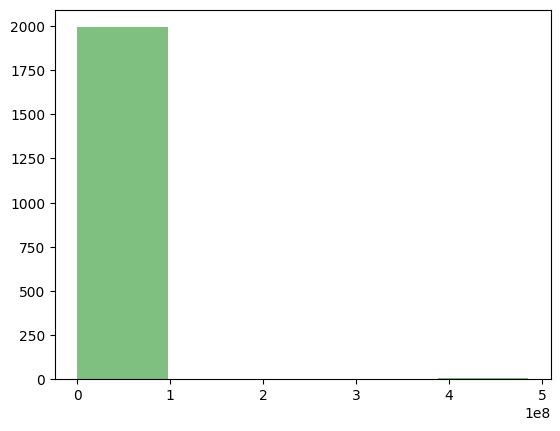

In [507]:
plt.hist(uncertainty_list, bins=5, alpha=0.5, color='green')

In [508]:
hist_info_TP

(array([1.189e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([1.00030947e+00, 1.61721740e+07, 3.23443480e+07, 4.85165200e+07,
        6.46886920e+07, 8.08608640e+07, 9.70330400e+07, 1.13205208e+08,
        1.29377384e+08, 1.45549552e+08, 1.61721728e+08, 1.77893904e+08,
        1.94066080e+08, 2.10238256e+08, 2.26410416e+08, 2.42582592e+08,
        2.58754768e+08, 2.74926944e+08, 2.91099104e+08, 3.07271296e+08,
        3.23443456e+08, 3.39615648e+08, 3.55787808e+08, 3.71959968e+08,
        3.88132160e+08, 4.04304320e+08, 4.20476512e+08, 4.36648672e+08,
        4.52820832e+08, 4.68993024e+08, 4.85165184e+08]),
 <BarContainer object of 30 artists>)

In [510]:
np.exp( (0.9-0.8) / ((1.7)/2) )

np.float64(1.1248470364630234)

In [511]:
np.exp( (0.8-0.6) / ((1.4)/2) )

np.float64(1.3307121974473501)

#### uncertainty 1 ~ 10

TP_uncertainty.stats: len=1189, mean=17.893070220947266, max=72.7071304321289, min=3.175366163253784, std=10.230877876281738
FP_uncertainty.stats: len=805, mean=33.08189392089844, max=101.21187591552734, min=6.340346336364746, std=16.546417236328125


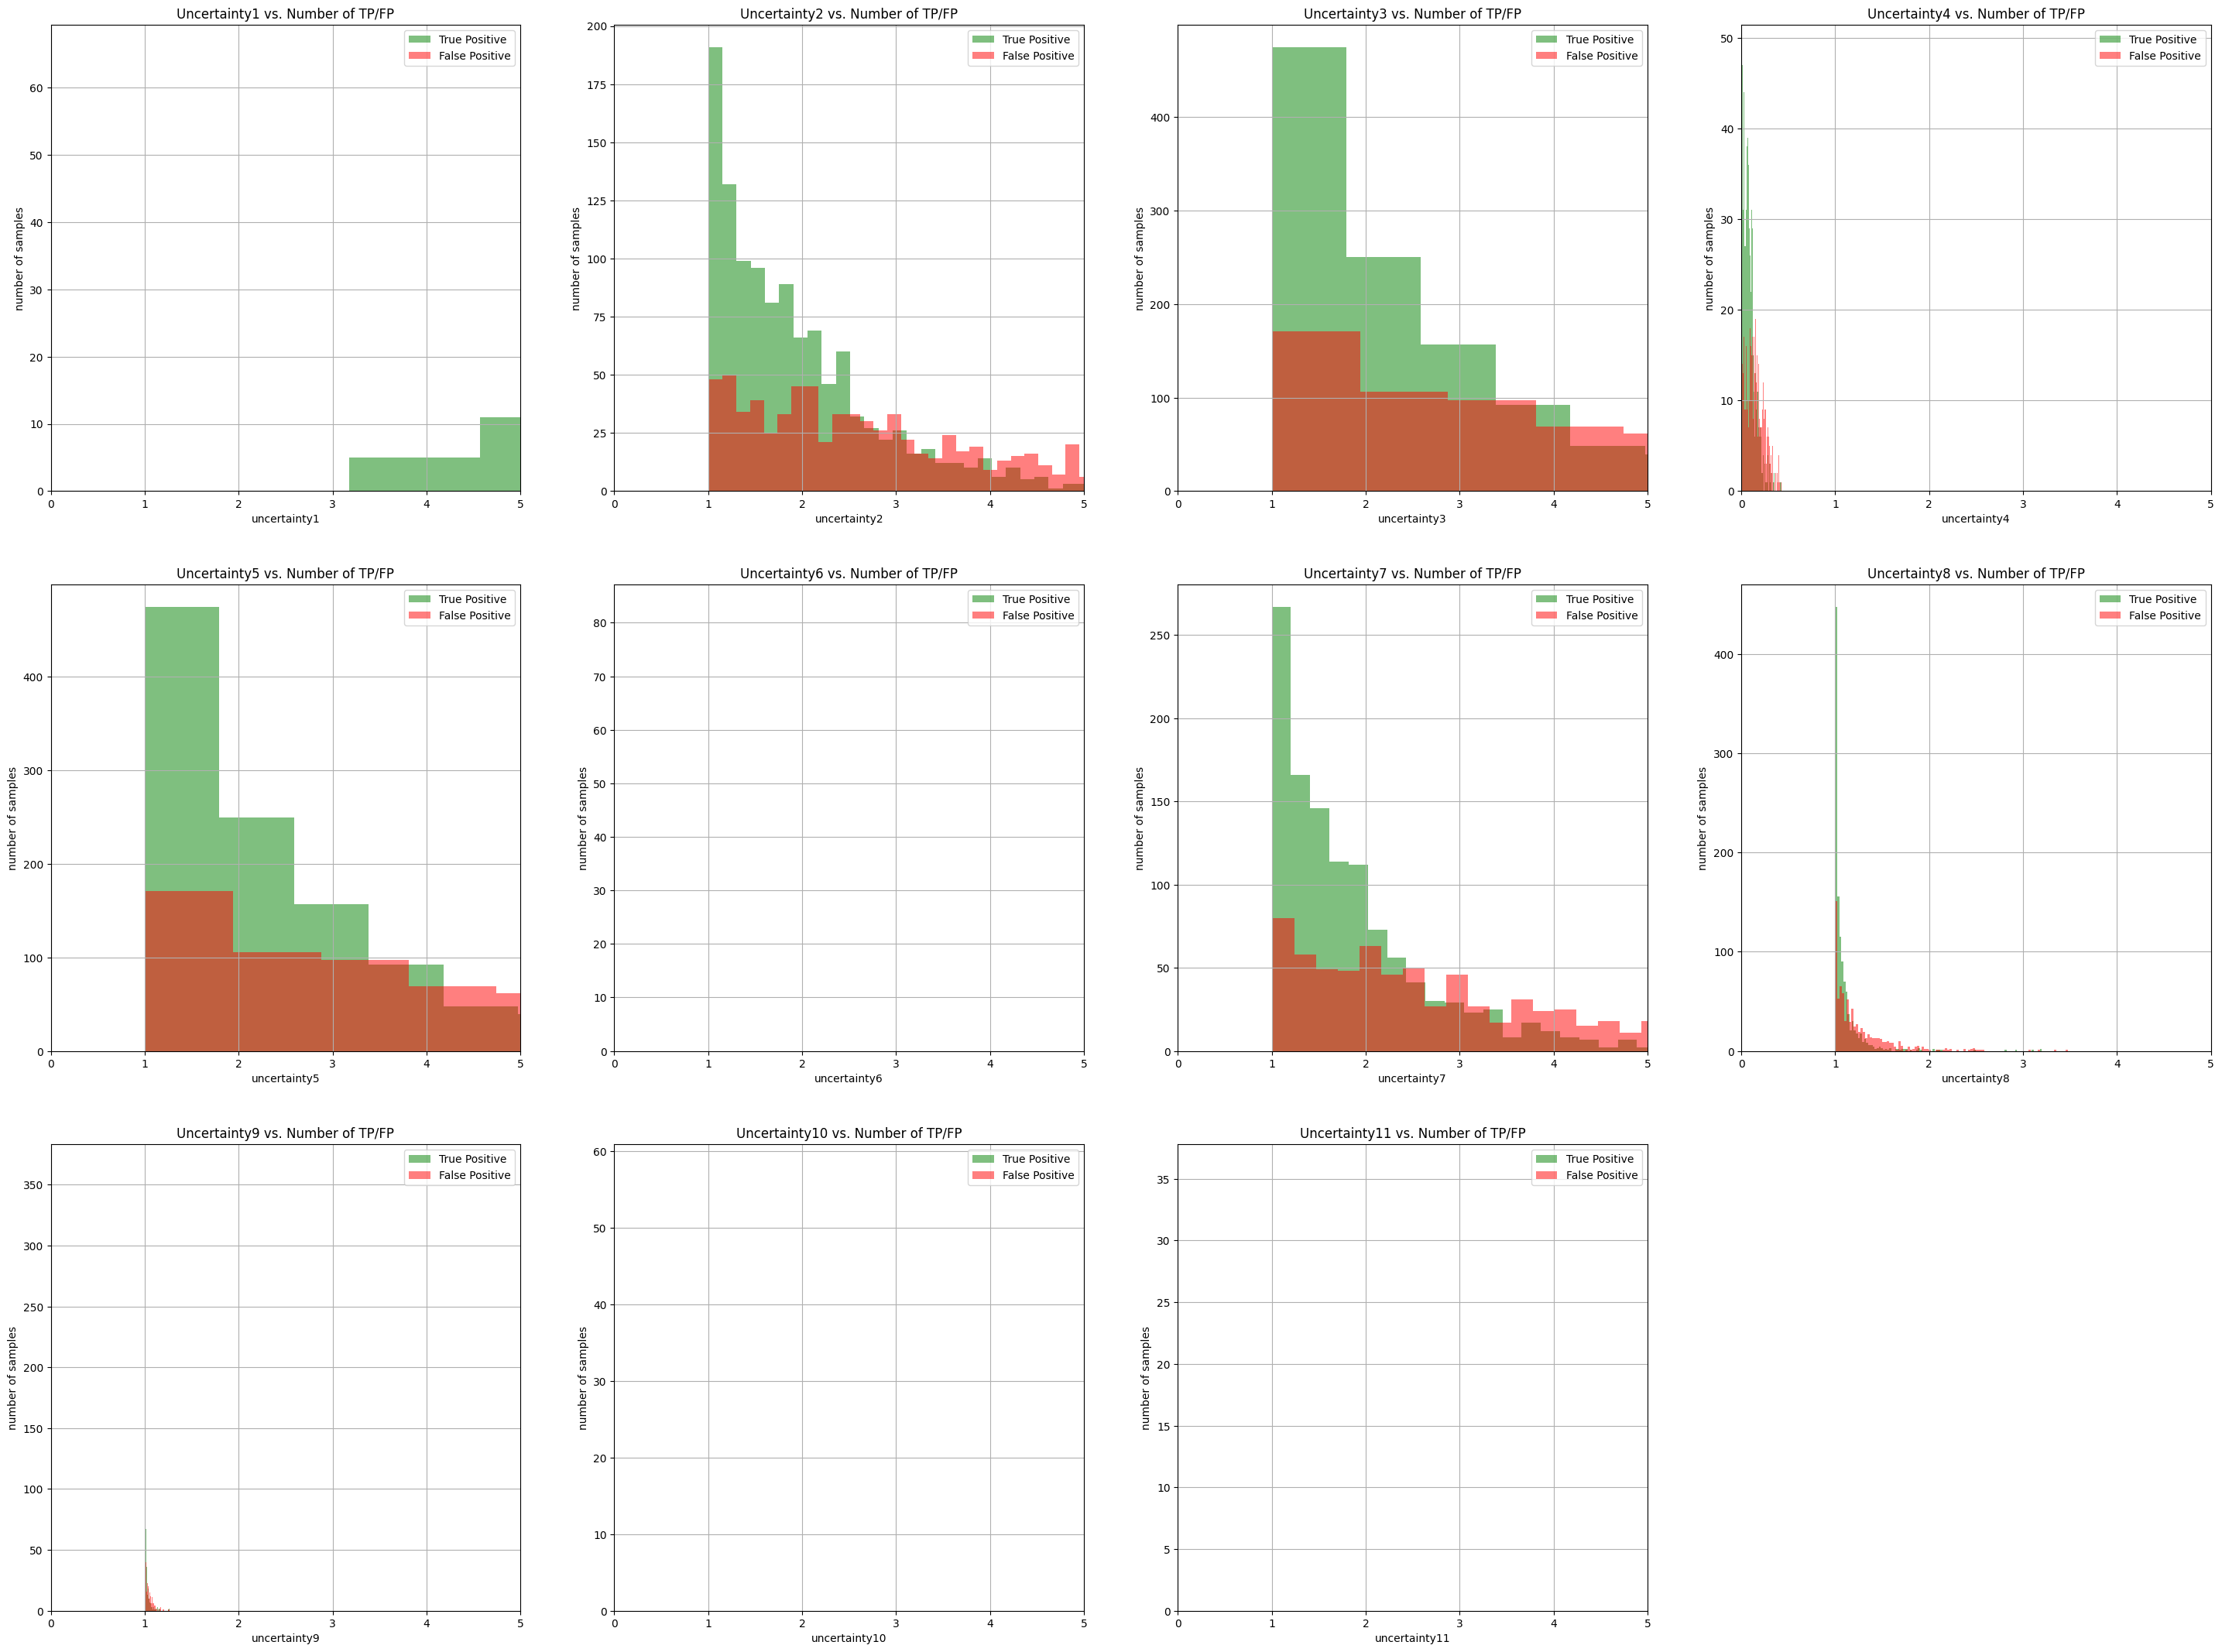

In [515]:
### plot uncertainty vs. TP/FP
plt.figure(figsize=(36,36))

for i in range(len(uncertainty_list_list)):
    uncertainty_list = uncertainty_list_list[i]

    TP_unc = []
    FP_unc = []
    for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i_norm, uncertainty_list)):
        if sample_idx not in selected_idx:
            continue
        sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
        if gids[idx_topk[0].numpy()] == qids[sample_idx]:
            TP_unc.append(unc )
        else:
            FP_unc.append(unc )

    if i == 0:
        print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
        print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

    plt.subplot(4,4,i+1)
    hist_info_TP = plt.hist(TP_unc, bins=100, alpha=0.5, color='green')
    hist_info_FP = plt.hist(FP_unc, bins=100, alpha=0.5, color='red')
    plt.xlim(0,5)
    plt.grid(True)
    plt.legend(['True Positive', 'False Positive'])
    plt.xlabel(f'uncertainty{i+1}')
    plt.ylabel('number of samples')
    plt.title(f'Uncertainty{i+1} vs. Number of TP/FP')



TP_uncertainty.stats: len=1190, mean=18.523338317871094, max=767.9151000976562, min=3.175366163253784, std=24.018796920776367
FP_uncertainty.stats: len=810, mean=38.31501388549805, max=968.0347290039062, min=6.340346336364746, std=68.82953643798828


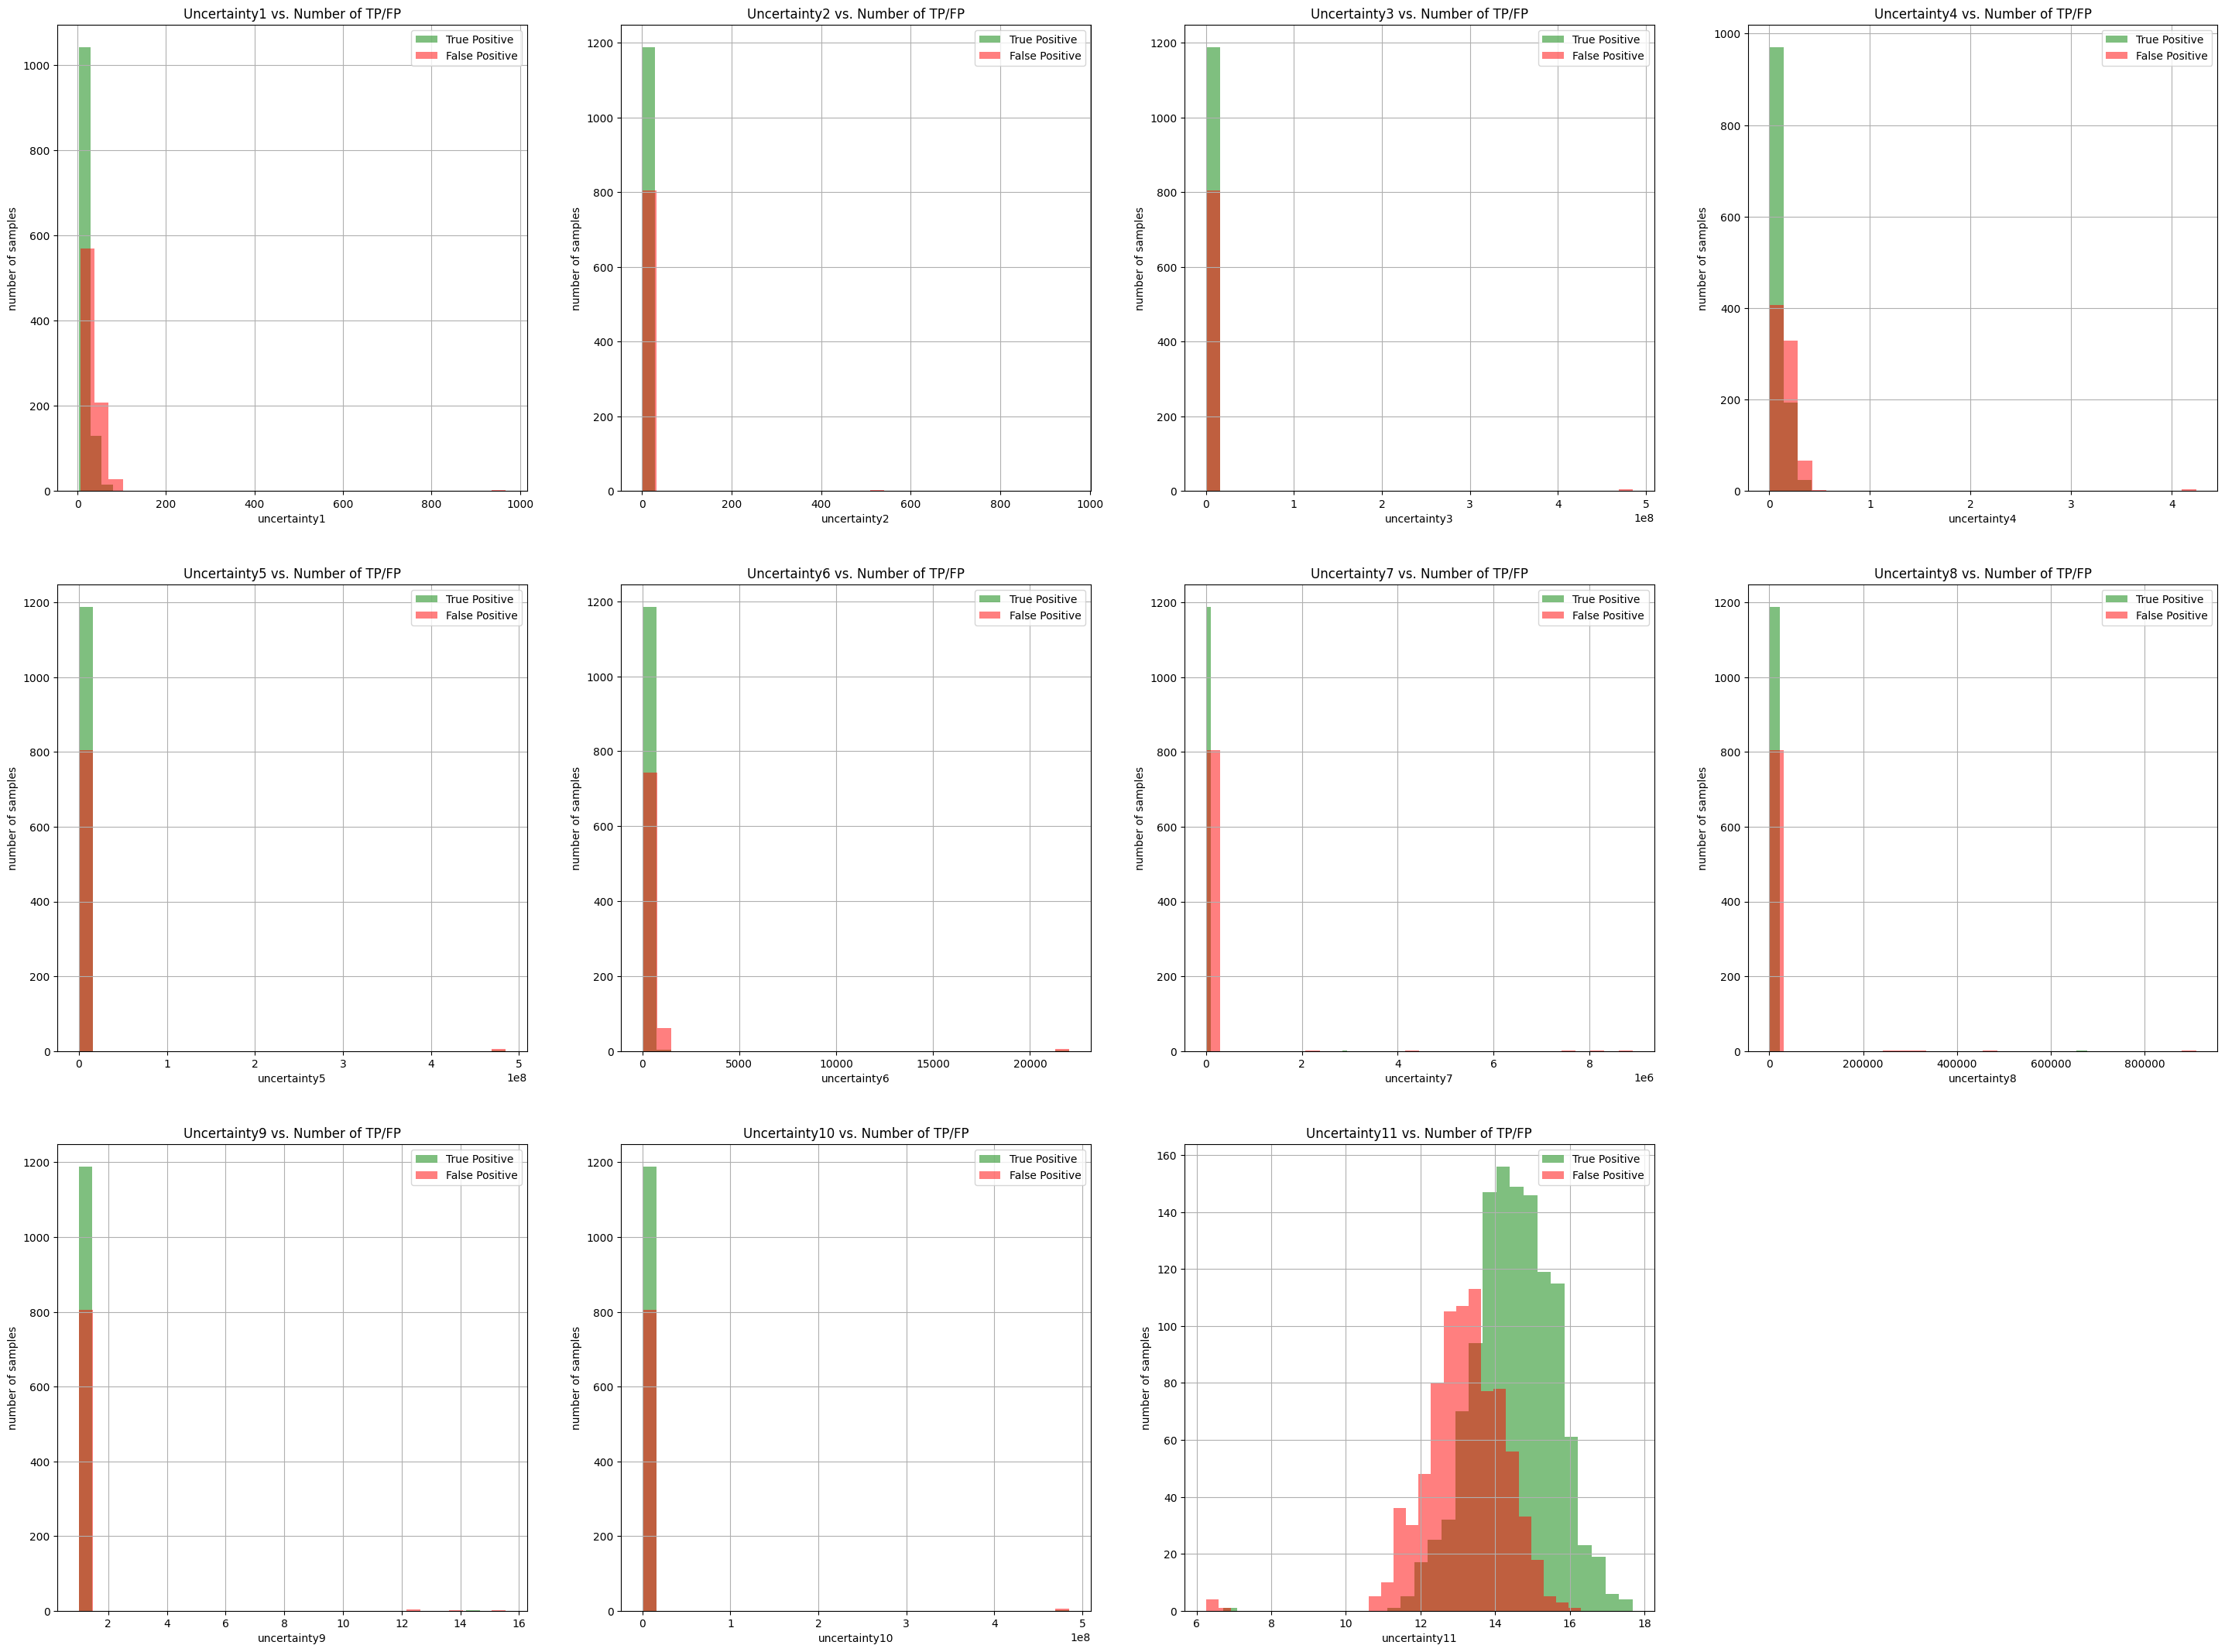

In [496]:
### plot uncertainty vs. TP/FP
plt.figure(figsize=(36,36))

for i in range(len(uncertainty_list_list)):
    uncertainty_list = uncertainty_list_list[i]

    TP_unc = []
    FP_unc = []
    for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i_norm, uncertainty_list)):
        sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
        if gids[idx_topk[0].numpy()] == qids[sample_idx]:
            TP_unc.append(unc)
        else:
            FP_unc.append(unc)

    if i == 0:
        print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
        print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

    plt.subplot(4,4,i+1)
    hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
    hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
    # plt.xlim(0,1.5)
    plt.grid(True)
    plt.legend(['True Positive', 'False Positive'])
    plt.xlabel(f'uncertainty{i+1}')
    plt.ylabel('number of samples')
    plt.title(f'Uncertainty{i+1} vs. Number of TP/FP')



### New Uncertainty Design - kl_div [TODO]

In [468]:
# uncertainty5_list = []

# qfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"])
# gfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"])
# qfeats_norm = F.normalize(qfeats, p=2, dim=1)
# gfeats_norm = F.normalize(gfeats, p=2, dim=1)
# sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()

# sims_matrix_t2i_norm.shape

In [469]:
# kls_matrix_t2i = torch.zeros((2000, 1000))

# for q_idx in range(len(qfeats)):
#     for g_idx in range(len(gfeats)):
#         # print(qfeats[q_idx, :].shape)
#         # print(gfeats[g_idx, :].shape)
#         # print(F.kl_div(qfeats[q_idx, :], gfeats[g_idx, :], reduction="none").sum(dim=-1).shape)
#         kls_matrix_t2i[q_idx, g_idx] = F.kl_div(qfeats[q_idx, :], gfeats[g_idx, :], reduction="none").sum(dim=-1)
#         # break
#     # break

## def sample_selection_and_uncertainty_analysis(task_name):

In [470]:
# def sample_selection_and_uncertainty_analysis(task_name):
#     embeds_dict = {}
#     embeds_dict["sims_matrix_t2i"] = np.load(f'debug_embeddings/{task_name}/sims_matrix_t2i.npy')
#     embeds_dict["uncertaintys_list"] = np.load(f'debug_embeddings/{task_name}/uncertaintys_list.npy')
#     embeds_dict["ss_idxs_list"] = np.load(f'debug_embeddings/{task_name}/ss_idxs_list.npy')
#     # embeds_dict["sampled_sims_matrix_t2i"] = np.load(f'debug_embeddings/{task_name}/sampled_sims_matrix_t2i.npy')
#     embeds_dict["sampled_sims_idx_t2i"] = np.load(f'debug_embeddings/{task_name}/sampled_sims_idx_t2i.npy')
#     embeds_dict["qids"] = np.load(f'debug_embeddings/{task_name}/qids.npy')
#     embeds_dict["gids"] = np.load(f'debug_embeddings/{task_name}/gids.npy')
#     embeds_dict["qfeats"] = np.load(f'debug_embeddings/{task_name}/qfeats.npy')
#     embeds_dict["gfeats"] = np.load(f'debug_embeddings/{task_name}/gfeats.npy')


#     print('\n\n Origin Score')
#     qfeats_norm = F.normalize(torch.from_numpy(embeds_dict["qfeats"]), p=2, dim=1)
#     gfeats_norm = F.normalize(torch.from_numpy(embeds_dict["gfeats"]), p=2, dim=1)
#     sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
#     print("eval_result_norm")
#     embeds_dict['eval_result_norm'] = computer_metric(
#         sims_matrix_t2i_norm,
#         torch.from_numpy(embeds_dict["qids"]),
#         torch.from_numpy(embeds_dict["gids"])
#     )
#     print("eval_result")
#     embeds_dict['eval_result'] = computer_metric(
#         torch.from_numpy(embeds_dict["sims_matrix_t2i"]),
#         torch.from_numpy(embeds_dict["qids"]),
#         torch.from_numpy(embeds_dict["gids"])
#     )


#     print('\n\n Sample Selection Score')
#     ss_idxs_list = embeds_dict["ss_idxs_list"].tolist()

#     qfeats_norm = F.normalize(torch.from_numpy(embeds_dict["qfeats"]), p=2, dim=1)
#     gfeats_norm = F.normalize(torch.from_numpy(embeds_dict["gfeats"]), p=2, dim=1)
#     sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
#     print("eval_result_norm_ss")
#     embeds_dict['eval_result_norm_ss'] = computer_metric(
#         sims_matrix_t2i_norm[ss_idxs_list],
#         torch.from_numpy(embeds_dict["qids"][ss_idxs_list]),
#         torch.from_numpy(embeds_dict["gids"])
#     )
#     print("eval_result_ss")
#     embeds_dict['eval_result_ss'] = computer_metric(
#         torch.from_numpy(embeds_dict["sims_matrix_t2i"][ss_idxs_list]),
#         torch.from_numpy(embeds_dict["qids"][ss_idxs_list]),
#         torch.from_numpy(embeds_dict["gids"])
#     )


#     print('\n\n Uncertainty vs. TP/FP Analysis')
#     print(embeds_dict["uncertaintys_list"].shape)
#     print(embeds_dict["sampled_sims_idx_t2i"].shape)

#     print(embeds_dict["qids"].shape)
#     print(embeds_dict["gids"].shape)

#     TP_unc = []
#     FP_unc = []
#     for sample_idx, (sampled_sim_idx, unc) in enumerate(zip(embeds_dict["sampled_sims_idx_t2i"], embeds_dict["uncertaintys_list"])):
#         if embeds_dict["gids"][sampled_sim_idx[0]] == embeds_dict["qids"][sample_idx]:
#             TP_unc.append(unc)
#         else:
#             FP_unc.append(unc)

#     print("\nTP_unc.stats,    FP_unc.stats")
#     print(len(TP_unc), '             ', len(FP_unc))
#     print(np.mean(TP_unc), '     ', np.mean(FP_unc))
#     print(np.max(TP_unc), '     ', np.max(FP_unc))
#     print(np.min(TP_unc), '               ', np.min(FP_unc))
#     print(np.std(TP_unc), '     ', np.std(FP_unc))

#     plt.figure(figsize=(12,5))
#     # plt.subplot(1,2,1)
#     plt.hist(TP_unc, bins=30, alpha=0.5)
#     # plt.subplot(1,2,2)
#     plt.hist(FP_unc, bins=30, alpha=0.5)

#     # plt.hist(embeds_dict["uncertaintys_list"], bins=30, alpha=0.5)


#     print('\n\n Uncertainty_SS vs. TP/FP Analysis')
#     print(embeds_dict["uncertaintys_list"][ss_idxs_list].shape)
#     print(embeds_dict["sampled_sims_idx_t2i"][ss_idxs_list].shape)

#     print(embeds_dict["qids"][ss_idxs_list].shape)
#     print(embeds_dict["gids"].shape)

#     TP_unc = []
#     FP_unc = []
#     for sample_idx, (sampled_sim_idx, unc) in enumerate(zip(embeds_dict["sampled_sims_idx_t2i"][ss_idxs_list], embeds_dict["uncertaintys_list"][ss_idxs_list])):
#         if embeds_dict["gids"][sampled_sim_idx[0]] == embeds_dict["qids"][ss_idxs_list][sample_idx]:
#             TP_unc.append(unc)
#         else:
#             FP_unc.append(unc)

#     print("\nTP_unc.stats,    FP_unc.stats")
#     print(len(TP_unc), '             ', len(FP_unc))
#     print(np.mean(TP_unc), '     ', np.mean(FP_unc))
#     print(np.max(TP_unc), '     ', np.max(FP_unc))
#     print(np.min(TP_unc), '               ', np.min(FP_unc))
#     print(np.std(TP_unc), '     ', np.std(FP_unc))

#     plt.figure(figsize=(12,5))
#     # plt.subplot(1,2,1)
#     plt.hist(TP_unc, bins=30, alpha=0.5)
#     # plt.subplot(1,2,2)
#     plt.hist(FP_unc, bins=30, alpha=0.5)

#     # plt.hist(embeds_dict["uncertaintys_list"], bins=30, alpha=0.5)

## ham_cuhk_tta

### show score & unc_tp/fp

In [471]:
# sample_selection_and_uncertainty_analysis("ham_cuhk_tta")

### New Uncertainty Design - cos_sim

In [472]:

def compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_i2t, uncertainty_temper=1.0, uncertainty_t2i_temper=1.0, uncertainty_i2t_temper=1.0, k_test = 128):
    uncertaintys_list = []
    uncertainty2_list = []
    uncertainty3_list = []
    uncertainty4_list = []
    uncertainty5_list = []
    uncertainty6_list = []
    uncertainty7_list = []

    cos_uncertaintys_list = []
    cos_uncertainty2_list = []
    cos_uncertainty3_list = []
    cos_uncertainty4_list = []

    proba_top1_sim_list = []
    proba_inversed_sim_list = []

    cos_top1_sim_list = []
    cos_inversed_sim_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):

        topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
        proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象
        cos_top1_sim_t2i = topk_sim_t2i[0]

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        cos_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]
            cos_inversed_sim_i2t_top1_idx_t2i = topk_sim_i2t_top1_idx_t2i[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )
        uncertainty5 = torch.exp( torch.abs(proba_top1_sim_t2i*N_t2i - proba_inversed_sim_i2t_top1_idx_t2i*N_i2t) / ((proba_top1_sim_t2i*N_t2i + proba_inversed_sim_i2t_top1_idx_t2i*N_i2t)/2) * uncertainty_temper )
        uncertainty6 = torch.exp( (1/ (N_t2i*N_i2t) - (proba_top1_sim_t2i*proba_inversed_sim_i2t_top1_idx_t2i )) * uncertainty_temper )
        uncertainty7 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper  * 1/torch.max(proba_top1_sim_t2i, proba_inversed_sim_i2t_top1_idx_t2i))
        cos_uncertainty = torch.exp( (1 - (cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        cos_uncertainty2 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        cos_uncertainty3 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) / ((cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        cos_uncertainty4 = torch.abs( torch.log(cos_top1_sim_t2i + 1e-2) - torch.log( cos_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        uncertaintys_list.append(uncertainty)
        uncertainty2_list.append(uncertainty2)
        uncertainty3_list.append(uncertainty3)
        uncertainty4_list.append(uncertainty4)
        uncertainty5_list.append(uncertainty5)
        uncertainty6_list.append(uncertainty6)
        uncertainty7_list.append(uncertainty7)
        proba_top1_sim_list.append(proba_top1_sim_t2i)
        proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)

        cos_uncertaintys_list.append(cos_uncertainty)
        cos_uncertainty2_list.append(cos_uncertainty2)
        cos_uncertainty3_list.append(cos_uncertainty3)
        cos_uncertainty4_list.append(cos_uncertainty4)
        cos_top1_sim_list.append(cos_top1_sim_t2i)
        cos_inversed_sim_list.append(cos_inversed_sim_i2t_top1_idx_t2i)
    return uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list, uncertainty7_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list

In [473]:
task_name = "ham_cuhk_tta"

ham_cuhk_tta_embeds_dict = {}
ham_cuhk_tta_embeds_dict["sims_matrix_t2i"] = np.load(f'debug_embeddings/{task_name}/sims_matrix_t2i.npy')
ham_cuhk_tta_embeds_dict["uncertaintys_list"] = np.load(f'debug_embeddings/{task_name}/uncertaintys_list.npy')
ham_cuhk_tta_embeds_dict["ss_idxs_list"] = np.load(f'debug_embeddings/{task_name}/ss_idxs_list.npy')
# embeds_dict["sampled_sims_matrix_t2i"] = np.load(f'debug_embeddings/{task_name}/sampled_sims_matrix_t2i.npy')
ham_cuhk_tta_embeds_dict["sampled_sims_idx_t2i"] = np.load(f'debug_embeddings/{task_name}/sampled_sims_idx_t2i.npy')
ham_cuhk_tta_embeds_dict["qids"] = np.load(f'debug_embeddings/{task_name}/qids.npy')
ham_cuhk_tta_embeds_dict["gids"] = np.load(f'debug_embeddings/{task_name}/gids.npy')
ham_cuhk_tta_embeds_dict["qfeats"] = np.load(f'debug_embeddings/{task_name}/qfeats.npy')
ham_cuhk_tta_embeds_dict["gfeats"] = np.load(f'debug_embeddings/{task_name}/gfeats.npy')

In [474]:
### hyper-parameters of uncertainty
uncertainty_temper = 1
uncertainty_t2i_temper = 1
uncertainty_i2t_temper = 1
k_test = 128
N_t2i = 6.148
N_i2t = 3.074

### get query & gallery features
qfeats = torch.from_numpy(ham_cuhk_tta_embeds_dict["qfeats"])
gfeats = torch.from_numpy(ham_cuhk_tta_embeds_dict["gfeats"])
qfeats_norm = F.normalize(qfeats, p=2, dim=1)
gfeats_norm = F.normalize(gfeats, p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
### get cos_sims_matrix
sims_matrix_t2i = torch.from_numpy(ham_cuhk_tta_embeds_dict["sims_matrix_t2i"])
### get labels
gids = torch.from_numpy(ham_cuhk_tta_embeds_dict["gids"])
qids = torch.from_numpy(ham_cuhk_tta_embeds_dict["qids"])

### compute uncertainty
uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list,uncertainty7_list,proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list = compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_t2i.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)
# uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, proba_top1_sim_list, proba_inversed_sim_list = compute_uncertainty_itc(qfeats, gfeats, sims_matrix_t2i_norm, sims_matrix_t2i_norm.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)

print(f"len(uncertaintys_list) = {len(uncertaintys_list)}")
print(f"len(uncertainty2_list) = {len(uncertainty2_list)}")
print(f"len(uncertainty3_list) = {len(uncertainty3_list)}")
print(f"len(uncertainty4_list) = {len(uncertainty4_list)}")

print(uncertaintys_list[:10])
print(uncertainty2_list[:10])
print(uncertainty3_list[:10])
print(uncertainty4_list[:10])

len(uncertaintys_list) = 6156
len(uncertainty2_list) = 6156
len(uncertainty3_list) = 6156
len(uncertainty4_list) = 6156
[tensor(1.6013), tensor(1.5693), tensor(2.1521), tensor(2.1136), tensor(2.1246), tensor(1.3746), tensor(2.2270), tensor(1.9259), tensor(2.4685), tensor(2.5032)]
[tensor(1.4544), tensor(1.3119), tensor(1.5871), tensor(1.6209), tensor(1.5244), tensor(1.3088), tensor(1.3790), tensor(1.4179), tensor(1.2060), tensor(1.1597)]
[tensor(2.0295), tensor(1.6392), tensor(7.2250), tensor(6.8178), tensor(5.5336), tensor(1.4840), tensor(5.0126), tensor(2.7544), tensor(6.9802), tensor(6.0371)]
[tensor(0.7248), tensor(0.4952), tensor(3.6269), tensor(3.2190), tensor(2.3263), tensor(0.3941), tensor(2.0283), tensor(1.0782), tensor(2.7536), tensor(2.2067)]


#### uncertainty_1

TP_uncertainty.stats: len=4276, mean=1.7499775886535645, max=2.6051313877105713, min=1.0005125999450684, std=0.3790029287338257
FP_uncertainty.stats: len=1880, mean=2.1788928508758545, max=2.6314210891723633, min=1.0925530195236206, std=0.2875905930995941


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

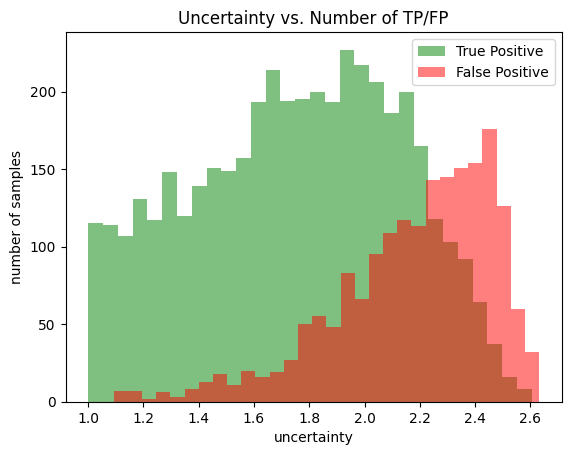

In [475]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertaintys_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_2

TP_uncertainty.stats: len=4276, mean=1.4940954446792603, max=2.6932454109191895, min=1.0000141859054565, std=0.36266398429870605
FP_uncertainty.stats: len=1880, mean=1.4005160331726074, max=2.6003520488739014, min=1.0005362033843994, std=0.2766451835632324


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

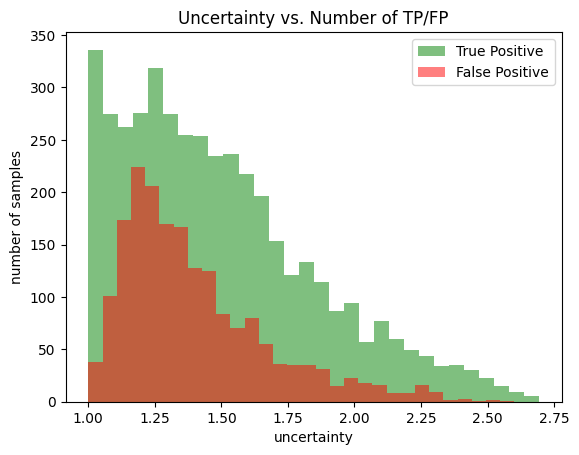

In [476]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty2_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_3

TP_uncertainty.stats: len=4276, mean=3.589647054672241, max=7.385621547698975, min=1.0000306367874146, std=2.211365222930908
FP_uncertainty.stats: len=1880, mean=5.352712154388428, max=7.388988971710205, min=1.0010390281677246, std=2.0283894538879395


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

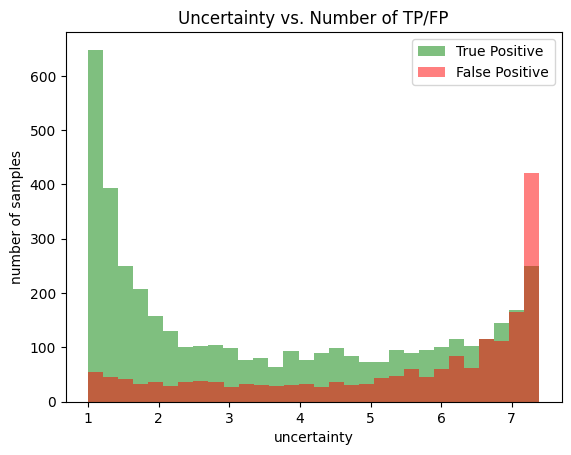

In [477]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty3_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_4

TP_uncertainty.stats: len=4276, mean=1.4666863679885864, max=4.502477169036865, min=2.9981136322021484e-05, std=1.1953003406524658
FP_uncertainty.stats: len=1880, mean=2.2711360454559326, max=4.41402006149292, min=0.0010187625885009766, std=1.056487798690796


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

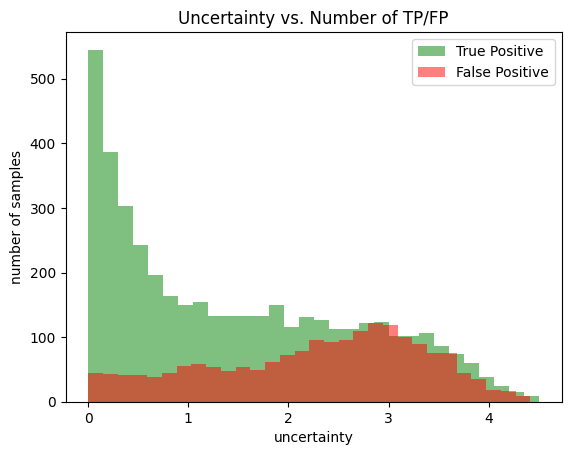

In [478]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty4_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_5

TP_uncertainty.stats: len=4276, mean=4.469692707061768, max=7.3873395919799805, min=1.0010114908218384, std=2.025191307067871
FP_uncertainty.stats: len=1880, mean=5.980195045471191, max=7.3890228271484375, min=1.0163938999176025, std=1.647088885307312


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

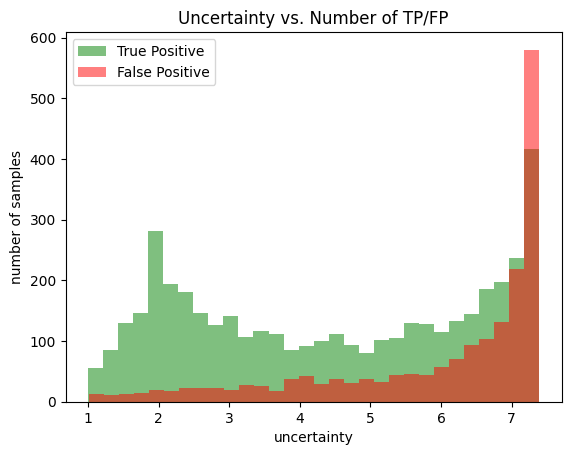

In [479]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty5_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_6

TP_uncertainty.stats: len=4276, mean=0.8717830777168274, max=1.0543360710144043, min=0.388266921043396, std=0.19447395205497742
FP_uncertainty.stats: len=1880, mean=1.016554832458496, max=1.0543378591537476, min=0.4599524140357971, std=0.08382609486579895


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

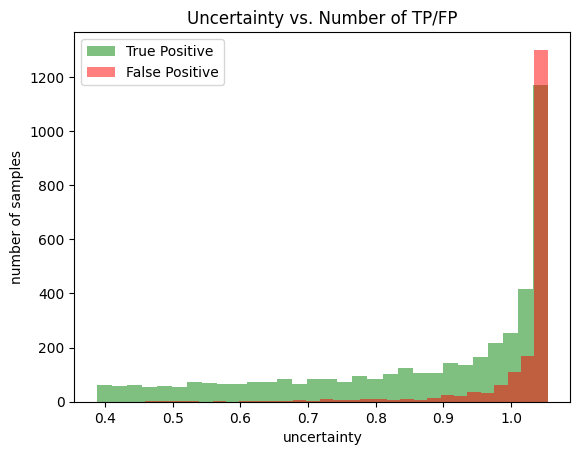

In [480]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty6_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty7_list

TP_uncertainty.stats: len=4276, mean=23.40102767944336, max=31181.044921875, min=1.0000331401824951, std=522.54931640625
FP_uncertainty.stats: len=1880, mean=6294.00048828125, max=3783586.75, min=1.0010058879852295, std=107302.1328125


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

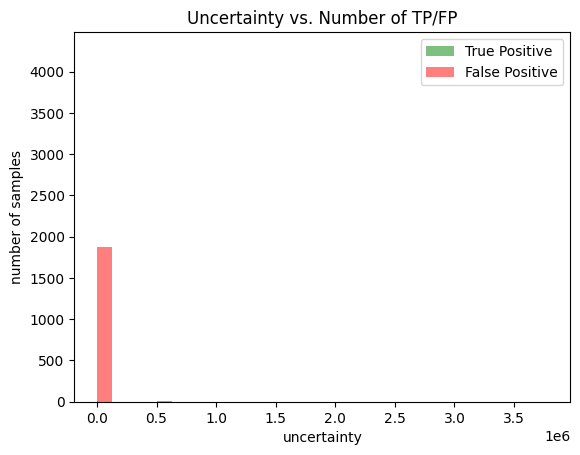

In [481]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty7_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

## ham_icfg_tta

### show score & unc_tp/fp

In [482]:
# sample_selection_and_uncertainty_analysis("ham_icfg_tta")

### New Uncertainty Design - cos_sim

In [483]:

def compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_i2t, uncertainty_temper=1.0, uncertainty_t2i_temper=1.0, uncertainty_i2t_temper=1.0, k_test = 128):
    uncertaintys_list = []
    uncertainty2_list = []
    uncertainty3_list = []
    uncertainty4_list = []
    uncertainty5_list = []
    uncertainty6_list = []
    uncertainty7_list = []

    cos_uncertaintys_list = []
    cos_uncertainty2_list = []
    cos_uncertainty3_list = []
    cos_uncertainty4_list = []

    proba_top1_sim_list = []
    proba_inversed_sim_list = []

    cos_top1_sim_list = []
    cos_inversed_sim_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):

        topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
        proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象
        cos_top1_sim_t2i = topk_sim_t2i[0]

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        cos_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]
            cos_inversed_sim_i2t_top1_idx_t2i = topk_sim_i2t_top1_idx_t2i[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )
        uncertainty5 = torch.exp( torch.abs(proba_top1_sim_t2i*N_t2i - proba_inversed_sim_i2t_top1_idx_t2i*N_i2t) / ((proba_top1_sim_t2i*N_t2i + proba_inversed_sim_i2t_top1_idx_t2i*N_i2t)/2) * uncertainty_temper )
        uncertainty6 = torch.exp( (1/ (N_t2i*N_i2t) - (proba_top1_sim_t2i*proba_inversed_sim_i2t_top1_idx_t2i )) * uncertainty_temper )
        uncertainty7 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper  * 1/torch.max(proba_top1_sim_t2i, proba_inversed_sim_i2t_top1_idx_t2i))
        cos_uncertainty = torch.exp( (1 - (cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        cos_uncertainty2 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        cos_uncertainty3 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) / ((cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        cos_uncertainty4 = torch.abs( torch.log(cos_top1_sim_t2i + 1e-2) - torch.log( cos_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        uncertaintys_list.append(uncertainty)
        uncertainty2_list.append(uncertainty2)
        uncertainty3_list.append(uncertainty3)
        uncertainty4_list.append(uncertainty4)
        uncertainty5_list.append(uncertainty5)
        uncertainty6_list.append(uncertainty6)
        uncertainty7_list.append(uncertainty7)
        proba_top1_sim_list.append(proba_top1_sim_t2i)
        proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)

        cos_uncertaintys_list.append(cos_uncertainty)
        cos_uncertainty2_list.append(cos_uncertainty2)
        cos_uncertainty3_list.append(cos_uncertainty3)
        cos_uncertainty4_list.append(cos_uncertainty4)
        cos_top1_sim_list.append(cos_top1_sim_t2i)
        cos_inversed_sim_list.append(cos_inversed_sim_i2t_top1_idx_t2i)
    return uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list, uncertainty7_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list

In [484]:
task_name = "ham_icfg_tta"

ham_icfg_tta_embeds_dict = {}
ham_icfg_tta_embeds_dict["sims_matrix_t2i"] = np.load(f'debug_embeddings/{task_name}/sims_matrix_t2i.npy')
ham_icfg_tta_embeds_dict["uncertaintys_list"] = np.load(f'debug_embeddings/{task_name}/uncertaintys_list.npy')
ham_icfg_tta_embeds_dict["ss_idxs_list"] = np.load(f'debug_embeddings/{task_name}/ss_idxs_list.npy')
# embeds_dict["sampled_sims_matrix_t2i"] = np.load(f'debug_embeddings/{task_name}/sampled_sims_matrix_t2i.npy')
ham_icfg_tta_embeds_dict["sampled_sims_idx_t2i"] = np.load(f'debug_embeddings/{task_name}/sampled_sims_idx_t2i.npy')
ham_icfg_tta_embeds_dict["qids"] = np.load(f'debug_embeddings/{task_name}/qids.npy')
ham_icfg_tta_embeds_dict["gids"] = np.load(f'debug_embeddings/{task_name}/gids.npy')
ham_icfg_tta_embeds_dict["qfeats"] = np.load(f'debug_embeddings/{task_name}/qfeats.npy')
ham_icfg_tta_embeds_dict["gfeats"] = np.load(f'debug_embeddings/{task_name}/gfeats.npy')

In [485]:
### hyper-parameters of uncertainty
uncertainty_temper = 1
uncertainty_t2i_temper = 1
uncertainty_i2t_temper = 1
k_test = 128
N_t2i = 13.29
N_i2t = 13.29

### get query & gallery features
qfeats = torch.from_numpy(ham_icfg_tta_embeds_dict["qfeats"])
gfeats = torch.from_numpy(ham_icfg_tta_embeds_dict["gfeats"])
qfeats_norm = F.normalize(qfeats, p=2, dim=1)
gfeats_norm = F.normalize(gfeats, p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
### get cos_sims_matrix
sims_matrix_t2i = torch.from_numpy(ham_icfg_tta_embeds_dict["sims_matrix_t2i"]) #/ 0.5
### get labels
gids = torch.from_numpy(ham_icfg_tta_embeds_dict["gids"])
qids = torch.from_numpy(ham_icfg_tta_embeds_dict["qids"])

### compute uncertainty
uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list, uncertainty7_list,proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list = compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_t2i.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)
# uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, proba_top1_sim_list, proba_inversed_sim_list = compute_uncertainty_itc(qfeats, gfeats, sims_matrix_t2i_norm, sims_matrix_t2i_norm.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)

print(f"len(uncertaintys_list) = {len(uncertaintys_list)}")
print(f"len(uncertainty2_list) = {len(uncertainty2_list)}")
print(f"len(uncertainty3_list) = {len(uncertainty3_list)}")
print(f"len(uncertainty4_list) = {len(uncertainty4_list)}")

print(uncertaintys_list[:10])
print(uncertainty2_list[:10])
print(uncertainty3_list[:10])
print(uncertainty4_list[:10])

len(uncertaintys_list) = 19848
len(uncertainty2_list) = 19848
len(uncertainty3_list) = 19848
len(uncertainty4_list) = 19848
[tensor(1.5258), tensor(2.3065), tensor(2.1789), tensor(2.1357), tensor(2.4512), tensor(1.7367), tensor(2.3368), tensor(2.6232), tensor(1.7073), tensor(1.8899)]
[tensor(1.1584), tensor(1.3041), tensor(1.3169), tensor(1.6161), tensor(1.0543), tensor(1.0188), tensor(1.2434), tensor(1.0626), tensor(1.4886), tensor(1.0720)]
[tensor(1.2900), tensor(5.0327), tensor(3.4709), tensor(7.3153), tensor(1.6682), tensor(1.0425), tensor(4.2230), tensor(5.5039), tensor(2.3524), tensor(1.2109)]
[tensor(0.2517), tensor(2.0001), tensor(1.3717), tensor(3.7801), tensor(0.4754), tensor(0.0407), tensor(1.6419), tensor(1.6061), tensor(0.8923), tensor(0.1868)]


#### uncertainty_1

TP_uncertainty.stats: len=12054, mean=2.069711685180664, max=2.6723341941833496, min=1.0000696182250977, std=0.35587674379348755
FP_uncertainty.stats: len=7794, mean=2.367621660232544, max=2.6790997982025146, min=1.0771677494049072, std=0.2336844950914383


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

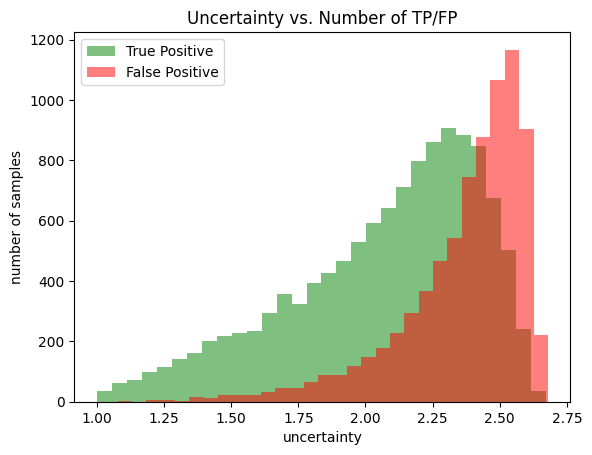

In [486]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertaintys_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_2

TP_uncertainty.stats: len=12054, mean=1.2371106147766113, max=2.510000228881836, min=1.0000149011611938, std=0.19556424021720886
FP_uncertainty.stats: len=7794, mean=1.1602680683135986, max=2.273690700531006, min=1.0000489950180054, std=0.14167143404483795


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

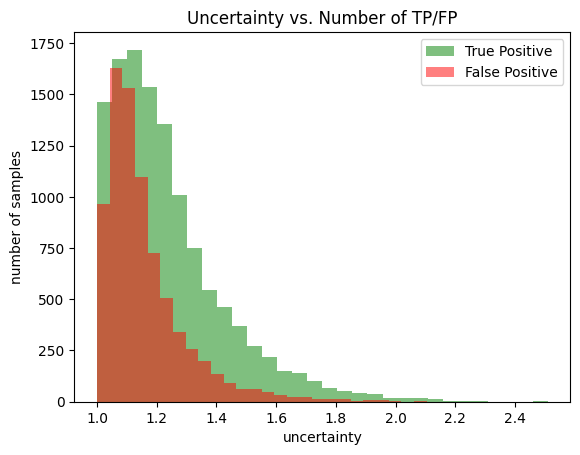

In [487]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty2_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_3

TP_uncertainty.stats: len=12054, mean=2.9524753093719482, max=7.389056205749512, min=1.0000475645065308, std=1.8031998872756958
FP_uncertainty.stats: len=7794, mean=3.761415481567383, max=7.389056205749512, min=1.0004912614822388, std=1.954252004623413


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

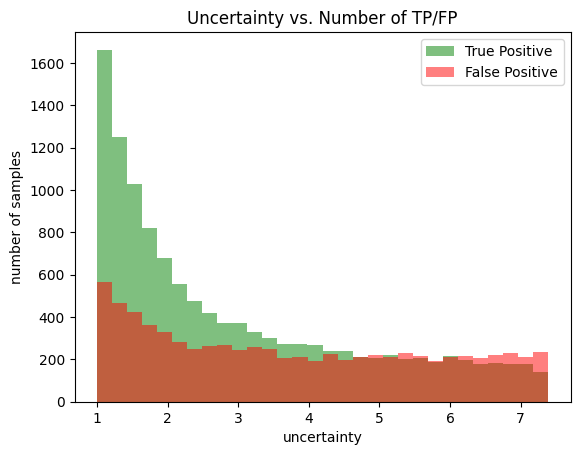

In [488]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty3_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_4

TP_uncertainty.stats: len=12054, mean=1.0572571754455566, max=4.181053161621094, min=4.709698259830475e-05, std=0.8466019034385681
FP_uncertainty.stats: len=7794, mean=1.3222736120224, max=4.163192272186279, min=0.000476837158203125, std=0.8172762989997864


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

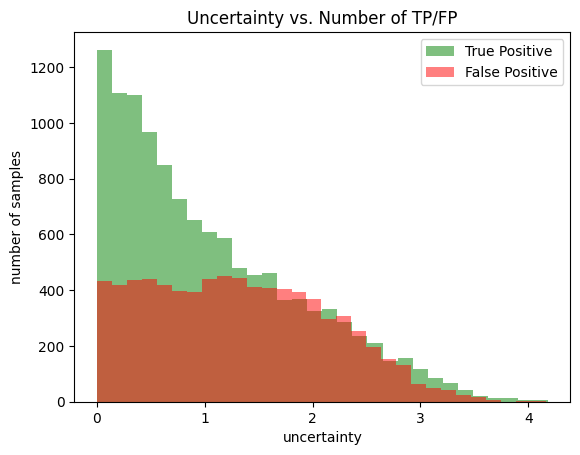

In [489]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty4_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_5

TP_uncertainty.stats: len=12054, mean=2.9524755477905273, max=7.389056205749512, min=1.0000475645065308, std=1.8031998872756958
FP_uncertainty.stats: len=7794, mean=3.761415481567383, max=7.389056205749512, min=1.0004912614822388, std=1.954252004623413


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

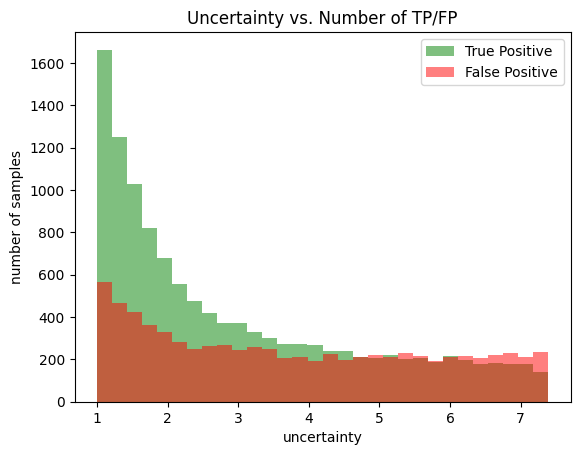

In [490]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty5_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty_6

TP_uncertainty.stats: len=12054, mean=0.9156219959259033, max=1.0056778192520142, min=0.3700196444988251, std=0.1210535392165184
FP_uncertainty.stats: len=7794, mean=0.9827115535736084, max=1.0056778192520142, min=0.42773908376693726, std=0.04872342571616173


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

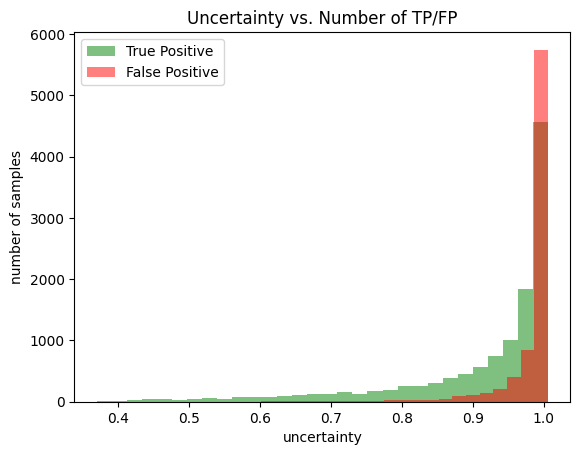

In [491]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty6_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

#### uncertainty7_list

TP_uncertainty.stats: len=12054, mean=33849512.0, max=405962457088.0, min=1.0000238418579102, std=3697480192.0
FP_uncertainty.stats: len=7794, mean=147579027456.0, max=903504017227776.0, min=1.0007355213165283, std=10467637460992.0


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

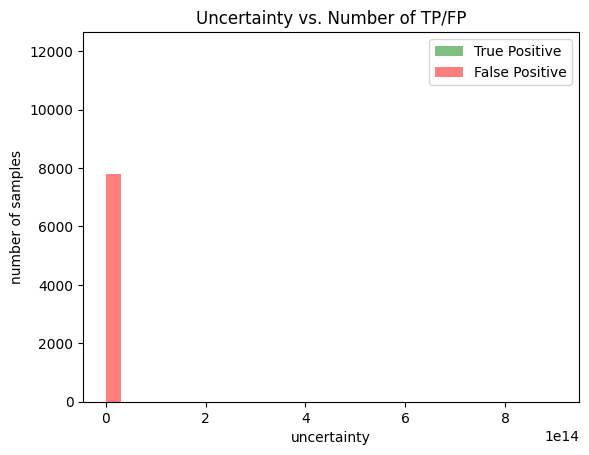

In [492]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty7_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

# Entropy Distribution Analysis

In [36]:
import numpy as np
from prettytable import PrettyTable
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt


def rank(similarity, q_pids, g_pids, max_rank=10, get_mAP=True):
    if get_mAP:
        indices = torch.argsort(similarity, dim=1, descending=True)
    else:
        # acclerate sort with topk
        _, indices = torch.topk(
            similarity, k=max_rank, dim=1, largest=True, sorted=True
        )  # q * topk
    pred_labels = g_pids[indices.cpu()]  # q * k
    matches = pred_labels.eq(q_pids.view(-1, 1))  # q * k

    all_cmc = matches[:, :max_rank].cumsum(1) # cumulative sum
    all_cmc[all_cmc > 1] = 1
    all_cmc = all_cmc.float().mean(0) * 100
    # all_cmc = all_cmc[topk - 1]

    if not get_mAP:
        return all_cmc, indices

    num_rel = matches.sum(1)  # q
    tmp_cmc = matches.cumsum(1)  # q * k

    inp = [tmp_cmc[i][match_row.nonzero()[-1]] / (match_row.nonzero()[-1] + 1.) for i, match_row in enumerate(matches)]
    mINP = torch.cat(inp).mean() * 100

    tmp_cmc = [tmp_cmc[:, i] / (i + 1.0) for i in range(tmp_cmc.shape[1])]
    tmp_cmc = torch.stack(tmp_cmc, 1) * matches
    AP = tmp_cmc.sum(1) / num_rel  # q
    mAP = AP.mean() * 100

    return all_cmc, mAP, mINP, indices

def computer_metric(similarity, qids, gids, i2t_metric=False):
    t2i_cmc, t2i_mAP, t2i_mINP, _ = rank(similarity=similarity.cpu(), q_pids=qids.cpu(), g_pids=gids.cpu(), max_rank=10, get_mAP=True)
    t2i_cmc, t2i_mAP, t2i_mINP = t2i_cmc.numpy(), t2i_mAP.numpy(), t2i_mINP.numpy()
    table = PrettyTable(["task", "R1", "R5", "R10", "mAP", "mINP"])
    table.add_row(['t2i', t2i_cmc[0], t2i_cmc[4], t2i_cmc[9], t2i_mAP, t2i_mINP])

    if i2t_metric:
        i2t_cmc, i2t_mAP, i2t_mINP, _ = rank(similarity=similarity.cpu().t(), q_pids=gids.cpu(), g_pids=qids.cpu(), max_rank=10, get_mAP=True)
        i2t_cmc, i2t_mAP, i2t_mINP = i2t_cmc.numpy(), i2t_mAP.numpy(), i2t_mINP.numpy()
        table.add_row(['i2t', i2t_cmc[0], i2t_cmc[4], i2t_cmc[9], i2t_mAP, i2t_mINP])
    # table.float_format = '.4'
    table.custom_format["R1"] = lambda f, v: f"{v:.3f}"
    table.custom_format["R5"] = lambda f, v: f"{v:.3f}"
    table.custom_format["R10"] = lambda f, v: f"{v:.3f}"
    table.custom_format["mAP"] = lambda f, v: f"{v:.3f}"
    table.custom_format["mINP"] = lambda f, v: f"{v:.3f}"
    print(str(table))

    eval_result = {
        'R1': t2i_cmc[0],
        'R5': t2i_cmc[4],
        'R10': t2i_cmc[9],
        'mAP': t2i_mAP,
        'mINP': t2i_mINP,
    }

    return eval_result

## ham_rstp_tta

In [37]:
ham_rstp_tta_embeds_dict = {}
ham_rstp_tta_embeds_dict["sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["uncertaintys_list"] = np.load('debug_embeddings/ham_rstp_tta/uncertaintys_list.npy')
ham_rstp_tta_embeds_dict["ss_idxs_list"] = np.load('debug_embeddings/ham_rstp_tta/ss_idxs_list.npy')
ham_rstp_tta_embeds_dict["sampled_sims_matrix_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_matrix_t2i.npy')
ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"] = np.load('debug_embeddings/ham_rstp_tta/sampled_sims_idx_t2i.npy')
ham_rstp_tta_embeds_dict["qids"] = np.load('debug_embeddings/ham_rstp_tta/qids.npy')
ham_rstp_tta_embeds_dict["gids"] = np.load('debug_embeddings/ham_rstp_tta/gids.npy')
ham_rstp_tta_embeds_dict["qfeats"] = np.load('debug_embeddings/ham_rstp_tta/qfeats.npy')
ham_rstp_tta_embeds_dict["gfeats"] = np.load('debug_embeddings/ham_rstp_tta/gfeats.npy')

### origin score

In [38]:
qfeats_norm = F.normalize(torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"]), p=2, dim=1)
gfeats_norm = F.normalize(torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"]), p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
sims_matrix_t2i = torch.from_numpy(ham_rstp_tta_embeds_dict["sims_matrix_t2i"])

print("eval_result_norm")
ham_rstp_tta_embeds_dict['eval_result_norm'] = computer_metric(
    sims_matrix_t2i_norm,
    torch.from_numpy(ham_rstp_tta_embeds_dict["qids"]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
)
print("eval_result")
ham_rstp_tta_embeds_dict['eval_result'] = computer_metric(
    sims_matrix_t2i,
    torch.from_numpy(ham_rstp_tta_embeds_dict["qids"]),
    torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
)

eval_result_norm
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 59.500 | 80.050 | 87.050 | 44.116 | 20.549 |
+------+--------+--------+--------+--------+--------+
eval_result
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 58.850 | 79.850 | 86.900 | 44.181 | 20.821 |
+------+--------+--------+--------+--------+--------+


### sampled_cos_sims & compute distribution_proba

In [50]:
args_temperature = 0.02
cos_sims_inter = sims_matrix_t2i_norm / args_temperature
print(cos_sims_inter.shape)

# topk_cos_sims_inter , topk_idx_cos_sims_inter = cos_sims_inter.topk(k=128, dim=-1)
sampled_sims_idx_t2i = torch.from_numpy(ham_rstp_tta_embeds_dict["sampled_sims_idx_t2i"])
print(sampled_sims_idx_t2i.shape)
# sampled_cos_sims_inter_t2i = cos_sims_inter[sampled_sims_idx_t2i]
sampled_cos_sims_inter_t2i = torch.gather(
    cos_sims_inter,
    index=sampled_sims_idx_t2i,
    dim=1,
)
print(sampled_cos_sims_inter_t2i.shape)

print(sampled_sims_idx_t2i[0])
print(sampled_cos_sims_inter_t2i[0])
print(cos_sims_inter[0,169], cos_sims_inter[0,355])

torch.Size([2000, 1000])
torch.Size([2000, 8])
torch.Size([2000, 8])
tensor([169, 355, 798, 268, 134, 167, 408, 269])
tensor([21.2301, 16.8677, 17.7234, 17.4294, 15.8705, 17.1659, 16.5780, 16.1610])
tensor(21.2301) tensor(16.8677)


In [ ]:
distribution_proba_1 = -(F.softmax(sampled_cos_sims_inter_t2i, dim=-1) * F.log_softmax(sampled_cos_sims_inter_t2i, dim=-1))#.sum(-1)

entropy_sigmoid_temper = 2
distribution_proba_2 = torch.sigmoid( ( sampled_cos_sims_inter_t2i - sampled_cos_sims_inter_t2i.mean(dim=-1).unsqueeze(-1) ) * entropy_sigmoid_temper )#.sum(-1)

entropy_sigmoid_temper = 10
distribution_proba_3 = torch.sigmoid( ( sampled_cos_sims_inter_t2i - sampled_cos_sims_inter_t2i.mean(dim=-1).unsqueeze(-1) ) * entropy_sigmoid_temper )#.sum(-1)

### show distribution_proba_1&2&3

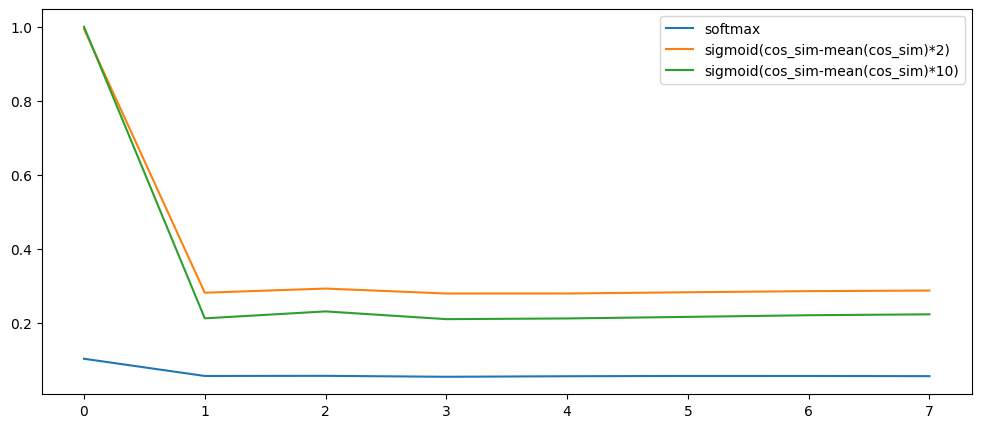

In [83]:
plt.figure(figsize=(12,5))

plt.plot(distribution_proba_1.mean(dim=0))
plt.plot(distribution_proba_2.mean(dim=0))
plt.plot(distribution_proba_3.mean(dim=0))
plt.legend(["softmax", "sigmoid(cos_sim-mean(cos_sim)*2)","sigmoid(cos_sim-mean(cos_sim)*10)"])

### Visual distribution / Uncertainty

#### Compute New Uncertainty

In [93]:

def compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_i2t, uncertainty_temper=1.0, uncertainty_t2i_temper=1.0, uncertainty_i2t_temper=1.0, k_test = 128):
    uncertaintys_list = []
    uncertainty2_list = []
    uncertainty3_list = []
    uncertainty4_list = []
    uncertainty5_list = []
    uncertainty6_list = []
    uncertainty7_list = []
    uncertainty8_list = []
    uncertainty9_list = []
    uncertainty10_list = []

    cos_uncertaintys_list = []
    cos_uncertainty2_list = []
    cos_uncertainty3_list = []
    cos_uncertainty4_list = []

    proba_top1_sim_list = []
    proba_inversed_sim_list = []

    cos_top1_sim_list = []
    cos_inversed_sim_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):

        topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
        proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象
        cos_top1_sim_t2i = topk_sim_t2i[0]

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        cos_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]
            cos_inversed_sim_i2t_top1_idx_t2i = topk_sim_i2t_top1_idx_t2i[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )
        uncertainty5 = torch.exp( torch.abs(proba_top1_sim_t2i*N_t2i - proba_inversed_sim_i2t_top1_idx_t2i*N_i2t) / ((proba_top1_sim_t2i*N_t2i + proba_inversed_sim_i2t_top1_idx_t2i*N_i2t)/2) * uncertainty_temper )
        uncertainty6 = torch.exp( (1/ (N_t2i*N_i2t) - (proba_top1_sim_t2i*proba_inversed_sim_i2t_top1_idx_t2i )) * uncertainty_temper )
        uncertainty7 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper  * 1/torch.max(proba_top1_sim_t2i, proba_inversed_sim_i2t_top1_idx_t2i))
        uncertainty8 = torch.exp( (proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i)**2 /((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) )
        uncertainty9 = torch.exp( 2* (proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i)**2 /((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) )
        uncertainty10 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i*2) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i*2)/2) * uncertainty_temper )



        cos_uncertainty = torch.exp( (1 - (cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        cos_uncertainty2 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        cos_uncertainty3 = torch.exp( torch.abs(cos_top1_sim_t2i - cos_inversed_sim_i2t_top1_idx_t2i) / ((cos_top1_sim_t2i + cos_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        cos_uncertainty4 = torch.abs( torch.log(cos_top1_sim_t2i + 1e-2) - torch.log( cos_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        uncertaintys_list.append(uncertainty)
        uncertainty2_list.append(uncertainty2)
        uncertainty3_list.append(uncertainty3)
        uncertainty4_list.append(uncertainty4)
        uncertainty5_list.append(uncertainty5)
        uncertainty6_list.append(uncertainty6)
        uncertainty7_list.append(uncertainty7)
        uncertainty8_list.append(uncertainty8)
        uncertainty9_list.append(uncertainty9)
        uncertainty10_list.append(uncertainty10)
        proba_top1_sim_list.append(proba_top1_sim_t2i)
        proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)

        cos_uncertaintys_list.append(cos_uncertainty)
        cos_uncertainty2_list.append(cos_uncertainty2)
        cos_uncertainty3_list.append(cos_uncertainty3)
        cos_uncertainty4_list.append(cos_uncertainty4)
        cos_top1_sim_list.append(cos_top1_sim_t2i)
        cos_inversed_sim_list.append(cos_inversed_sim_i2t_top1_idx_t2i)
    return uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list, uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list

In [94]:
### hyper-parameters of uncertainty
uncertainty_temper = 1
uncertainty_t2i_temper = 1
uncertainty_i2t_temper = 1
k_test = 128
N_t2i = 10
N_i2t = 5

### get query & gallery features
qfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["qfeats"])
gfeats = torch.from_numpy(ham_rstp_tta_embeds_dict["gfeats"])
qfeats_norm = F.normalize(qfeats, p=2, dim=1)
gfeats_norm = F.normalize(gfeats, p=2, dim=1)
sims_matrix_t2i_norm = qfeats_norm.cpu() @ gfeats_norm.t().cpu()
### get cos_sims_matrix
sims_matrix_t2i = torch.from_numpy(ham_rstp_tta_embeds_dict["sims_matrix_t2i"])
### get labels
gids = torch.from_numpy(ham_rstp_tta_embeds_dict["gids"])
qids = torch.from_numpy(ham_rstp_tta_embeds_dict["qids"])

### compute uncertainty
uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, uncertainty5_list, uncertainty6_list,uncertainty7_list, uncertainty8_list, uncertainty9_list, uncertainty10_list, proba_top1_sim_list, proba_inversed_sim_list, cos_uncertaintys_list, cos_uncertainty2_list, cos_uncertainty3_list, cos_uncertainty4_list, cos_top1_sim_list, cos_inversed_sim_list = compute_uncertainty_itc(N_t2i, N_i2t, sims_matrix_t2i, sims_matrix_t2i.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)
# uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, proba_top1_sim_list, proba_inversed_sim_list = compute_uncertainty_itc(qfeats, gfeats, sims_matrix_t2i_norm, sims_matrix_t2i_norm.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)

# print(f"len(uncertaintys_list) = {len(uncertaintys_list)}")
# print(f"len(uncertainty2_list) = {len(uncertainty2_list)}")
# print(f"len(uncertainty3_list) = {len(uncertainty3_list)}")
# print(f"len(uncertainty4_list) = {len(uncertainty4_list)}")

print(uncertaintys_list[:10])
print(uncertainty2_list[:10])
print(uncertainty3_list[:10])
print(uncertainty4_list[:10])
print(uncertainty5_list[:10])
print(uncertainty6_list[:10])

print()
print(proba_top1_sim_list[:10])
print(proba_inversed_sim_list[:10])


print()
# print(f"len(cos_uncertaintys_list) = {len(cos_uncertaintys_list)}")
# print(f"len(cos_uncertainty2_list) = {len(cos_uncertainty2_list)}")
# print(f"len(cos_uncertainty3_list) = {len(cos_uncertainty3_list)}")
# print(f"len(cos_uncertainty4_list) = {len(cos_uncertainty4_list)}")

print(cos_uncertaintys_list[:10])
print(cos_uncertainty2_list[:10])
print(cos_uncertainty3_list[:10])
print(cos_uncertainty4_list[:10])

print()
print(cos_top1_sim_list[:10])
print(cos_inversed_sim_list[:10])
print(np.sum([cos1==cos2 for cos1,cos2 in zip(cos_top1_sim_list, cos_inversed_sim_list)]))

[tensor(2.2715), tensor(2.4820), tensor(2.3835), tensor(2.3287), tensor(2.5199), tensor(1.7942), tensor(1.8345), tensor(1.0274), tensor(2.0327), tensor(2.3388)]
[tensor(1.4279), tensor(1.1991), tensor(1.2983), tensor(1.3523), tensor(1.1606), tensor(1.4222), tensor(2.0995), tensor(1.0079), tensor(1.4092), tensor(1.3035)]
[tensor(7.2706), tensor(7.3626), tensor(7.2895), tensor(7.0347), tensor(7.1348), tensor(2.3344), tensor(6.5950), tensor(1.0082), tensor(3.2557), tensor(5.8260)]
[tensor(3.4691), tensor(2.9373), tensor(3.2177), tensor(3.1297), tensor(2.6494), tensor(0.8807), tensor(3.1750), tensor(0.0080), tensor(1.2967), tensor(2.3522)]
[tensor(7.3295), tensor(7.3758), tensor(7.3390), tensor(7.2086), tensor(7.2603), tensor(1.2348), tensor(6.9751), tensor(1.9618), tensor(4.6806), tensor(6.5373)]
[tensor(1.0197), tensor(1.0202), tensor(1.0200), tensor(1.0190), tensor(1.0200), tensor(0.8855), tensor(1.0029), tensor(0.3959), tensor(0.9656), tensor(1.0151)]

[tensor(0.3577), tensor(0.1817), 

In [95]:
torch.from_numpy(np.array(uncertaintys_list)).shape

torch.Size([2000])

#### show distribution / Uncertainty_1

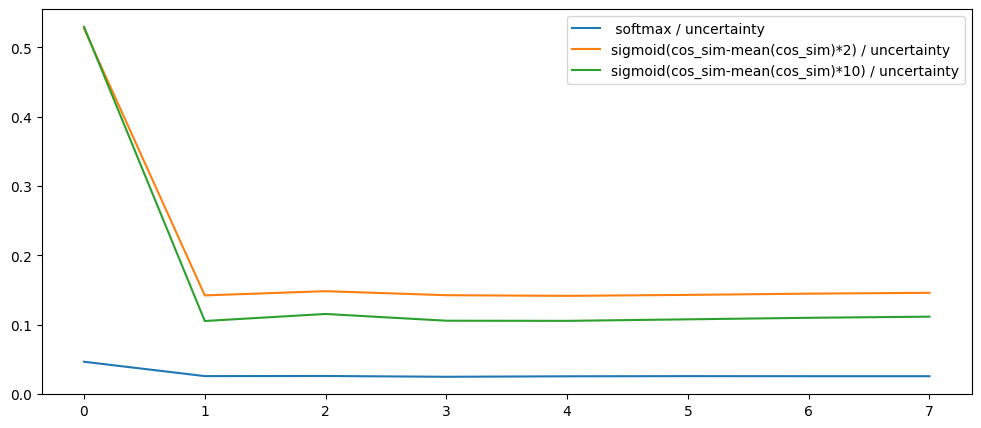

In [96]:
unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertaintys_list)).unsqueeze(-1)


unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertaintys_list)).unsqueeze(-1)


unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertaintys_list)).unsqueeze(-1)


plt.figure(figsize=(12,5))

plt.plot(unc_distribution_proba_1.mean(dim=0))
plt.plot(unc_distribution_proba_2.mean(dim=0))
plt.plot(unc_distribution_proba_3.mean(dim=0))
plt.legend([" softmax / uncertainty", "sigmoid(cos_sim-mean(cos_sim)*2) / uncertainty","sigmoid(cos_sim-mean(cos_sim)*10) / uncertainty"])

#### show distribution / Uncertainty_3 

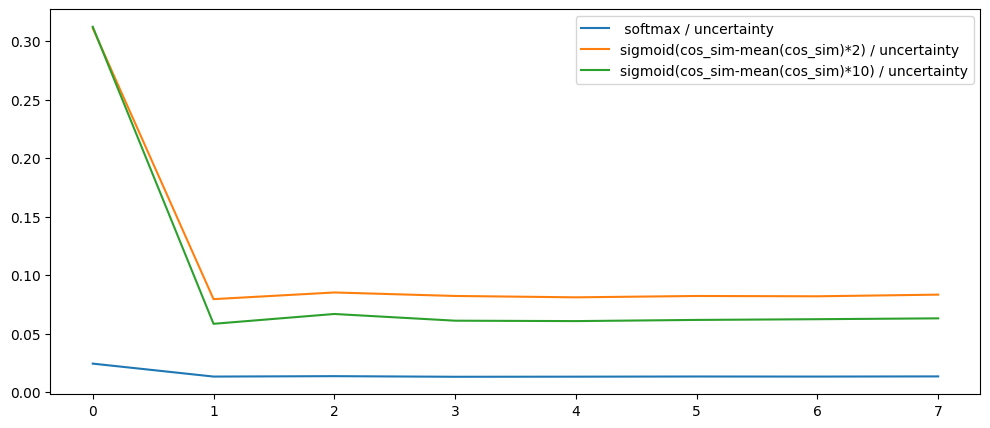

In [97]:
unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty3_list)).unsqueeze(-1)


unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty3_list)).unsqueeze(-1)


unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty3_list)).unsqueeze(-1)


plt.figure(figsize=(12,5))

plt.plot(unc_distribution_proba_1.mean(dim=0))
plt.plot(unc_distribution_proba_2.mean(dim=0))
plt.plot(unc_distribution_proba_3.mean(dim=0))
plt.legend([" softmax / uncertainty", "sigmoid(cos_sim-mean(cos_sim)*2) / uncertainty","sigmoid(cos_sim-mean(cos_sim)*10) / uncertainty"])

#### show distribution / Uncertainty_4

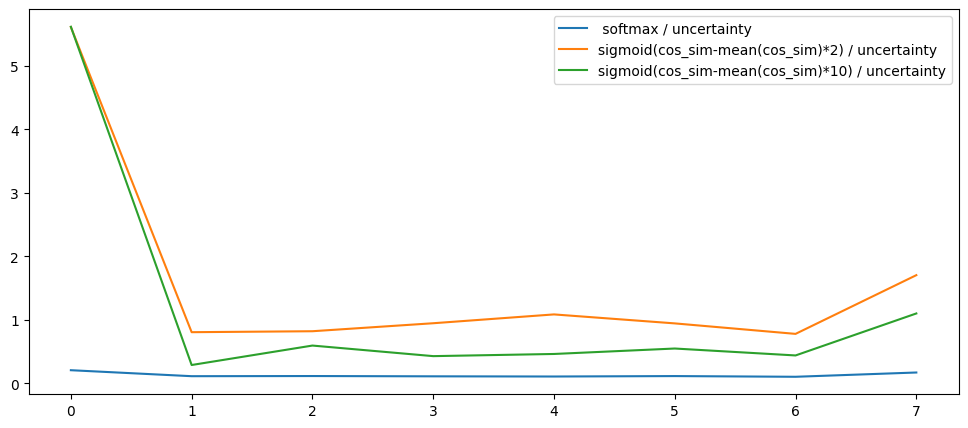

In [98]:
unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty4_list)).unsqueeze(-1)


unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty4_list)).unsqueeze(-1)


unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty4_list)).unsqueeze(-1)


plt.figure(figsize=(12,5))

plt.plot(unc_distribution_proba_1.mean(dim=0))
plt.plot(unc_distribution_proba_2.mean(dim=0))
plt.plot(unc_distribution_proba_3.mean(dim=0))
plt.legend([" softmax / uncertainty", "sigmoid(cos_sim-mean(cos_sim)*2) / uncertainty","sigmoid(cos_sim-mean(cos_sim)*10) / uncertainty"])

#### show distribution / Uncertainty_5

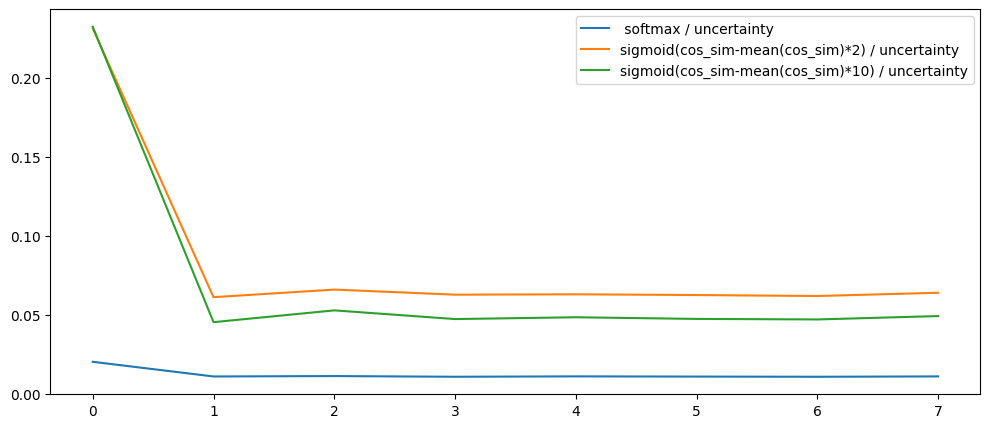

In [99]:
unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty5_list)).unsqueeze(-1)


unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty5_list)).unsqueeze(-1)


unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty5_list)).unsqueeze(-1)


plt.figure(figsize=(12,5))

plt.plot(unc_distribution_proba_1.mean(dim=0))
plt.plot(unc_distribution_proba_2.mean(dim=0))
plt.plot(unc_distribution_proba_3.mean(dim=0))
plt.legend([" softmax / uncertainty", "sigmoid(cos_sim-mean(cos_sim)*2) / uncertainty","sigmoid(cos_sim-mean(cos_sim)*10) / uncertainty"])

#### show distribution / Uncertainty_10

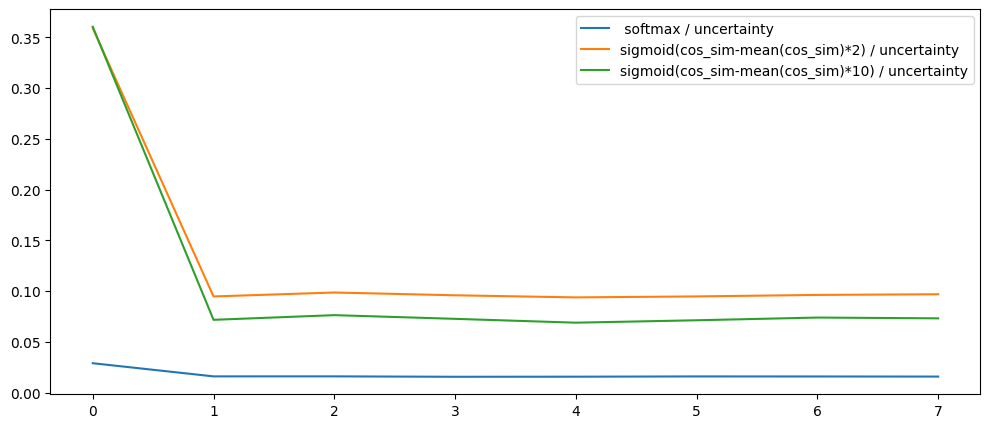

In [100]:
unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)


unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)


unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)


plt.figure(figsize=(12,5))

plt.plot(unc_distribution_proba_1.mean(dim=0))
plt.plot(unc_distribution_proba_2.mean(dim=0))
plt.plot(unc_distribution_proba_3.mean(dim=0))
plt.legend([" softmax / uncertainty", "sigmoid(cos_sim-mean(cos_sim)*2) / uncertainty","sigmoid(cos_sim-mean(cos_sim)*10) / uncertainty"])

### Visual unc_distribution_proba vs. TP/FP

In [101]:
print(np.mean(uncertaintys_list),np.mean(uncertainty3_list),np.mean(uncertainty4_list),np.mean(uncertainty5_list),np.mean(uncertainty10_list))

1.9628599 4.7633705 2.080043 5.451251 4.2193465


#### show distribution / Uncertainty_1 vs. TP/FP

TP_unc_distribution1.stats: len=1177
FP_unc_distribution1.stats: len=823
TP_unc_distribution2.stats: len=1177
FP_unc_distribution2.stats: len=823
TP_unc_distribution3.stats: len=1177
FP_unc_distribution3.stats: len=823


Text(0, 0.5, 'unc_distribution_proba3')

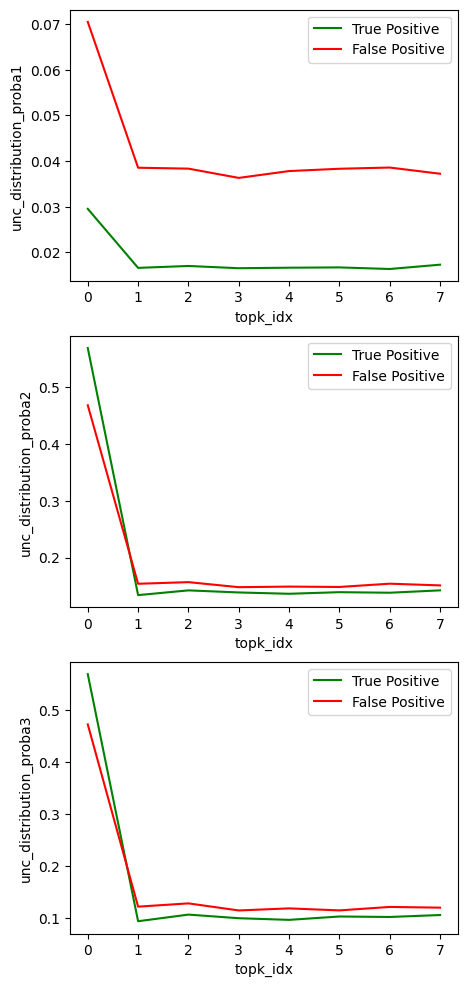

In [102]:
unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertaintys_list)).unsqueeze(-1)
unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertaintys_list)).unsqueeze(-1)
unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertaintys_list)).unsqueeze(-1)


### plot Loss1 vs. TP/FP
TP_unc_distribution1 = []
FP_unc_distribution1 = []
TP_unc_distribution2 = []
FP_unc_distribution2 = []
TP_unc_distribution3 = []
FP_unc_distribution3 = []
for sample_idx, (sims_t2i, unc_distribution1,unc_distribution2,unc_distribution3) in enumerate(zip(sims_matrix_t2i, unc_distribution_proba_1, unc_distribution_proba_2,unc_distribution_proba_3)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc_distribution1.append(unc_distribution1)
        TP_unc_distribution2.append(unc_distribution2)
        TP_unc_distribution3.append(unc_distribution3)
    else:
        FP_unc_distribution1.append(unc_distribution1)
        FP_unc_distribution2.append(unc_distribution2)
        FP_unc_distribution3.append(unc_distribution3)


print(f"TP_unc_distribution1.stats: len={len(TP_unc_distribution1)}")
print(f"FP_unc_distribution1.stats: len={len(FP_unc_distribution1)}")
print(f"TP_unc_distribution2.stats: len={len(TP_unc_distribution2)}")
print(f"FP_unc_distribution2.stats: len={len(FP_unc_distribution2)}")
print(f"TP_unc_distribution3.stats: len={len(TP_unc_distribution3)}")
print(f"FP_unc_distribution3.stats: len={len(FP_unc_distribution3)}")

plt.figure(figsize=(5,12))
plt.subplot(3,1,1)
hist_info_TP = plt.plot(np.array(TP_unc_distribution1).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution1).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba1')
# plt.title('unc_distribution_proba1 vs. topk_idx')

plt.subplot(3,1,2)
hist_info_TP = plt.plot(np.array(TP_unc_distribution2).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution2).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba2')
# plt.title('unc_distribution_proba2 vs. topk_idx')

plt.subplot(3,1,3)
hist_info_TP = plt.plot(np.array(TP_unc_distribution3).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution3).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba3')
# plt.title('unc_distribution_proba3 vs. topk_idx')

#### show distribution / Uncertainty_3 vs. TP/FP

TP_unc_distribution1.stats: len=1177
FP_unc_distribution1.stats: len=823
TP_unc_distribution2.stats: len=1177
FP_unc_distribution2.stats: len=823
TP_unc_distribution3.stats: len=1177
FP_unc_distribution3.stats: len=823


Text(0, 0.5, 'unc_distribution_proba3')

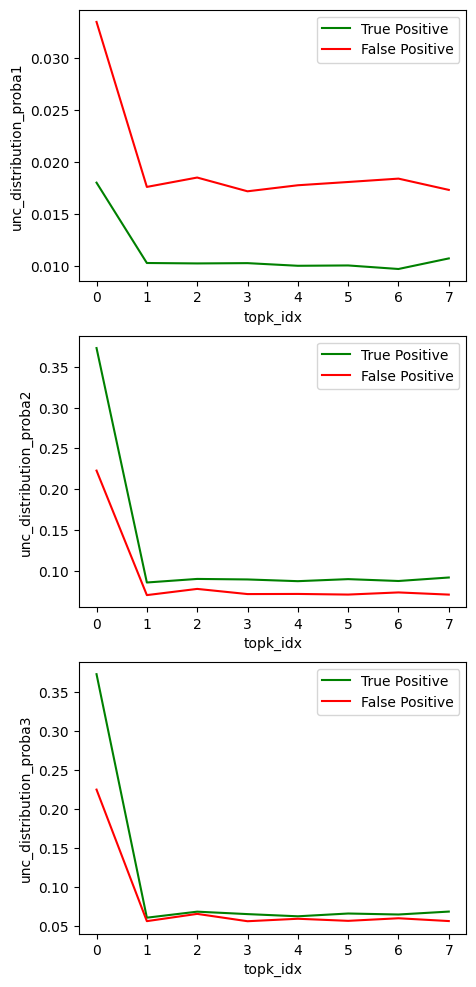

In [103]:
#### show distribution / Uncertainty_3 vs. TP/FP

unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty3_list)).unsqueeze(-1)
unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty3_list)).unsqueeze(-1)
unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty3_list)).unsqueeze(-1)


### plot Loss1 vs. TP/FP
TP_unc_distribution1 = []
FP_unc_distribution1 = []
TP_unc_distribution2 = []
FP_unc_distribution2 = []
TP_unc_distribution3 = []
FP_unc_distribution3 = []
for sample_idx, (sims_t2i, unc_distribution1,unc_distribution2,unc_distribution3) in enumerate(zip(sims_matrix_t2i, unc_distribution_proba_1, unc_distribution_proba_2,unc_distribution_proba_3)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc_distribution1.append(unc_distribution1)
        TP_unc_distribution2.append(unc_distribution2)
        TP_unc_distribution3.append(unc_distribution3)
    else:
        FP_unc_distribution1.append(unc_distribution1)
        FP_unc_distribution2.append(unc_distribution2)
        FP_unc_distribution3.append(unc_distribution3)


print(f"TP_unc_distribution1.stats: len={len(TP_unc_distribution1)}")
print(f"FP_unc_distribution1.stats: len={len(FP_unc_distribution1)}")
print(f"TP_unc_distribution2.stats: len={len(TP_unc_distribution2)}")
print(f"FP_unc_distribution2.stats: len={len(FP_unc_distribution2)}")
print(f"TP_unc_distribution3.stats: len={len(TP_unc_distribution3)}")
print(f"FP_unc_distribution3.stats: len={len(FP_unc_distribution3)}")

plt.figure(figsize=(5,12))
plt.subplot(3,1,1)
hist_info_TP = plt.plot(np.array(TP_unc_distribution1).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution1).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba1')
# plt.title('unc_distribution_proba1 vs. topk_idx')

plt.subplot(3,1,2)
hist_info_TP = plt.plot(np.array(TP_unc_distribution2).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution2).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba2')
# plt.title('unc_distribution_proba2 vs. topk_idx')

plt.subplot(3,1,3)
hist_info_TP = plt.plot(np.array(TP_unc_distribution3).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution3).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba3')
# plt.title('unc_distribution_proba3 vs. topk_idx')

#### show distribution / Uncertainty_4 vs. TP/FP

TP_unc_distribution1.stats: len=1177
FP_unc_distribution1.stats: len=823
TP_unc_distribution2.stats: len=1177
FP_unc_distribution2.stats: len=823
TP_unc_distribution3.stats: len=1177
FP_unc_distribution3.stats: len=823


Text(0, 0.5, 'unc_distribution_proba3')

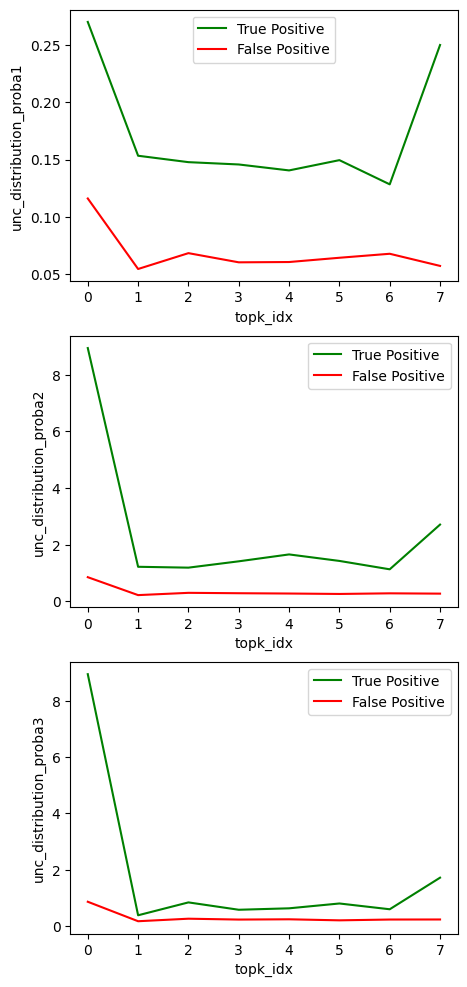

In [104]:
#### show distribution / Uncertainty_4 vs. TP/FP

unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty4_list)).unsqueeze(-1)
unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty4_list)).unsqueeze(-1)
unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty4_list)).unsqueeze(-1)


### plot Loss1 vs. TP/FP
TP_unc_distribution1 = []
FP_unc_distribution1 = []
TP_unc_distribution2 = []
FP_unc_distribution2 = []
TP_unc_distribution3 = []
FP_unc_distribution3 = []
for sample_idx, (sims_t2i, unc_distribution1,unc_distribution2,unc_distribution3) in enumerate(zip(sims_matrix_t2i, unc_distribution_proba_1, unc_distribution_proba_2,unc_distribution_proba_3)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc_distribution1.append(unc_distribution1)
        TP_unc_distribution2.append(unc_distribution2)
        TP_unc_distribution3.append(unc_distribution3)
    else:
        FP_unc_distribution1.append(unc_distribution1)
        FP_unc_distribution2.append(unc_distribution2)
        FP_unc_distribution3.append(unc_distribution3)


print(f"TP_unc_distribution1.stats: len={len(TP_unc_distribution1)}")
print(f"FP_unc_distribution1.stats: len={len(FP_unc_distribution1)}")
print(f"TP_unc_distribution2.stats: len={len(TP_unc_distribution2)}")
print(f"FP_unc_distribution2.stats: len={len(FP_unc_distribution2)}")
print(f"TP_unc_distribution3.stats: len={len(TP_unc_distribution3)}")
print(f"FP_unc_distribution3.stats: len={len(FP_unc_distribution3)}")

plt.figure(figsize=(5,12))
plt.subplot(3,1,1)
hist_info_TP = plt.plot(np.array(TP_unc_distribution1).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution1).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba1')
# plt.title('unc_distribution_proba1 vs. topk_idx')

plt.subplot(3,1,2)
hist_info_TP = plt.plot(np.array(TP_unc_distribution2).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution2).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba2')
# plt.title('unc_distribution_proba2 vs. topk_idx')

plt.subplot(3,1,3)
hist_info_TP = plt.plot(np.array(TP_unc_distribution3).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution3).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba3')
# plt.title('unc_distribution_proba3 vs. topk_idx')

#### show distribution / Uncertainty_5 vs. TP/FP

TP_unc_distribution1.stats: len=1177
FP_unc_distribution1.stats: len=823
TP_unc_distribution2.stats: len=1177
FP_unc_distribution2.stats: len=823
TP_unc_distribution3.stats: len=1177
FP_unc_distribution3.stats: len=823


Text(0, 0.5, 'unc_distribution_proba3')

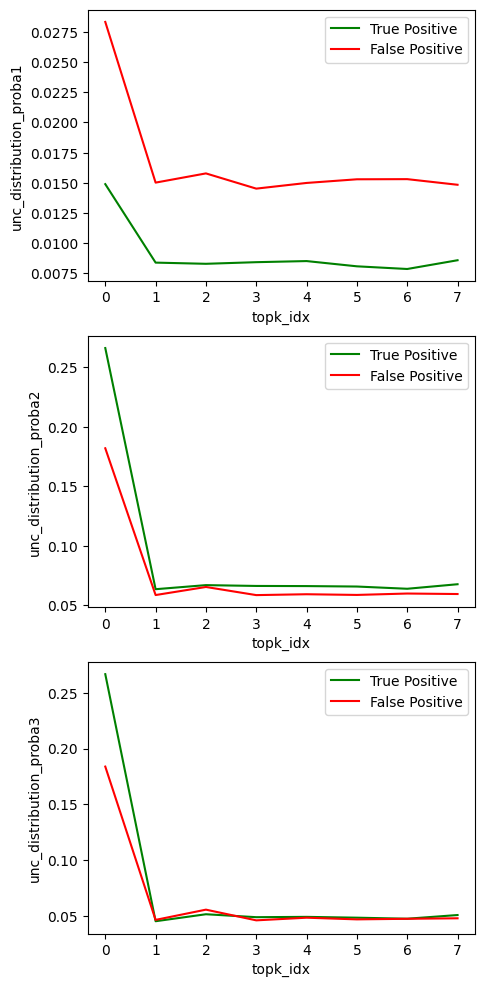

In [105]:
#### show distribution / Uncertainty_5 vs. TP/FP

unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty5_list)).unsqueeze(-1)
unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty5_list)).unsqueeze(-1)
unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty5_list)).unsqueeze(-1)


### plot Loss1 vs. TP/FP
TP_unc_distribution1 = []
FP_unc_distribution1 = []
TP_unc_distribution2 = []
FP_unc_distribution2 = []
TP_unc_distribution3 = []
FP_unc_distribution3 = []
for sample_idx, (sims_t2i, unc_distribution1,unc_distribution2,unc_distribution3) in enumerate(zip(sims_matrix_t2i, unc_distribution_proba_1, unc_distribution_proba_2,unc_distribution_proba_3)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc_distribution1.append(unc_distribution1)
        TP_unc_distribution2.append(unc_distribution2)
        TP_unc_distribution3.append(unc_distribution3)
    else:
        FP_unc_distribution1.append(unc_distribution1)
        FP_unc_distribution2.append(unc_distribution2)
        FP_unc_distribution3.append(unc_distribution3)


print(f"TP_unc_distribution1.stats: len={len(TP_unc_distribution1)}")
print(f"FP_unc_distribution1.stats: len={len(FP_unc_distribution1)}")
print(f"TP_unc_distribution2.stats: len={len(TP_unc_distribution2)}")
print(f"FP_unc_distribution2.stats: len={len(FP_unc_distribution2)}")
print(f"TP_unc_distribution3.stats: len={len(TP_unc_distribution3)}")
print(f"FP_unc_distribution3.stats: len={len(FP_unc_distribution3)}")

plt.figure(figsize=(5,12))
plt.subplot(3,1,1)
hist_info_TP = plt.plot(np.array(TP_unc_distribution1).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution1).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba1')
# plt.title('unc_distribution_proba1 vs. topk_idx')

plt.subplot(3,1,2)
hist_info_TP = plt.plot(np.array(TP_unc_distribution2).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution2).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba2')
# plt.title('unc_distribution_proba2 vs. topk_idx')

plt.subplot(3,1,3)
hist_info_TP = plt.plot(np.array(TP_unc_distribution3).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution3).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba3')
# plt.title('unc_distribution_proba3 vs. topk_idx')

#### show distribution / Uncertainty_10 vs. TP/FP

TP_unc_distribution1.stats: len=1177
FP_unc_distribution1.stats: len=823
TP_unc_distribution2.stats: len=1177
FP_unc_distribution2.stats: len=823
TP_unc_distribution3.stats: len=1177
FP_unc_distribution3.stats: len=823


Text(0, 0.5, 'unc_distribution_proba3')

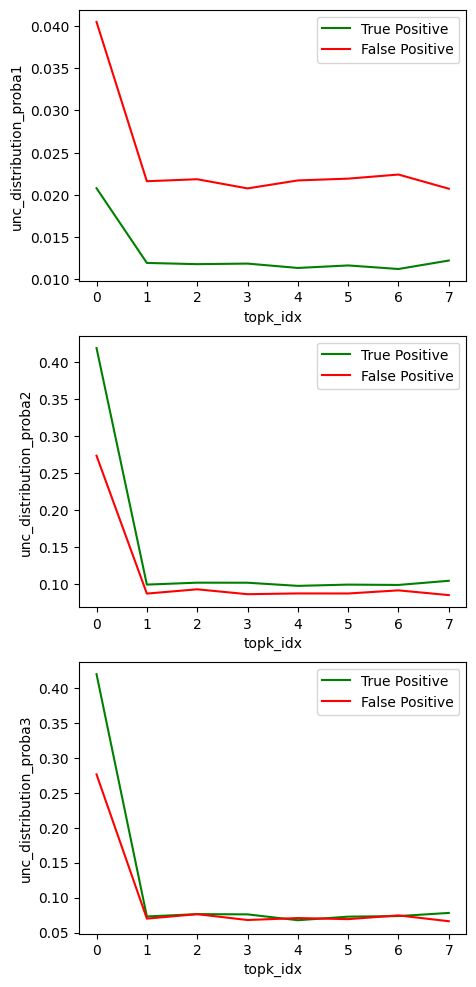

In [106]:
#### show distribution / Uncertainty_10 vs. TP/FP

unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)
unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)
unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)


### plot Loss1 vs. TP/FP
TP_unc_distribution1 = []
FP_unc_distribution1 = []
TP_unc_distribution2 = []
FP_unc_distribution2 = []
TP_unc_distribution3 = []
FP_unc_distribution3 = []
for sample_idx, (sims_t2i, unc_distribution1,unc_distribution2,unc_distribution3) in enumerate(zip(sims_matrix_t2i, unc_distribution_proba_1, unc_distribution_proba_2,unc_distribution_proba_3)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc_distribution1.append(unc_distribution1)
        TP_unc_distribution2.append(unc_distribution2)
        TP_unc_distribution3.append(unc_distribution3)
    else:
        FP_unc_distribution1.append(unc_distribution1)
        FP_unc_distribution2.append(unc_distribution2)
        FP_unc_distribution3.append(unc_distribution3)


print(f"TP_unc_distribution1.stats: len={len(TP_unc_distribution1)}")
print(f"FP_unc_distribution1.stats: len={len(FP_unc_distribution1)}")
print(f"TP_unc_distribution2.stats: len={len(TP_unc_distribution2)}")
print(f"FP_unc_distribution2.stats: len={len(FP_unc_distribution2)}")
print(f"TP_unc_distribution3.stats: len={len(TP_unc_distribution3)}")
print(f"FP_unc_distribution3.stats: len={len(FP_unc_distribution3)}")

plt.figure(figsize=(5,12))
plt.subplot(3,1,1)
hist_info_TP = plt.plot(np.array(TP_unc_distribution1).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution1).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba1')
# plt.title('unc_distribution_proba1 vs. topk_idx')

plt.subplot(3,1,2)
hist_info_TP = plt.plot(np.array(TP_unc_distribution2).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution2).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba2')
# plt.title('unc_distribution_proba2 vs. topk_idx')

plt.subplot(3,1,3)
hist_info_TP = plt.plot(np.array(TP_unc_distribution3).mean(axis=0), color='green')
hist_info_FP = plt.plot(np.array(FP_unc_distribution3).mean(axis=0), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('unc_distribution_proba3')
# plt.title('unc_distribution_proba3 vs. topk_idx')

### Visual loss vs. TP/FP

#### show Loss(distribution/Uncertainty_10) vs. TP/FP

TP_unc_distribution1.stats: len=1177
FP_unc_distribution1.stats: len=823
TP_unc_distribution2.stats: len=1177
FP_unc_distribution2.stats: len=823
TP_unc_distribution3.stats: len=1177
FP_unc_distribution3.stats: len=823


Text(0, 0.5, 'Loss(distribution3/Uncertainty_10)')

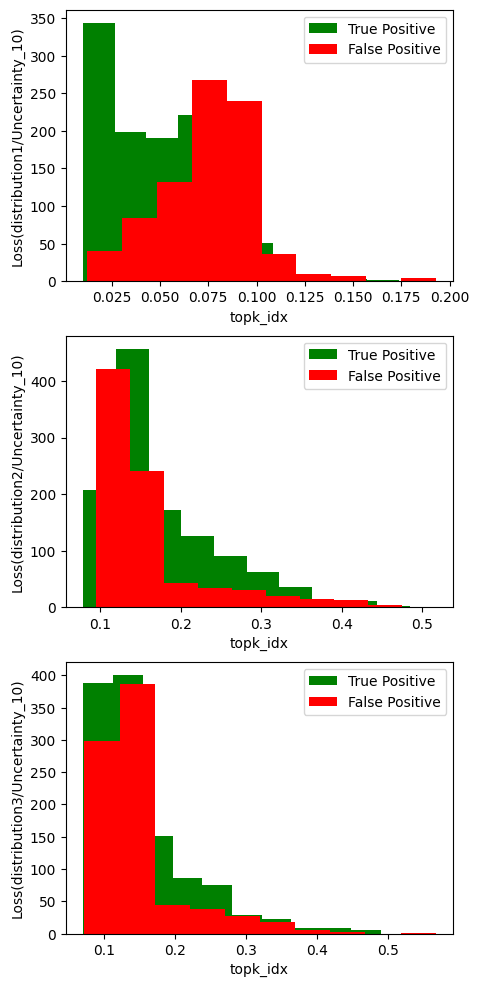

In [107]:
#### show distribution / Uncertainty_10 vs. TP/FP

loss_unc_distribution_proba_1 = distribution_proba_1 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1) + 0.01*torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)
loss_unc_distribution_proba_2 = distribution_proba_2 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1) + 0.01*torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)
loss_unc_distribution_proba_3 = distribution_proba_3 / torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1) + 0.01*torch.from_numpy(np.array(uncertainty10_list)).unsqueeze(-1)


### plot Loss1 vs. TP/FP
TP_unc_distribution1 = []
FP_unc_distribution1 = []
TP_unc_distribution2 = []
FP_unc_distribution2 = []
TP_unc_distribution3 = []
FP_unc_distribution3 = []
for sample_idx, (sims_t2i, unc_distribution1,unc_distribution2,unc_distribution3) in enumerate(zip(sims_matrix_t2i, loss_unc_distribution_proba_1, loss_unc_distribution_proba_2,loss_unc_distribution_proba_3)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc_distribution1.append(unc_distribution1)
        TP_unc_distribution2.append(unc_distribution2)
        TP_unc_distribution3.append(unc_distribution3)
    else:
        FP_unc_distribution1.append(unc_distribution1)
        FP_unc_distribution2.append(unc_distribution2)
        FP_unc_distribution3.append(unc_distribution3)


print(f"TP_unc_distribution1.stats: len={len(TP_unc_distribution1)}")
print(f"FP_unc_distribution1.stats: len={len(FP_unc_distribution1)}")
print(f"TP_unc_distribution2.stats: len={len(TP_unc_distribution2)}")
print(f"FP_unc_distribution2.stats: len={len(FP_unc_distribution2)}")
print(f"TP_unc_distribution3.stats: len={len(TP_unc_distribution3)}")
print(f"FP_unc_distribution3.stats: len={len(FP_unc_distribution3)}")

plt.figure(figsize=(5,12))
plt.subplot(3,1,1)
hist_info_TP = plt.hist(np.array(TP_unc_distribution1).mean(axis=-1), color='green')
hist_info_FP = plt.hist(np.array(FP_unc_distribution1).mean(axis=-1), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('Loss(distribution1/Uncertainty_10)')
# plt.title('unc_distribution_proba1 vs. topk_idx')

plt.subplot(3,1,2)
hist_info_TP = plt.hist(np.array(TP_unc_distribution2).mean(axis=-1), color='green')
hist_info_FP = plt.hist(np.array(FP_unc_distribution2).mean(axis=-1), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('Loss(distribution2/Uncertainty_10)')
# plt.title('unc_distribution_proba2 vs. topk_idx')

plt.subplot(3,1,3)
hist_info_TP = plt.hist(np.array(TP_unc_distribution3).mean(axis=-1), color='green')
hist_info_FP = plt.hist(np.array(FP_unc_distribution3).mean(axis=-1), color='red')
# plt.ylim(0,250)
# plt.grid(True)
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('topk_idx')
plt.ylabel('Loss(distribution3/Uncertainty_10)')
# plt.title('unc_distribution_proba3 vs. topk_idx')

# Figure 1

[0.99923139 0.9866694  0.97868021 0.97656833 0.97065513 0.96949542
 0.96414159 0.96270077 0.9625408  0.9491407  0.93613467 0.92095161
 0.91852875 0.91615074 0.90692037 0.90203589 0.88739601 0.87424884
 0.8684432  0.83951546 0.83463503 0.81898409 0.81750976 0.81492287
 0.81168739 0.80469752 0.80405081 0.80096748 0.78331082 0.76958488
 0.7608755  0.75933122 0.75521243 0.732821   0.73013338 0.71285226
 0.71053999 0.69929176 0.69871338 0.69281661 0.68605775 0.67627702
 0.6754142  0.67125342 0.66368361 0.65824913 0.64912279 0.64710562
 0.63788109 0.63088243 0.62747303 0.62585914 0.62510292 0.61781945
 0.61485208 0.60311795 0.60247562 0.58437731 0.57069289 0.55772562
 0.55018268 0.52982574 0.52721877 0.52650946 0.5234323  0.49403527
 0.49203564 0.46732651 0.46120807 0.44642328 0.43855486 0.40906179
 0.40728949 0.3987734  0.39316176 0.39088413 0.37358902 0.37109471
 0.36211228 0.36175442 0.36143435 0.35449394 0.33740225 0.32841895
 0.32661945 0.3190632  0.3097875  0.30730816 0.29985825 0.2979

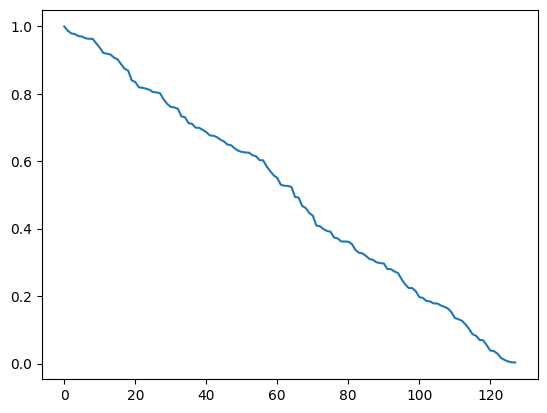

In [12]:
import numpy as np
from prettytable import PrettyTable
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt


nn = np.sort(np.random.rand(128))[::-1]
print(nn)
plt.plot(nn)


In [13]:
nn = [0.99923139 0.9966694  0.99868021 0.98656833 0.98065513 0.98949542
 0.98414159 0.97270077 0.9625408  0.9691407  0.96613467 0.96095161
 0.9652875 0.91615074 0.90692037 0.90203589 0.88739601 0.87424884
 0.8684432  0.83951546 0.83463503 0.81898409 0.81750976 0.81492287
 0.81168739 0.80469752 0.80405081 0.80096748 0.78331082 0.76958488
 0.7608755  0.75933122 0.75521243 0.732821   0.73013338 0.71285226
 0.71053999 0.69929176 0.69871338 0.69281661 0.68605775 0.67627702
 0.6754142  0.67125342 0.66368361 0.65824913 0.64912279 0.64710562
 0.63788109 0.63088243 0.62747303 0.62585914 0.62510292 0.61781945
 0.61485208 0.60311795 0.60247562 0.58437731 0.57069289 0.55772562
 0.55018268 0.52982574 0.52721877 0.52650946 0.5234323  0.49403527
 0.49203564 0.46732651 0.46120807 0.44642328 0.43855486 0.40906179
 0.40728949 0.3987734  0.39316176 0.39088413 0.37358902 0.37109471
 0.36211228 0.36175442 0.36143435 0.35449394 0.33740225 0.32841895
 0.32661945 0.3190632  0.3097875  0.30730816 0.29985825 0.2979999
 0.29683688 0.28026069 0.27994849 0.27300255 0.26859246 0.25034508
 0.23495508 0.22424926 0.22386666 0.21438353 0.19721443 0.19473289
 0.18557988 0.1842942  0.1785181  0.17827577 0.17275663 0.16860722
 0.16370999 0.15296268 0.13545988 0.13163377 0.12715944 0.11621396
 0.10320158 0.08712138 0.08237516 0.06988865 0.069385   0.05420946
 0.03878662 0.03696485 0.02949405 0.01700287 0.01086984 0.00650106
 0.0038454  0.00335106]

plt.plot(nn)


SyntaxError: invalid syntax (4181379401.py, line 1)

# End